# 4. black–scholes, implied volatility, greeks and hedging

This is one of the most important projects in this series and the pillar for lots of future projects. In this notebook we will get into some of the most important topics including:

- **stochastic processes** 
- **risk-neutral pricing**
- **the Black–Scholes–Merton model**
- **Pricing SPX options**
- **implied volatility with two different solvers**
- **Greeks with analytic and autodiff approaches**
- **market-quality diagnostics (Dispersion, No-arb)**
- **hedging Greeks with SPY**



### imports and plotting style

In [1]:
import warnings
import time
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from numba import njit, prange
from scipy.stats import norm
import jax
import jax.numpy as jnp
from jax import grad, vmap
from IPython.display import display

import quantfinlab.fixed_income as fi

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
palette = ["#069af3", "#fe420f", "#00008b", "#008080", "#800080",
            "#7bc8f6", "#0072b2", "#04d8b2",
            "#cc79a7", "#ff8072", "#9614fa", "#dc143c"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7,
})
seed = 7
np.random.seed(seed)



## 1. Introduction to Options

An **option** is a financial derivative whose value depends on an underlying asset such as a stock, index, or ETF. The key feature of an option is that it gives the holder a **right, but not an obligation**, to buy or sell the underlying asset at a predetermined price.

### 1.1) Call Options: The Right to Buy

A call option gives the buyer the right to **buy** the underlying asset at a specified price called the **strike price** ($K$) at or before a specified date called the **maturity** or **expiration date** ($T$).

**How it works in practice:**

Suppose a stock is currently trading at 100. You believe that in 3 months, the price will rise above 120. You have two choices:

**Choice 1: Buy the stock directly**
- You pay $100 now
- If the stock rises to$140 in 3 months, you profit 40
- If the stock falls to 80 in 3 months, you lose 20
- Your potential loss is substantial (could lose most of your investment if stock crashes)

**Choice 2: Buy a call option**
- You pay a **premium** (option price) of, say, $5 to the seller
- You choose a strike price $K = 120$ and maturity $T = 3$ months
- The seller agrees to give you the right to buy the stock at $120 in 3 months
- Both the option premium (5) and strike price (120) are determined and agreed upon when you buy the option

**At maturity (3 months later), you have a choice:**

- **If stock price is 140** (above strike $K = 120$):
  - You exercise your right and buy at 120
  - You immediately have an asset worth 140
  - Your profit = 140 - 120 - 5 (premium) = 15
  
- **If stock price is 95** (below strike $K = 120$):
  - You don't exercise (why buy at 120 when market price is 95?)
  - You lose only the premium: 5
  - This is your maximum possible loss, regardless of how low the stock goes

- **If stock price is 65** (far below strike):
  - You still don't exercise
  - You still lose only the premium: 5
  - Whether the stock is at 95, 65, or even 10, your loss is capped at 5

This is the power of options for hedging: Your downside risk is limited to the premium you paid, while your upside potential is unlimited (stock could go to $200, $300, etc.).

**Mathematical representation of call option payoff:**

At maturity $T$, if the stock price is $S_T$, your payoff is:

$$\text{Call Payoff} = \max(S_T - K, 0)$$

This means:
- If $S_T > K$: You exercise and get $S_T - K$
- If $S_T \leq K$: You don't exercise and get $0$

Your **net profit** is:

$$\text{Call Profit} = \max(S_T - K, 0) - C_0$$

where $C_0$ is the premium you paid initially (the $5 in our example).

### 1.2 The Other Side: Selling Call Options

When you **sell (write) a call option**, you are on the opposite side of the transaction:

- You receive the premium ($5) upfront
- You are obligated to sell the stock at strike price $K$ if the buyer exercises

**Payoff structure for the seller:**

- **If stock price is 95** (below strike $K = 120$):
  - Buyer doesn't exercise
  - You keep the premium: profit = 5
  - This is your maximum profit

- **If stock price is 140** (above strike $K = 120$):
  - Buyer exercises
  - You must sell stock at 120 (even though it's worth 140)
  - Your loss = 140 - 120 = 20
  - Net loss = 20 - 5 (premium) = 15

- **If stock price is 160**:
  - Your loss = 160 - 120 = 40
  - Net loss = 40 - 5 = 35

- **If stock price is 200**:
  - Your loss = 200 - 120 = 80
  - Net loss = 80 - 5 = 75

**Key insight**: As a call option seller, your profit is capped at the premium, but your potential loss is **unlimited**.

**Why would anyone sell call options?** We'll explore option strategies later, but briefly: sellers can use this for income generation (collecting premiums) or as part of hedging strategies (e.g., covered calls where you already own the stock).

### 1.3 Put Options: The Right to Sell

A **put option** gives the buyer the right to **sell** the underlying asset at the strike price $K$ at or before maturity $T$. This is exactly the opposite of a call option.

**How it works in practice:**

Suppose a stock is currently trading at 100. You believe the price will fall below 80 in 3 months.

**Buy a put option:**
- You pay a premium of, say, 4
- You choose strike price $K = 80$ and maturity $T = 3$ months
- The seller agrees to give you the right to sell the stock at 80 in 3 months

**At maturity:**

- **If stock price is 60** (below strike $K = 80$):
  - You exercise your right and sell at 80
  - The stock is only worth $60 in the market
  - Your profit = 80 - 60 - 4 (premium) = 16

- **If stock price is 95** (above strike $K = 80$):
  - You don't exercise (why sell at 80 when market price is 95?)
  - You lose only the premium: 4

**put option payoff:**

At maturity $T$, your payoff is:

$$\text{Put Payoff} = \max(K - S_T, 0)$$

This means:
- If $S_T < K$: You exercise and get $K - S_T$
- If $S_T \geq K$: You don't exercise and get $0$

Your **net profit** is:

$$\text{Put Profit} = \max(K - S_T, 0) - P_0$$

where $P_0$ is the premium you paid initially.

**Use case for put options**: Put options are commonly used for **portfolio protection**. If you own a stock and worry about a price decline, you can buy a put option as insurance. If the stock falls, your put option gains value and offsets the loss in your stock position.

### 1.4 Selling Put Options

When you sell (write) a put option:

- You receive the premium upfront
- You are obligated to buy the stock at strike price $K$ if the buyer exercises


Maximum loss for put seller: Unlike call sellers (unlimited loss), put sellers have a maximum loss of $K - P_0$ (if stock goes to zero).


### 1.5 European vs American Options

**European Options:**
- Can only be exercised **at maturity** date $T$
- You cannot exercise early, even if it would be profitable
- Simpler to analyze and price mathematically
- Most theoretical models (like Black-Scholes) assume European options

For example, you buy a European call with strike $K = 100$ and maturity in 3 months. After 1 month, the stock price jumps to $150. Even though exercising now would be profitable, you cannot. You must wait until the 3-month maturity date.

**American Options:**
- Can be exercised **at any time** up to and including maturity date $T$
- Provides more flexibility to the holder
- Always worth at least as much as a European option
- More complex to price

If you buy an American call with strike $K = 100$ and maturity in 3 months and After 1 month, the stock price jumps to $150, You can choose to exercise immediately and lock in your profit, or wait and see if the price goes even higher.


For call options on non-dividend-paying stocks, Early exercise is never optimal.Because:
- By holding the option, you maintain the right to buy later
- You delay paying the strike price $K$ (time value of money)
- You maintain protection against downside (if stock crashes, you don't exercise)

For call options on dividend-paying stocks, early exercise might be optimal just before a large dividend payment.

For put options, Early exercise can be optimal even without dividends. If the stock price falls very low, the time value of money makes it better to exercise early and receive the cash $(K - S)$ now rather than later.

**Pricing difference**: American options are harder to price because we must consider all possible exercise times. We will get to them in later projects.


| Option Type | Right | Profit When | Max Profit | Max Loss |
|-------------|-------|-------------|------------|----------|
| Long Call | Buy at $K$ | Price rises | Unlimited | Premium paid |
| Short Call | Obligated to sell at $K$ | Price falls | Premium received | Unlimited |
| Long Put | Sell at $K$ | Price falls | $K$ - Premium | Premium paid |
| Short Put | Obligated to buy at $K$ | Price rises | Premium received | $K$ - Premium |




### 1.6 No-Arbitrage Principle


Arbitrage is a risk-free profit with zero initial investment. You make money without taking any risk. In efficient markets, such opportunities should not exist — or if they do, they disappear almost instantly.


Suppose a stock trades at $\$100$ on Exchange A and $\$102$ on Exchange B at the same time. You could:

1. Buy the stock on Exchange A for $\$100$
2. Sell it on Exchange B for $\$102$
3. Make $\$2$ profit with zero risk

This is arbitrage. In practice, traders exploit these gaps so quickly that prices realign almost immediately.


The **no-arbitrage principle** is the foundation of all derivatives pricing. The core idea is:

Two portfolios that produce the same payoff in every future state must have the same price today.

---

### 1.7 Put-Call Parity

If we have two European options, a call and a put on the same underlying stock $S$, with same strike price $K$ and same maturity $T$

We build two portfolios and show they produce the **exact same payoff** at expiration. By no-arbitrage, they must have the same price today.

**Portfolio A:** Buy one call + invest $Ke^{-rT}$ in a risk-free bond (grows to $K$ at time $T$)

**Portfolio B:** Buy one put + buy one share of stock at $S_0$

At time $T$, the stock price is $S_T$. There are two cases:

|   | $S_T > K$ | $S_T \leq K$ |
| --- | --- | --- |
| Portfolio A | $(S_T - K) + K = S_T$ | $0 + K = K$ |
| Portfolio B | $0 + S_T = S_T$ | $(K - S_T) + S_T = K$ |



Since both portfolios have identical payoffs, no-arbitrage forces them to have the same price today:

$$C + Ke^{-rT} = P + S_0$$

Rearranging:

$$C - P = S_0 - Ke^{-rT}$$

where:
- $C$ = European call price
- $P$ = European put price
- $S_0$ = current stock price
- $K$ = strike price
- $r$ = risk-free rate
- $T$ = time to maturity


##### Moneyness: ITM, ATM, and OTM

Moneyness describes the relationship between the current stock price $S$ and the option's strike price $K$. It tells you whether exercising the option right now would be profitable, break-even, or a loss.

**In-the-Money (ITM):**
- Call: $S > K$. The stock price is above the strike, so exercising gives you immediate profit
- Put: $S < K$. The stock price is below the strike, so exercising gives you immediate profit

**At-the-Money (ATM):**
- Call or Put: $S \approx K$. The stock price is roughly equal to the strike

**Out-of-the-Money (OTM):**
- Call: $S < K$. The stock price is below the strike, exercising would be a loss
- Put: $S > K$. The stock price is above the strike, exercising would be a loss

**Log Moneyness**

Instead of comparing $S$ and $K$ directly, we often use log moneyness:

$$m = \ln\left(\frac{S}{K}\right)$$

or sometimes normalized by volatility and time:

$$m = \frac{\ln(S/K)}{\sigma\sqrt{T}}$$


| Regime    | Call Condition | Put Condition | Log-moneyness $m$ |
|-----------|----------------|---------------|--------------------------|
| Deep ITM  | $S \gg K$      | $K \gg S$     | $m \ll -0.1$ (call)      |
| ITM       | $S > K$        | $K > S$       | $-0.1 < m < -0.02$       |
| ATM       | $S \approx K$  | $S \approx K$ | $\lvert m \rvert < 0.02$ |
| OTM       | $S < K$        | $K < S$       | $0.02 < m < 0.1$         |
| Deep OTM  | $S \ll K$      | $K \ll S$     | $m \gg 0.1$              |

---

## 2) Data

The project uses four main data sources:

- an SPX option chain [(can download SPX EOD option chains from 2022 and 2023 from here for free)]
- a risk-free rate curve (We use [treasury par yields] which we used in the notebook 01)
- SPY daily data and SPX daily data from yahoo finance API

[(can download SPX EOD option chains from 2022 and 2023 from here for free)]: https://www.optionsdx.com/product/spx-option-chain/
[treasury par yields]: https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rate-archives

The option chain contains call and put bid/ask quotes across strikes and expiries.

Options expire at specific calendar dates, and quotes arrive at specific quote times. The time to maturity is therefore not just a rough day count. It is computed as a continuous fraction of a year:

$\tau=(\text{expiry} - \text{quote})/(365.25×24×3600)$

This matters because option pricing is highly sensitive to maturity, especially for near-dated options.

For each option we compute:
- the mid price 
- the bid-ask spread 
- the relative spread 
The mid price is
$$m=(b+a)/2$$

where $b$ is the bid and $a$ is the ask.
spread is $a-b$.

And the relative spread is
$(a-b)/m$

The mid price is often used as the best single-point estimate of the tradable fair price, while the spread is a direct measure of liquidity and uncertainty. If the spread is wide, then the market itself is telling us that valuation is noisy.

We also build a simple liquidity proxy from volume and spread. This is economically useful because when multiple strikes are available, a practitioner usually prefers the cleaner, tighter, more active quotes. A hedge or pricing result based on illiquid quotes can look mathematically elegant but be practically useless.

Later sections need a dataset where calls and puts can be compared at the same strike and expiry. That is why the raw chain is cleaned and reshaped so the call and put information can be paired. This pairing is essential for put–call parity and for extracting the forward price from observed option prices.


In [2]:
chain_cols = [
    "quote_date",
    "quote_readtime",
    "expire_date",
    "underlying_last",
    "strike",
    "c_bid",
    "c_ask",
    "p_bid",
    "p_ask",
    "c_volume",
    "p_volume",
]

df_chain = pd.read_parquet("../data/spx_options_chain_202201_202312.parquet", columns=chain_cols)
df_rates = pd.read_csv("../data/par-yield-curve-rates-1990-2026.csv")
df_spy = pd.read_csv("../data/spy_yfinance.csv")
df_spx = pd.read_csv("../data/spx_daily_yfinance.csv")

for col in ["quote_date", "quote_readtime", "expire_date"]:
    df_chain[col] = pd.to_datetime(df_chain[col], errors="coerce")

df_chain["trade_date"] = df_chain["quote_date"].dt.normalize()
df_chain["quote_datetime"] = pd.to_datetime(df_chain["quote_readtime"], errors="coerce")
df_chain["expiry_datetime"] = df_chain["expire_date"].dt.normalize()
df_chain["tau"] = (df_chain["expiry_datetime"] - df_chain["quote_datetime"]).dt.total_seconds() / (365.25 * 24 * 3600)
df_chain["s"] = pd.to_numeric(df_chain["underlying_last"], errors="coerce")
df_chain["strike"] = pd.to_numeric(df_chain["strike"], errors="coerce")
for col in ["c_bid", "c_ask", "p_bid", "p_ask", "c_volume", "p_volume"]:
    df_chain[col] = pd.to_numeric(df_chain[col], errors="coerce")

df_chain["c_mid"] = 0.5 * (df_chain["c_bid"] + df_chain["c_ask"])
df_chain["p_mid"] = 0.5 * (df_chain["p_bid"] + df_chain["p_ask"])
df_chain["c_spread"] = df_chain["c_ask"] - df_chain["c_bid"]
df_chain["p_spread"] = df_chain["p_ask"] - df_chain["p_bid"]
df_chain["c_rel_spread"] = df_chain["c_spread"] / df_chain["c_mid"]
df_chain["p_rel_spread"] = df_chain["p_spread"] / df_chain["p_mid"]
df_chain["volume_sum"] = df_chain["c_volume"].fillna(0.0) + df_chain["p_volume"].fillna(0.0)
df_chain["spread_sum"] = df_chain["c_spread"] + df_chain["p_spread"]
df_chain["liq_score"] = np.sqrt(df_chain["volume_sum"] + 1.0) / (df_chain["spread_sum"] + 1e-4)

valid_quote_mask = (
    (df_chain["c_bid"] > 0)
    & (df_chain["c_ask"] >= df_chain["c_bid"])
    & (df_chain["p_bid"] > 0)
    & (df_chain["p_ask"] >= df_chain["p_bid"])
    & (df_chain["c_mid"] > 0)
    & (df_chain["p_mid"] > 0)
    & (df_chain["tau"] > 0)
    & (df_chain["s"] > 0)
    & (df_chain["strike"] > 0)
    & df_chain["trade_date"].notna()
    & df_chain["expiry_datetime"].notna()
)

liq_core = (
    (df_chain["c_rel_spread"] <= 0.20)
    & (df_chain["p_rel_spread"] <= 0.20)
    & (df_chain["tau"] >= 7.0 / 365.25)
    & (df_chain["tau"] <= 120.0 / 365.25)
)

df_pairs = df_chain.loc[valid_quote_mask & liq_core].copy()
df_pairs["k_over_s"] = df_pairs["strike"] / np.clip(df_pairs["s"], 1e-12, None)
df_pairs = df_pairs[(df_pairs["k_over_s"] >= 0.85) & (df_pairs["k_over_s"] <= 1.15)].copy()
df_pairs["atm_dist_s"] = np.abs(np.log(df_pairs["k_over_s"]))
df_pairs["atm_rank"] = df_pairs.groupby(["trade_date", "expiry_datetime"])["atm_dist_s"].rank(method="first", ascending=True)
df_pairs = df_pairs[df_pairs["atm_rank"] <= 25].copy()
df_pairs = df_pairs.groupby(["trade_date", "expiry_datetime"], group_keys=False).filter(lambda g: len(g) >= 10)
df_pairs["pair_id"] = df_pairs["expiry_datetime"].dt.strftime("%Y-%m-%d") + "_" + df_pairs["strike"].round(4).astype(str)

df_spy.columns = [c.lower().strip() for c in df_spy.columns]
df_spy["trade_date"] = pd.to_datetime(df_spy["date"], errors="coerce").dt.normalize()
df_spy["close"] = pd.to_numeric(df_spy["close"], errors="coerce")
df_spy["dividend"] = pd.to_numeric(df_spy["dividends"], errors="coerce")
df_spy = df_spy[["trade_date", "close", "dividend"]].dropna().sort_values("trade_date").reset_index(drop=True)

df_spx.columns = [c.lower().strip() for c in df_spx.columns]
df_spx["trade_date"] = pd.to_datetime(df_spx["date"], errors="coerce").dt.normalize()
df_spx["close"] = pd.to_numeric(df_spx["close"], errors="coerce")
df_spx = df_spx[["trade_date", "close"]].dropna().sort_values("trade_date").reset_index(drop=True)

print("df_pairs shape:", df_pairs.shape)
print("n trade_date:", df_pairs["trade_date"].nunique(), " | n (trade_date, expiry):", df_pairs.groupby(["trade_date", "expiry_datetime"]).ngroups)

df_pairs shape: (299214, 29)
n trade_date: 505  | n (trade_date, expiry): 11969


## 3. Stochastic Processes

To price options, we need to model how stock prices evolve over time. Stock prices are random and unpredictable, so we use stochastic processes (random processes that evolve over time).


A stochastic process is a collection of random variables indexed by time: $\{X_t : t \geq 0\}$. It's more like a random path through time:

- At each time $t$, $X_t$ is a random variable
- The entire path $\{X_0, X_1, X_2, \ldots\}$ or $\{X_t : t \geq 0\}$ is the stochastic process

Stock prices over time can follow a stochastic process $\{S_t : t \geq 0\}$


### 3.1 Random Walk: The Discrete-Time Foundation

A random walk is the simplest stochastic process, defined in discrete time steps.

**Simple random walk:**

$$S_n = S_0 + \sum_{i=1}^{n} \epsilon_i$$

- $S_0$ is the starting value
- $\epsilon_i$ are independent random steps
- Typically $\epsilon_i = +1$ or $-1$ with equal probability $\frac{1}{2}$

**Example**: Imagine flipping a coin repeatedly:
- Heads: move up one step ($\epsilon_i = +1$)
- Tails: move down one step ($\epsilon_i = -1$)
- Start at $S_0 = 0$

After 4 flips: H, T, H, H
- $S_1 = 0 + 1 = 1$
- $S_2 = 1 - 1 = 0$
- $S_3 = 0 + 1 = 1$
- $S_4 = 1 + 1 = 2$

**Properties of random walk:**

1. **Expected value**: If $E[\epsilon_i] = 0$ (symmetric steps), then:
   $$E[S_n] = S_0$$
   The expected position is where you started.


2. **Variance**: If $\text{Var}(\epsilon_i) = \sigma^2$, then:
   $$\text{Var}(S_n) = n\sigma^2$$
   Variance grows linearly with time. The longer you walk, the more spread out possible positions become.

3. **Non-stationary**: The distribution of $S_n$ changes with $n$. As time increases, the random walk spreads out more and more.

4. **Independent increments**: The change from time $s$ to $t$ is independent of the change from time $u$ to $v$ if the intervals don't overlap.

**Random walk with drift:**

$$S_n = S_0 + n\mu + \sum_{i=1}^{n} \epsilon_i$$

where $\mu$ is the **drift** (average step size per period).

Now:
- $E[S_n] = S_0 + n\mu$ (expected value grows linearly)
- $\text{Var}(S_n) = n\sigma^2$ (variance still grows linearly)

random walks are the discrete-time foundation for Brownian motion, which we use to model stock prices.

### 3.2 Brownian Motion (Wiener Process): Continuous-Time Random Walk

**Brownian motion** (also called a Wiener process) is the continuous-time limit of a random walk.

A stochastic process $W_t$ is a Brownian motion if:

1. **Starts at zero**: $W_0 = 0$

2. **Independent increments**: For any times $0 \leq t_1 < t_2 < t_3 < t_4$, the increments $W_{t_2} - W_{t_1}$ and $W_{t_4} - W_{t_3}$ are independent.

3. **Stationary increments**: The distribution of $W_t - W_s$ depends only on the time difference $t - s$, not on the specific times $s$ and $t$.

4. **Normal increments**: For any $t > s$:
   $$W_t - W_s \sim N(0, t - s)$$
   The increment is normally distributed with mean $0$ and variance $t - s$.

5. **Continuous paths**: $W_t$ is continuous in $t$ (no jumps).

6. **Non-differentiable**: Despite being continuous, Brownian motion is nowhere differentiable (extremely jagged)

- $E[W_t] = 0$ for all $t$
- $\text{Var}(W_t) = t$ (variance equals time)
- $W_t \sim N(0, t)$ (Brownian motion at time $t$ is normally distributed)
- $\text{Cov}(W_s, W_t) = s$ For $s < t$
- For $t > s$: $W_t - W_s \sim N(0, t-s)$


**Brownian motion with drift:**

$$X_t = \mu t + \sigma W_t$$

where:
- $\mu$ is the drift rate (average velocity)
- $\sigma$ is the volatility (standard deviation per unit time)
- $W_t$ is standard Brownian motion

Properties:
- $E[X_t] = \mu t$
- $\text{Var}(X_t) = \sigma^2 t$
- $X_t \sim N(\mu t, \sigma^2 t)$

Stock price changes over short time intervals are approximately normally distributed and independent, which matches the properties of Brownian motion.

At each instant, the process makes a small random jump up or down. Over a time interval of length $t$, these jumps accumulate to give a normal distribution with variance $t$.


### 3.3 Geometric Brownian Motion (GBM)

Brownian motion itself can go negative, stock prices cannot. We need a model that:
- Is always positive
- Captures percentage returns (not absolute changes)
- Has randomness

We can use Geometric Brownian Motion solves this. A stock price $S_t$ follows GBM if:

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$$

where:
- $\mu$ is the **drift** (expected return rate)
- $\sigma$ is the **volatility**
- $W_t$ is a standard Brownian motion
- $dW_t$ is a small random change in Brownian motion


The change in stock price $dS_t$ has two components:

1. **Deterministic drift**: $\mu S_t \, dt$
   - This is the expected growth
   - If $\mu = 0.10$ (10% annual return), the stock tends to grow at 10% per year

2. **Random fluctuation**: $\sigma S_t \, dW_t$
   - This is the unpredictable part
   - $\sigma$ measures how volatile the stock is and how much moves are expected to be

**Solution to the GBM equation:**

Using Itô's lemma, we can solve this stochastic differential equation:

$$S_t = S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]$$

where $S_0$ is the initial stock price.
Because of the exponential form, $S_t > 0$ always (stock prices stay positive).

**Distribution of $S_t$:**

Since $W_t \sim N(0, t)$, we have:

$$\ln\left(\frac{S_t}{S_0}\right) \sim N\left[\left(\mu - \frac{\sigma^2}{2}\right)t, \sigma^2 t\right]$$


This means $S_t$ follows a **log-normal distribution**:
- $E[S_t] = S_0 e^{\mu t}$ (expected value grows exponentially)
- $\text{Var}(S_t) = S_0^2 e^{2\mu t}(e^{\sigma^2 t} - 1)$ (variance also grows)

The term $-\frac{\sigma^2}{2}$ is called the **Itô correction** or **convexity adjustment**. It arises from Itô's lemma and ensures that $E[S_t] = S_0 e^{\mu t}$. Without it, the expected value would be wrong due to the nonlinearity of the exponential function.

### 3.4 Itô's Lemma

**Itô's lemma** tells us how to differentiate functions of stochastic processes.

If $X_t$ follows the stochastic differential equation:

$$dX_t = \mu(X_t, t) \, dt + \sigma(X_t, t) \, dW_t$$

and $f(X_t, t)$ is a twice-differentiable function, then:

$$df = \left(\frac{\partial f}{\partial t} + \mu \frac{\partial f}{\partial x} + \frac{1}{2}\sigma^2 \frac{\partial^2 f}{\partial x^2}\right) dt + \sigma \frac{\partial f}{\partial x} \, dW_t$$

Key difference from ordinary calculus is that The extra term $\frac{1}{2}\sigma^2 \frac{\partial^2 f}{\partial x^2}$ appears because $(dW_t)^2 = dt$ in stochastic calculus.

**Example: Deriving the GBM solution**

Starting with:
$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$$

If $f(S_t, t) = \ln(S_t)$. Then:

$$\frac{\partial f}{\partial t} = 0 \qquad \frac{\partial f}{\partial S} = \frac{1}{S} \qquad \frac{\partial^2 f}{\partial S^2} = -\frac{1}{S^2}$$

Applying Itô's lemma:

$$d(\ln S_t) = \left(0 + \mu S_t \cdot \frac{1}{S_t} + \frac{1}{2}\sigma^2 S_t^2 \cdot \left(-\frac{1}{S_t^2}\right)\right) dt + \sigma S_t \cdot \frac{1}{S_t} \, dW_t$$

$$d(\ln S_t) = \left(\mu - \frac{\sigma^2}{2}\right) dt + \sigma \, dW_t$$

Integrating from $0$ to $t$:

$$\ln S_t - \ln S_0 = \left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t$$

$$S_t = S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]$$

This is the solution we stated earlier. This is how we model price of an underlying asset for option pricing.

A key detail in this model is $\sigma$. It shows us how much volatile we expect the process to be which is one of the most unknown details of option pricing and there are so many ways to model the volatility which we get to them later.

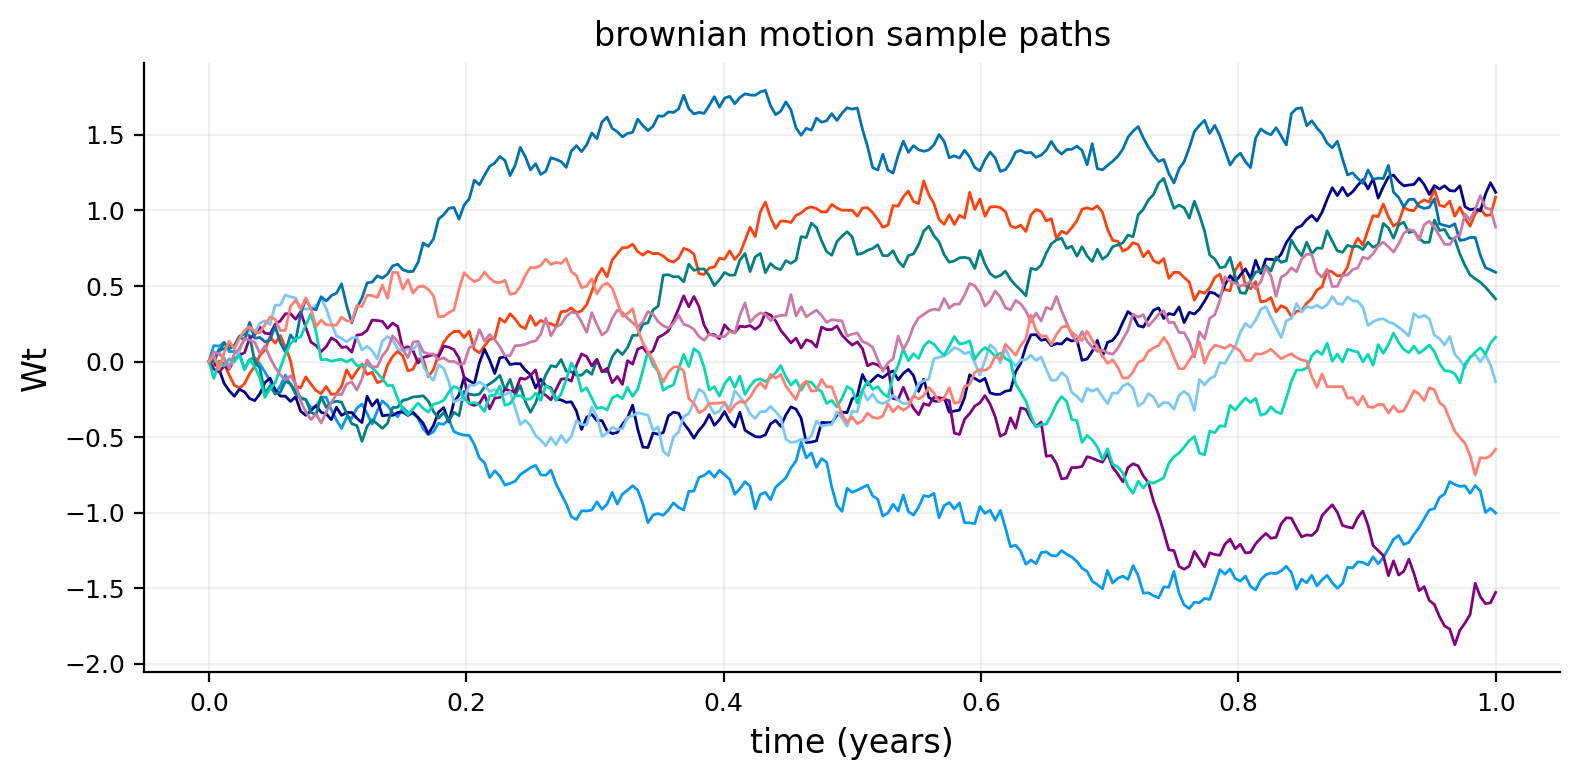

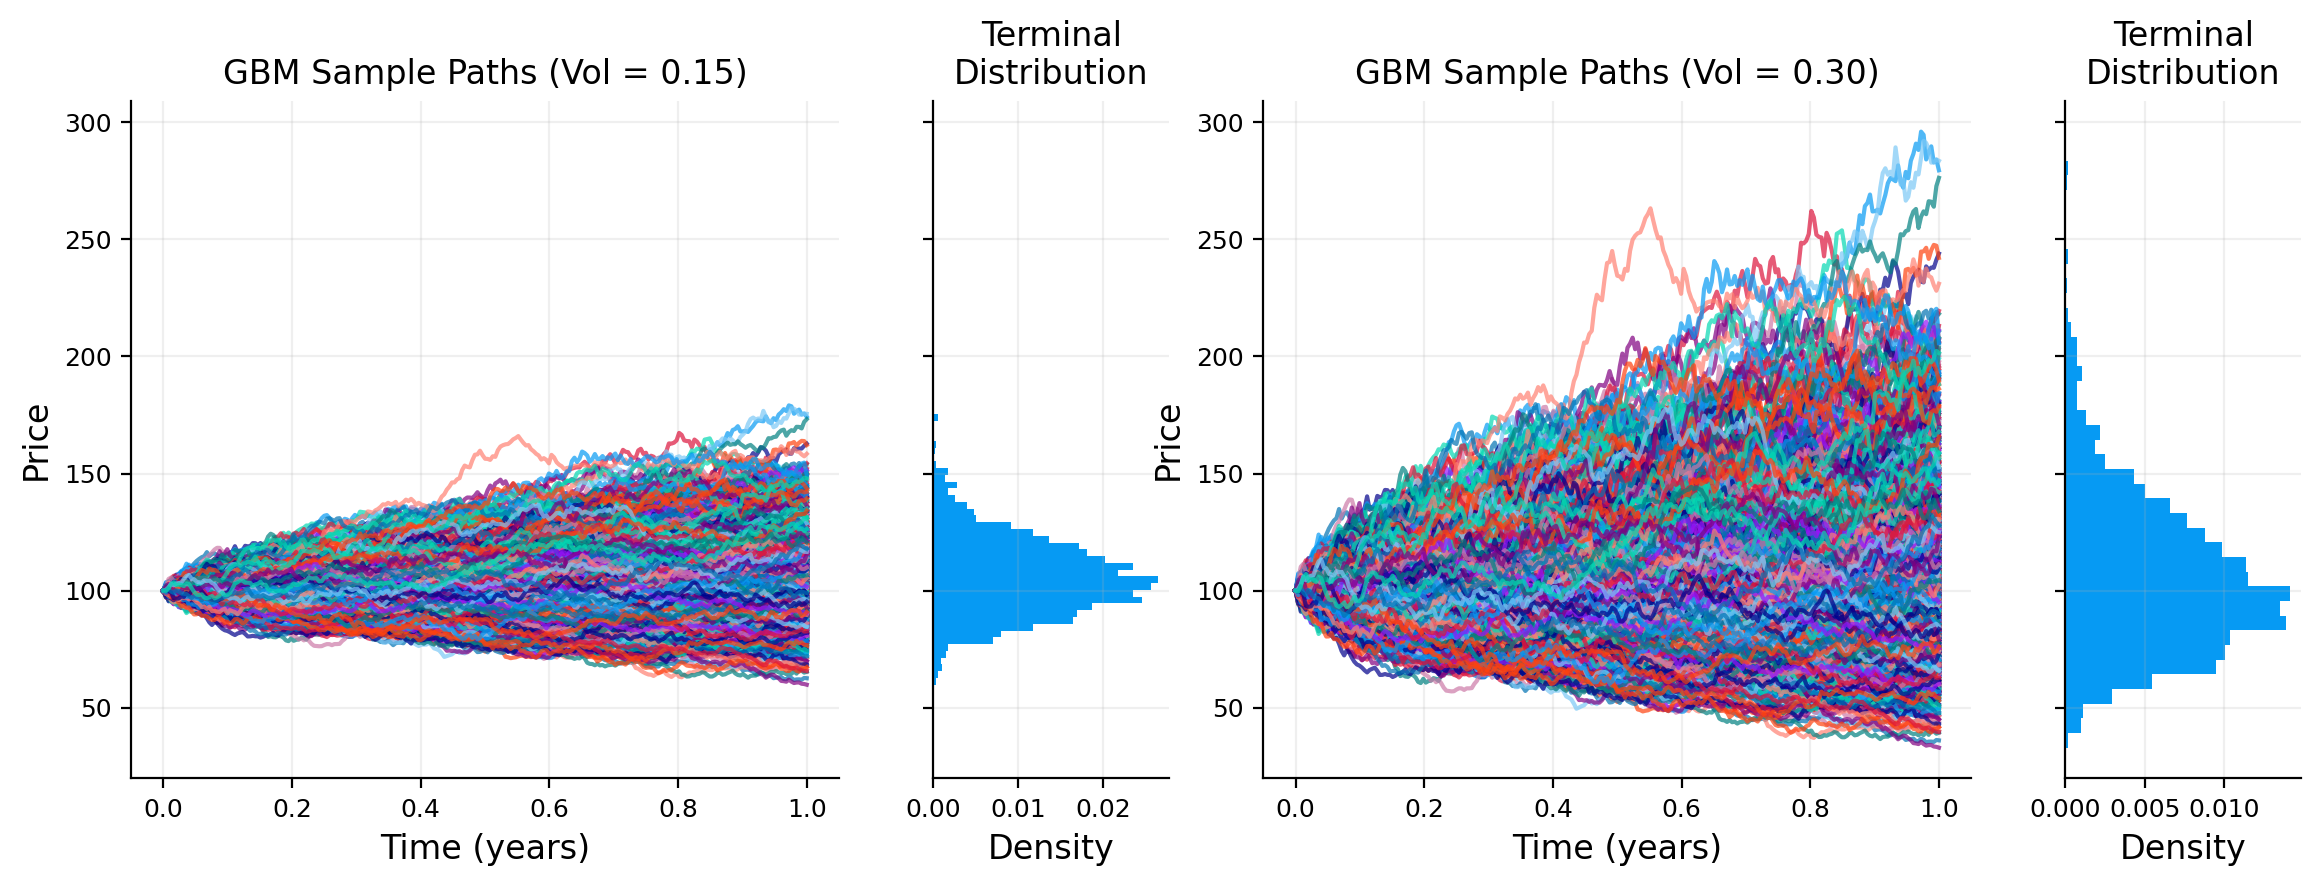

In [3]:
n_steps = 252
n_paths = 2000
dt = 1.0 / n_steps
t = np.linspace(0.0, 1.0, n_steps + 1)
z = np.random.normal(size=(n_steps, n_paths))
w = np.vstack([np.zeros(n_paths), np.cumsum(np.sqrt(dt) * z, axis=0)])

s0 = 100.0
mu = 0.06
sig_low = 0.15
sig_high = 0.30
gbm_low = s0 * np.exp((mu - 0.5 * sig_low * sig_low) * t[:, None] + sig_low * w)
gbm_high = s0 * np.exp((mu - 0.5 * sig_high * sig_high) * t[:, None] + sig_high * w)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, w[:, :10], lw=1.0)
ax.set_title("brownian motion sample paths")
ax.set_xlabel("time (years)")
ax.set_ylabel("Wt")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(14, 4.4))
gs = fig.add_gridspec(1, 4, width_ratios=[3, 1, 3, 1], hspace=0.3)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)
ax4 = fig.add_subplot(gs[0, 3], sharey=ax3)

ax1.plot(t, gbm_low, alpha=0.7)
ax1.set_title("GBM Sample Paths (Vol = 0.15)")
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Price")

ax2.hist(gbm_low[-1, :], bins=40, orientation='horizontal', density=True, lw=0.7)
ax2.set_xlabel("Density")
ax2.set_title("Terminal\nDistribution")
ax2.tick_params(labelleft=False)

ax3.plot(t, gbm_high, alpha=0.7)
ax3.set_title("GBM Sample Paths (Vol = 0.30)")
ax3.set_xlabel("Time (years)")
ax3.set_ylabel("Price")

ax4.hist(gbm_high[-1, :], bins=40, orientation='horizontal', density=True, lw=0.7)
ax4.set_xlabel("Density")
ax4.set_title("Terminal\nDistribution")
ax4.tick_params(labelleft=False)

plt.tight_layout()
plt.show()


## 4. The Black-Scholes Model

### 4.1 Risk-Neutral Pricing

Different investors have different risk appetites. Some are aggressive, some are conservative. If the price of an option depends on how much risk people are willing to take, then every investor would assign a different price to the same option.

In a risk-neutral world, all investors are indifferent to risk. They don't demand extra return for taking on risk. In such a world:
- All assets grow at the risk-free rate $r$ (not their actual expected return $\mu$)
- We can price derivatives by taking expected payoffs and discounting at rate $r$

Even though the real world is not risk-neutral, we can price options as if it were.

**Risk-neutral pricing formula**:

$$C(S_0, 0) = e^{-rT} E^Q[\max(S_T - K, 0)]$$

where:
- $E^Q$ denotes expectation under the **risk-neutral measure** (the "Q" measure)
- Under this measure, $S_t$ grows at rate $r$ instead of $\mu$:
  
  $$S_T = S_0 \exp\left[\left(r - \frac{\sigma^2}{2}\right)T + \sigma W_T\right]$$

Hedging with options doesn't depend on $\mu$, only on $\sigma$. So the price is the same whether we use the real-world measure (with $\mu$) or the risk-neutral measure (with $r$). So in this way and under this assumption we don't need to estimate $\mu$. We can use a risk-free rate as our expected return in the pricing formula.

### 4.2 Black Scholes Assumptions

The Black-Scholes model makes several key assumptions:

1. **Stock price follows GBM**: $dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$
2. **Constant volatility**: $\sigma$ is constant over time
3. **No dividends**: The stock pays no dividends during the option's life
4. **European options**: Can only be exercised at maturity
5. **No transaction costs**: No fees for buying/selling
6. **No arbitrage**: No risk-free profit opportunities (will get to it later)
7. **Risk-free rate is constant**: a risk-free asset exists with constant rate $r$
8. **Continuous trading**: Can trade at any time
9. **No restrictions on short selling**: Can borrow and sell assets you don't own


> We don’t actually believe that the stock will actually follow GBM perfectly. we use it because we need a probabilistic framework to price derivatives that depend on uncertain future values.


While these assumptions are idealized and not close to real world, the model works well in practice and forms the foundation of modern option pricing. and later we can adjust the model and use different models for handling different probabilities.

### 4.3 The Black-Scholes Partial Differential Equation

If $C(S, t)$ is the price of a call option when the stock price is $S$ at time $t$. The Black-Scholes PDE is:

$$\frac{\partial C}{\partial t} + rS\frac{\partial C}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} = rC$$


If We create a portfolio buying 1 option and shorting $\Delta = \frac{\partial C}{\partial S}$ shares of stock, the portfolio value is: $\Pi = C - \Delta S$

We need to track how the portfolio changes. Over a small time $dt$, the change in portfolio value is:
   $$d\Pi = dC - \Delta \, dS$$

We need to figure out what $dC$ and $dS$ are.
The option price $C(S, t)$ depends on both the stock price $S$ and time $t$.

Using Itô's lemma on $C(S,t)$:
   $$dC = \left(\frac{\partial C}{\partial t} + \mu S\frac{\partial C}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 C}{\partial S^2}\right) dt + \sigma S\frac{\partial C}{\partial S} \, dW_t$$


The first part (with $dt$) is the deterministic drift. The second part (with $dW_t$) is the random fluctuation. The stock also follows a GBM:

$$dS = \mu S \, dt + \sigma S \, dW_t$$

Plugging $dC$ and $dS$ into $d\Pi = dC - \Delta dS$ and choosing $\Delta = \frac{\partial C}{\partial S}$:

$$d\Pi = \left(\frac{\partial C}{\partial t} + \mu S\frac{\partial C}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 C}{\partial S^2}\right) dt + \sigma S\frac{\partial C}{\partial S} \, dW_t - \frac{\partial C}{\partial S}(\mu S \, dt + \sigma S \, dW_t)$$

   $$d\Pi = \left(\frac{\partial C}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 C}{\partial S^2}\right) dt$$

The $dW_t$ terms disappeared, and so did $\mu$. The portfolio is now completely deterministic and risk free. No randomness is left.

By no-arbitrage, Since the portfolio has no risk, it must earn the risk-free rate $r$.

$$d\Pi = r\Pi \, dt = r(C - \Delta S) \, dt = r(C - S\frac{\partial C}{\partial S})$$

$$\left(\frac{\partial C}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 C}{\partial S^2}\right) dt = r\left(C - S\frac{\partial C}{\partial S}\right)$$

$$\frac{\partial C}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} = rC - rS\frac{\partial C}{\partial S}$$

$$\frac{\partial C}{\partial t} + rS\frac{\partial C}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} = rC$$

This is how we get the Black-Scholes PDE.


### 4.5 The Black-Scholes Formula

Solving the Black-Scholes PDE (or equivalently, computing the risk-neutral expectation) gives the famous Black-Scholes formula.

**For a European call option**:

$$C(S_0, T, K, r, \sigma) = S_0 \Phi(d_1) - Ke^{-rT}\Phi(d_2)$$


$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$$

$$d_2 = d_1 - \sigma\sqrt{T} = \frac{\ln(S_0/K) + (r - \sigma^2/2)T}{\sigma\sqrt{T}}$$

and $\Phi(\cdot)$ is the cumulative distribution function (CDF) of the standard normal distribution:

$$\Phi(x) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{x} e^{-z^2/2} \, dz$$

**For a European put option** (using put-call parity):

$$P(S_0, T, K, r, \sigma) = Ke^{-rT}\Phi(-d_2) - S_0\Phi(-d_1)$$


The call option price has two terms:

1. $S_0 \Phi(d_1)$: The expected value of the stock at maturity, weighted by the probability of exercise, adjusted for the stock's current value
2. $Ke^{-rT}\Phi(d_2)$: The present value of the strike price, weighted by the probability of exercise


- $\Phi(d_2)$ is approximately the risk-neutral probability that the option will be exercised ($S_T > K$)
- $\Phi(d_1)$ is related to the expected value of the stock conditional on exercise

**Example calculation**:

Suppose:
- Current stock price: $S_0 = 100$
- Strike price: $K = 105$
- Time to maturity: $T = 0.25$ years (3 months)
- Risk-free rate: $r = 0.05$ (5% per year)
- Volatility: $\sigma = 0.20$ (20% per year)

Calculate $d_1$ and $d_2$:

$$d_1 = \frac{\ln(100/105) + (0.05 + 0.20^2/2) \times 0.25}{0.20\sqrt{0.25}} = \frac{-0.04879 + 0.0175}{0.10} = -0.3129$$

$$d_2 = -0.3129 - 0.20\sqrt{0.25} = -0.3129 - 0.10 = -0.4129$$

Look up normal CDF values:
- $\Phi(-0.3129) \approx 0.3772$
- $\Phi(-0.4129) \approx 0.3398$

Calculate call price:

$$C = 100 \times 0.3772 - 105 \times e^{-0.05 \times 0.25} \times 0.3398$$
$$C = 37.72 - 105 \times 0.9876 \times 0.3398$$
$$C = 37.72 - 35.22 = 2.50$$

The call option is worth approximately $\$2.50$.

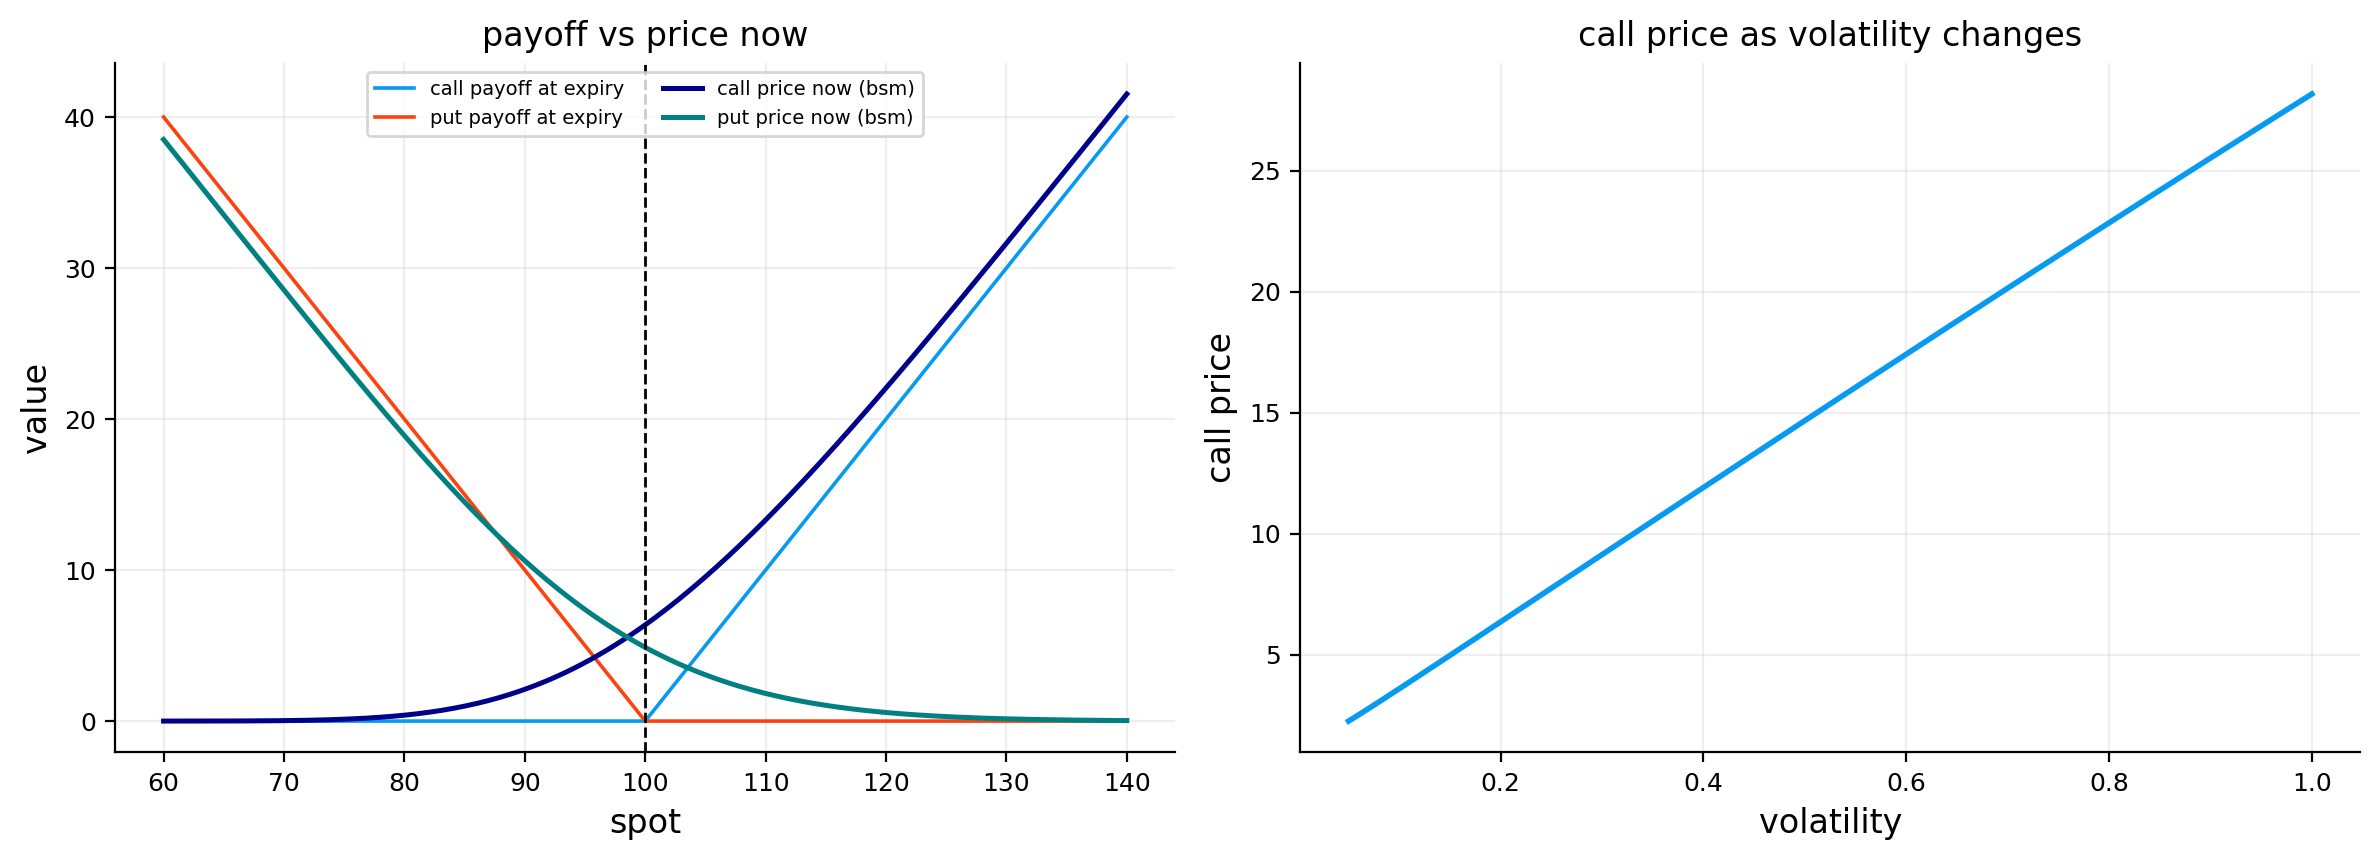

In [4]:
def bs_price_spot(cp, spot, strike, tau, rate, vol):
    tau = np.clip(np.asarray(tau, dtype=float), 1e-12, None)
    vol = np.clip(np.asarray(vol, dtype=float), 1e-8, None)
    spot = np.asarray(spot, dtype=float)
    strike = np.asarray(strike, dtype=float)
    rate = np.asarray(rate, dtype=float)
    d1 = (np.log(np.clip(spot, 1e-12, None) / np.clip(strike, 1e-12, None)) + (rate + 0.5 * vol * vol) * tau) / (vol * np.sqrt(tau))
    d2 = d1 - vol * np.sqrt(tau)
    arr_cp = np.asarray(cp)
    if arr_cp.ndim == 0:
        is_call = bool(str(arr_cp.item()).lower().startswith("c"))
    else:
        is_call = pd.Series(arr_cp.reshape(-1)).astype(str).str.lower().str.startswith("c").to_numpy().reshape(arr_cp.shape)
    call_val = spot * norm.cdf(d1) - strike * np.exp(-rate * tau) * norm.cdf(d2)
    put_val = strike * np.exp(-rate * tau) * norm.cdf(-d2) - spot * norm.cdf(-d1)
    return np.where(is_call, call_val, put_val)


strike = 100.0
rate = 0.03
tau = 0.5
spot_grid = np.linspace(60.0, 140.0, 240)
call_payoff = np.maximum(spot_grid - strike, 0.0)
put_payoff = np.maximum(strike - spot_grid, 0.0)
call_bs = bs_price_spot("call", spot_grid, strike, tau, rate, 0.2)
put_bs = bs_price_spot("put", spot_grid, strike, tau, rate, 0.2)

vol_grid = np.linspace(0.05, 1.0, 220)
price_vs_vol = bs_price_spot("call", 100.0, strike, tau, rate, vol_grid)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
axes[0].plot(spot_grid, call_payoff, lw=1.3, label="call payoff at expiry")
axes[0].plot(spot_grid, put_payoff, lw=1.3, label="put payoff at expiry")
axes[0].plot(spot_grid, call_bs, lw=1.8, label="call price now (bsm)")
axes[0].plot(spot_grid, put_bs, lw=1.8, label="put price now (bsm)")
axes[0].axvline(strike, lw=1.0, ls="--", c="k")
axes[0].set_title("payoff vs price now")
axes[0].set_xlabel("spot")
axes[0].set_ylabel("value")
axes[0].legend(loc="best", ncol=2)
axes[1].plot(vol_grid, price_vs_vol, lw=2.0)
axes[1].set_title("call price as volatility changes")
axes[1].set_xlabel("volatility")
axes[1].set_ylabel("call price")
plt.tight_layout()
plt.show()


## 5) Constructing the Risk-Free Rate Curve

Option pricing requires discounting future payoffs back to the present using the risk-free rate $r$. In practice, there isn't a single risk-free rate. instead, we observe a **term structure** of rates across different maturities (overnight, 1 month, 3 months, 1 year, etc.).

For accurate option pricing, we need to build a continuous discount curve from discrete market observations and for every option with a maturity, we have to use their own risk-free rate based on their maturity for pricing them.

in the first project we focused on how we can do this and compared different approaches. i recommend checking it out: [1. Fixed income and yield curve construction]

[1. Fixed income and yield curve construction]: https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/01_yield_curve_bond_pricing_and_risk.html

We use US treasury par yields again and only use the most accurate model for interpolation: Log-Linear

### 3.1 Handling the Short End

The **short end** (very short maturities, typically under 1 week) requires special treatment because the estimation can be noisy and we need a rate for emmidiate discounting.

**Our approach:**

We define a **short rate** $r_{\text{short}}$ at a small time horizon $\tau_{\text{short}} = 1/365.25$ (1 day). This rate is either:
- Extracted from the first available tenor using simple exponential decay
- Used as a constant for all maturities below the first observed tenor

This ensures we always have a well-defined rate for short-dated options without extrapolating into unstable regions.

The rest of the code is mostly covered in the first notebook.

In [5]:
def weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    values = values[mask]
    weights = weights[mask]
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    csum = np.cumsum(weights)
    idx = int(np.searchsorted(csum, 0.5 * weights.sum()))
    idx = int(np.clip(idx, 0, len(values) - 1))
    return float(values[idx])


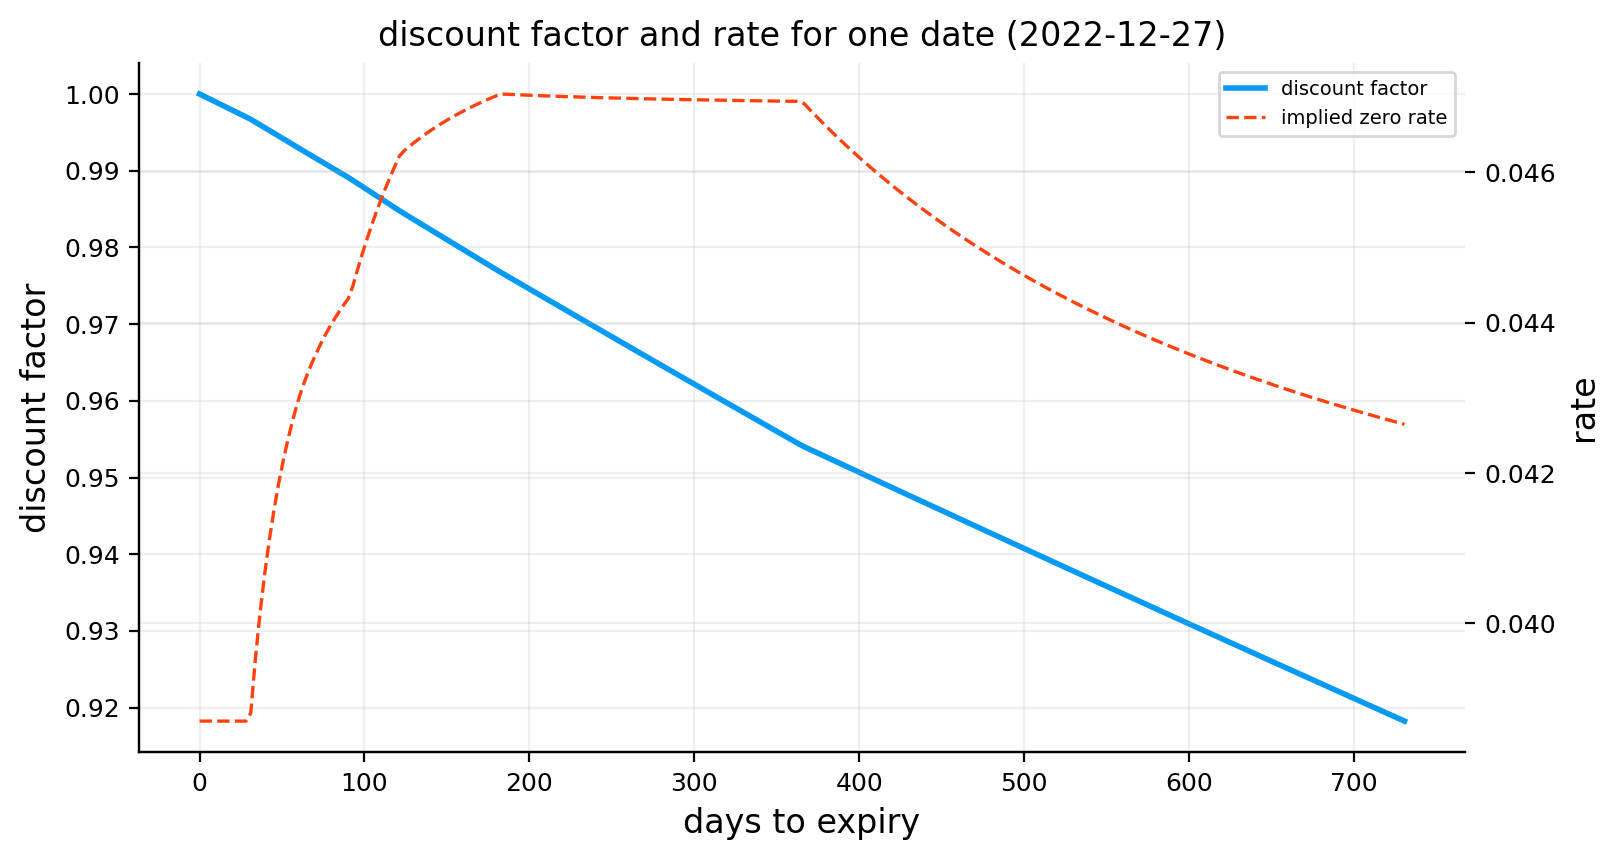

,metric,value
0,sample_date,2022-12-27
1,curve_date_used,2022-12-27
2,df_100d,0.987753
3,cc_zero_rate_100d,0.045009
4,short_rate_tau_days,1.000000


In [6]:
short_rate_tau = 1.0 / 365.25

rates_norm = fi.normalize_par_yields(df_rates.copy(), date_col="date")
rates_norm = rates_norm.sort_index()

curve_lookup = fi.make_discount_lookup(rates_norm, tenor_cols=list(rates_norm.columns),
                                      curve_method="loglinear", short_end="simple",
                                      short_end_policy="first_tenor_exp")

get_df = curve_lookup["get_df"]
get_rate = curve_lookup["get_rate"]
resolve_curve_date = curve_lookup["resolve_date"]
curve_mode = curve_lookup["curve_mode"]


def get_r_short(trade_date, tau_short=short_rate_tau):
    return float(get_rate(trade_date, tau_short))


curve_dates = np.sort(df_pairs["trade_date"].dropna().unique())
sample_date = pd.Timestamp(curve_dates[len(curve_dates) // 2]).normalize()

tau_grid = np.linspace(0.0, 2.0, 260)
df_grid = get_df(sample_date, tau_grid)
r_grid = np.where(
    tau_grid > 0,
    -np.log(np.clip(df_grid, 1e-12, None)) / np.clip(tau_grid, 1e-12, None),
    get_r_short(sample_date),
)
df_100d = float(get_df(sample_date, 100.0 / 365.25))
r_100d = float(-np.log(max(df_100d, 1e-12)) / (100.0 / 365.25))
cdate_sample = resolve_curve_date(sample_date)

fig, ax1 = plt.subplots(figsize=(8.2, 4.4))
ax1.plot(tau_grid * 365.25, df_grid, lw=2, label="discount factor")
ax1.set_xlabel("days to expiry")
ax1.set_ylabel("discount factor")
ax2 = ax1.twinx()
ax2.plot(tau_grid * 365.25, r_grid, lw=1.2, ls="--", c= palette[1], label="implied zero rate")
ax2.set_ylabel("rate")
ax1.set_title(f"discount factor and rate for one date ({sample_date.date()})")
ln1, lb1 = ax1.get_legend_handles_labels()
ln2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(ln1 + ln2, lb1 + lb2, loc="best")
plt.tight_layout()
plt.show()

df_curve_diag = pd.DataFrame(
    [{"metric": "sample_date", "value": str(sample_date.date())},
    {"metric": "curve_date_used", "value": str(pd.Timestamp(cdate_sample).date())},
    {"metric": "df_100d", "value": df_100d},
    {"metric": "cc_zero_rate_100d", "value": r_100d},
    {"metric": "short_rate_tau_days", "value": short_rate_tau * 365.25}])

df_curve_diag

## 6 Forward Price

### 6.1 Forward Price Estimation via Put-Call Parity

Before computing implied volatilities, we need a reliable estimate of the **forward price** $F$. Rather than using the spot price and an assumed dividend yield, we extract $F$ directly from market data using **put-call parity**:

$$C - P = D(t,T) \cdot (F - K)$$

Rearranging for the forward:

$$F(K) = K + \frac{C(K) - P(K)}{D(t,T)}$$

For each strike $K$ where we observe both a call and a put, this gives us an implied forward. In a perfect market, all strikes would give the same $F$. In practice, they vary due to bid-ask spreads, liquidity differences, and microstructure noise.

**Constructing the forward estimate:**

For each strike $K$, we compute:

$$F(K) = K + \frac{C_{\text{mid}} - P_{\text{mid}}}{D(t,T)}$$

We also compute bounds using bid-ask spreads:

$$F_{\text{low}}(K) = K + \frac{C_{\text{bid}} - P_{\text{ask}}}{D(t,T)}$$
$$F_{\text{high}}(K) = K + \frac{C_{\text{ask}} - P_{\text{bid}}}{D(t,T)}$$

Different strikes give slightly different forward estimates due to bid-ask spreads, Microstructure noise or violations of put-call parity like transaction costs or early exercise for American options

The interval $[F_{\text{low}}, F_{\text{high}}]$ is the feasible range. Any forward within this interval is consistent with no-arbitrage given the bid-ask spreads. $F_{\text{mid}}$ is our point estimate.

Then we aggregate these estimates using a weighted median, where the weight for each strike is:

$$w_K = \frac{1}{(C_{\text{ask}} - C_{\text{bid}}) + (P_{\text{ask}} - P_{\text{bid}})}$$

We then compute two diagnostics:

1. **Dispersion:** The interquartile range divided by the median
   - Measures the spread of forward estimates
   - Low dispersion shows consistent pricing across strikes

2. **Feasibility:** The fraction of strikes where $F_{\text{low}} \leq \hat{F} \leq F_{\text{high}}$
   - Measures how often our estimate falls within the no-arbitrage bounds
   - High feasibility shows the estimate is consistent with market prices

---

### 6.2 Pricing with the Black-Scholes Forward Formula

With the forward price in hand, we use the **forward form** of the Black-Scholes formula. This form separates discounting from the option's intrinsic pricing:

$$C = D(t,T) \left[ F \cdot \Phi(d_1) - K \cdot \Phi(d_2) \right]$$

$$P = D(t,T) \left[ K \cdot \Phi(-d_2) - F \cdot \Phi(-d_1) \right]$$

where:

$$d_1 = \frac{\ln(F/K) + \frac{1}{2}\sigma^2 \tau}{\sigma\sqrt{\tau}}, \qquad d_2 = d_1 - \sigma\sqrt{\tau}$$

We use the forward form because:

- We don't need to estimate the dividend yield or repo rate separately
- The forward already incorporates all carry costs
- It's more natural for market-making and relative value analysis


---

### 6.3 Arbitrage Bounds on Option Prices

Before attempting to solve for implied volatility, we check that the market price falls within no arbitrage bounds:

For calls:

$$D(t,T) \cdot \max(F - K, 0) \leq C \leq D(t,T) \cdot F$$

For puts:

$$D(t,T) \cdot \max(K - F, 0) \leq P \leq D(t,T) \cdot K$$

The lower bound is the discounted intrinsic value (the price if $\sigma = 0$). The upper bound is the discounted maximum possible payoff (the price as $\sigma \to \infty$).

If the market price violates these bounds, no implied volatility exists, and we flag the option accordingly.



## 7) Volatility

Volatility is the single most important input in options pricing. Unlike the stock price, interest rate, and time to expiration (which are directly observable), volatility must be estimated or inferred. We need volatility to price options, but we can only observe past price movements, not future ones, but also different market participants have different views on future volatility, creating trading opportunities and risk premia.

- Option prices are highly sensitive to volatility changes
- Future volatility is inherently uncertain and varies over time
- Volatility affects OTM options more than ITM options, creating the volatility smile (will get to them later)
- Investors pay for volatility exposure, creating systematic pricing patterns

There are so many different ways to estimate volatility:

- **Realized volatility (RV):** What actually happened — computed from historical returns
- **Implied volatility (IV):** What the market expects — extracted from option prices
- GARCH volatility forecast
- Local Volatility
- Stochastic volatility

We get to the first two in this notebook and the rest of the models in later projects.

---

### 7.1 Realized Volatility

**Realized volatility** is the volatility computed from actual price movements over a specific period in the history of the asset. It's backward-looking and objective.

For a time series of log returns $r_1, r_2, \ldots, r_n$:

$$\text{RV} = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (r_i - \bar{r})^2} \times \sqrt{252}$$

We use it as a benchmark to evaluate other volatility models.

---

## 7.2 Implied Volatility


In the Black-Scholes model, we can compute an option price given volatility $\sigma$:

$$C = D(t,T) \left[ F \Phi(d_1) - K \Phi(d_2) \right]$$

where:
- $F$ is the forward price
- $D(t,T)$ is the discount factor
- $d_1 = \frac{\ln(F/K) + \frac{1}{2}\sigma^2 \tau}{\sigma\sqrt{\tau}}$
- $d_2 = d_1 - \sigma\sqrt{\tau}$


But in practice, we observe market prices and want to find the volatility that produces those prices. This is the **implied volatility** — the market's expectation of future volatility embedded in option prices.

The problem is that there's no closed-form solution for $\sigma$ given $C$. We have similar options to the one we want to price that have traded before and their details and how much others priced it. We can find a $\sigma$ that makes the BSM model's price equal to the price that other have agreed on. We must solve numerically:

$$C_{\text{BSM}}(\sigma) = C_{\text{market}}$$

This is a root-finding problem. We seek the zero of the function $f(\sigma) = \text{BSM}(\sigma) - C_{\text{market}}$

 ---


### 7.2.1 Newton-Raphson Method

One of the most efficient methods for solving the implied volatility equation is **Newton-Raphson iteration**. This is a classic numerical optimization technique that uses both the function value and its derivative to converge rapidly.

The Newton-Raphson update rule:

$$\sigma_{n+1} = \sigma_n - \frac{f(\sigma_n)}{f'(\sigma_n)}$$

where:
- $f(\sigma) = \text{BSM}(\sigma) - C_{\text{market}}$ is the pricing error
- $f'(\sigma) = \frac{\partial \text{BSM}}{\partial \sigma} = \text{Vega}$ is the sensitivity of price to volatility (we get to it more later).


At each iteration, we approximate the function $f(\sigma)$ with its tangent line at $\sigma_n$:

$$f(\sigma) \approx f(\sigma_n) + f'(\sigma_n)(\sigma - \sigma_n)$$

Setting this equal to zero and solving for $\sigma$ gives the Newton-Raphson update. Geometrically, we're following the tangent line to where it crosses the $\sigma$-axis.

---

### 7.2.2 Bisection Method (The Safety Net)

Newton-Raphson is fast but can fail if:
- The initial guess is far from the solution
- Vega is very small (near zero or deep ITM/OTM)
- Numerical instability causes the update to overshoot

To ensure robustness, we combine Newton-Raphson with **bisection**, a slower but guaranteed-to-converge method.

**The bisection algorithm:**

1. Start with an interval $[\sigma_{\text{low}}, \sigma_{\text{high}}]$ that brackets the solution
2. Evaluate $f(\sigma_{\text{mid}})$ at the midpoint $\sigma_{\text{mid}} = \frac{\sigma_{\text{low}} + \sigma_{\text{high}}}{2}$
3. If $f(\sigma_{\text{mid}}) > 0$, the solution is in $[\sigma_{\text{low}}, \sigma_{\text{mid}}]$; otherwise it's in $[\sigma_{\text{mid}}, \sigma_{\text{high}}]$
4. Repeat until the interval is sufficiently small

It has linear convergance and it takes maybe to 20 iterations for convergence but convergence is guaranteed.

Our hybrid approach:

1. **Phase 1 (12 iterations):** Try Newton-Raphson with safeguards
   - If the Newton step would leave the bracketing interval $[\sigma_{\text{low}}, \sigma_{\text{high}}]$, fall back to bisection
   - Update the bracketing interval based on the sign of the pricing error
2. **Phase 2 (28 iterations):** Pure bisection as a fallback
   - If Newton-Raphson hasn't converged, switch to guaranteed bisection
   - This ensures we always return a result, even for difficult cases

This combination gives us the speed of Newton-Raphson with the reliability of bisection.

---

**Faster optimization with Numba**

Numba is a **just-in-time (JIT) compiler** for Python that translates Python functions into optimized machine code. For numerical algorithms like ours, it provides 10 to 100x faster execution and can run the code on different modes or even running on GPU.

Also another choice for faster code is precomputing. Instead of recomputing $\sqrt{\tau}$ and $\ln(F/K)$ in every iteration, we compute them once outside the loop and pass them as arguments. This eliminates redundant calculations and improves cache efficiency.




In [7]:
def cp_is_call(cp):
    arr = np.asarray(cp)
    if arr.ndim == 0:
        return bool(str(arr.item()).lower().startswith("c"))
    return np.char.startswith(np.char.lower(arr.astype(str)), "c")


def bsm_forward_price(cp, df, fwd, strike, tau, sigma):
    tau = np.clip(np.asarray(tau, dtype=float), 1e-12, None)
    sigma = np.clip(np.asarray(sigma, dtype=float), 1e-8, None)
    df = np.asarray(df, dtype=float)
    fwd = np.asarray(fwd, dtype=float)
    strike = np.asarray(strike, dtype=float)
    sqrt_tau = np.sqrt(tau)
    d1 = (np.log(np.clip(fwd, 1e-12, None) / np.clip(strike, 1e-12, None)) + 0.5 * sigma * sigma * tau) / (sigma * sqrt_tau)
    d2 = d1 - sigma * sqrt_tau
    is_call = cp_is_call(cp)
    call_val = df * (fwd * norm.cdf(d1) - strike * norm.cdf(d2))
    put_val = df * (strike * norm.cdf(-d2) - fwd * norm.cdf(-d1))
    return np.where(is_call, call_val, put_val)


def iv_bounds(cp, df, fwd, strike):
    is_call = cp_is_call(cp)
    df = np.asarray(df, dtype=float)
    fwd = np.asarray(fwd, dtype=float)
    strike = np.asarray(strike, dtype=float)
    low_call = df * np.maximum(fwd - strike, 0.0)
    high_call = df * fwd
    low_put = df * np.maximum(strike - fwd, 0.0)
    high_put = df * strike
    low = np.where(is_call, low_call, low_put)
    high = np.where(is_call, high_call, high_put)
    return low, high


iv_status = {0: "ok", 1: "nan_input",
             2: "bounds_violation", 3: "no_convergence"}


@njit
def norm_cdf_numba(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


@njit
def norm_pdf_numba(x):
    return 0.3989422804014327 * math.exp(-0.5 * x * x)


@njit
def bsm_price_precomputed_numba(is_call, df, fwd, strike, tau, sqrt_tau, log_fk, sigma):
    sigma = max(sigma, 1e-12)
    d1 = (log_fk + 0.5 * sigma * sigma * tau) / (sigma * sqrt_tau)
    d2 = d1 - sigma * sqrt_tau
    if is_call:
        return df * (fwd * norm_cdf_numba(d1) - strike * norm_cdf_numba(d2))
    return df * (strike * norm_cdf_numba(-d2) - fwd * norm_cdf_numba(-d1))


@njit
def bsm_vega_precomputed_numba(df, fwd, tau, sqrt_tau, log_fk, sigma):
    sigma = max(sigma, 1e-12)
    d1 = (log_fk + 0.5 * sigma * sigma * tau) / (sigma * sqrt_tau)
    return df * fwd * norm_pdf_numba(d1) * sqrt_tau


@njit
def bsm_volga_precomputed_numba(df, fwd, tau, sqrt_tau, log_fk, sigma):
    sigma = max(sigma, 1e-12)
    d1 = (log_fk + 0.5 * sigma * sigma * tau) / (sigma * sqrt_tau)
    d2 = d1 - sigma * sqrt_tau
    vega = df * fwd * norm_pdf_numba(d1) * sqrt_tau
    return vega * d1 * d2 / sigma


@njit
def iv_one_precomputed_core_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    if not (np.isfinite(price) and np.isfinite(low) and np.isfinite(high)
            and np.isfinite(df) and np.isfinite(fwd) and np.isfinite(strike) and np.isfinite(tau)):
        return np.nan, 1, 0
    if (price <= 0.0) or (df <= 0.0) or (fwd <= 0.0) or (strike <= 0.0) or (tau <= 0.0):
        return np.nan, 1, 0
    if (price < low - 1e-10) or (price > high + 1e-10):
        return np.nan, 2, 0
    lo = 1e-8
    hi = 5.0
    sigma = min(max(guess, 0.03), 2.0)
    n_iter = 0
    diff = 0.0

    for _ in range(12):
        n_iter += 1
        p = bsm_price_precomputed_numba(is_call, df, fwd, strike, tau, sqrt_tau, log_fk, sigma)
        diff = p - price
        if abs(diff) < 1e-8:
            return sigma, 0, n_iter

        if diff > 0.0:
            hi = sigma
        else:
            lo = sigma

        v = bsm_vega_precomputed_numba(df, fwd, tau, sqrt_tau, log_fk, sigma)
        if (not np.isfinite(v)) or (v < 1e-8):
            sigma = 0.5 * (lo + hi)
        else:
            nxt = sigma - diff / v
            if np.isfinite(nxt) and (lo < nxt < hi):
                sigma = nxt
            else:
                sigma = 0.5 * (lo + hi)

    for _ in range(28):
        n_iter += 1
        sigma = 0.5 * (lo + hi)
        p = bsm_price_precomputed_numba(is_call, df, fwd, strike, tau, sqrt_tau, log_fk, sigma)
        diff = p - price
        if abs(diff) < 1e-8:
            return sigma, 0, n_iter
        if diff > 0.0:
            hi = sigma
        else:
            lo = sigma

    return sigma, 3, n_iter


@njit
def iv_one_precomputed_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    sigma, status, _ = iv_one_precomputed_core_numba(
        is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk
    )
    return sigma, status


@njit(parallel=True)
def iv_array_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    n = len(price)
    sigma_out = np.empty(n, dtype=np.float64)
    status_out = np.empty(n, dtype=np.int64)
    for i in prange(n):
        sigma_i, status_i = iv_one_precomputed_numba(is_call[i],price[i],low[i],high[i],
                                                     guess[i],df[i],fwd[i],strike[i],
                                                     tau[i],sqrt_tau[i],log_fk[i])
        sigma_out[i] = sigma_i
        status_out[i] = status_i
    return sigma_out, status_out


@njit(parallel=True)
def iv_array_numba_with_iters(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    n = len(price)
    sigma_out = np.empty(n, dtype=np.float64)
    status_out = np.empty(n, dtype=np.int64)
    iter_out = np.empty(n, dtype=np.int64)
    for i in prange(n):
        sigma_i, status_i, iter_i = iv_one_precomputed_core_numba(is_call[i],price[i],low[i],
                                                                  high[i],guess[i],df[i],fwd[i],
                                                                  strike[i],tau[i],sqrt_tau[i],log_fk[i])
        sigma_out[i] = sigma_i
        status_out[i] = status_i
        iter_out[i] = iter_i
    return sigma_out, status_out, iter_out


def iv_guess_from_price(price, low, df, fwd, strike, tau):
    time_val = np.maximum(np.asarray(price, dtype=float) - np.asarray(low, dtype=float), 1e-12)
    scale = np.maximum(np.asarray(df, dtype=float) * np.maximum(np.asarray(fwd, dtype=float), np.asarray(strike, dtype=float)), 1e-12)
    guess = np.sqrt(2.0 * np.pi / np.maximum(np.asarray(tau, dtype=float), 1e-12)) * (time_val / scale)
    return np.clip(guess, 0.03, 2.0)



### 7.2.3 Let's be rational inspired method (Halley/Householder Refinement)

Inspired by Peter Jäckel's "Let's Be Rational" algorithm, this solver uses higher-order derivatives for faster convergence.

Householder correction (4 iterations):

Instead of the simple Newton step, we apply a **Halley-like correction** using Volga (the second derivative of price with respect to volatility):

$$\text{Volga} = \mathcal{V} \cdot \frac{d_1 \cdot d_2}{\sigma}$$

The corrected step is:

$$\sigma_{n+1} = \sigma_n - \frac{\Delta}{\mathcal{V}} \cdot \frac{1}{1 - \frac{\Delta}{2\mathcal{V}} \cdot \frac{\text{Volga}}{\mathcal{V}}}$$

where $\Delta = C_{\text{BS}}(\sigma_n) - C_{\text{market}}$.

Newton-Raphson has quadratic convergence: error $\sim \varepsilon^2$ per step. Halley/Householder has **cubic** convergence: error $\sim \varepsilon^3$ per step. With a good initial guess, 3-4 Householder iterations often suffice

The denominator $1 - \frac{\text{step} \cdot \text{Volga}}{2\mathcal{V}}$ corrects for the curvature of the price-volatility relationship. We apply a safety check: if the denominator is too small ($< 0.35$), we fall back to a plain Newton step.

After that we use bracketed Newton cleanup (8 iterations). Same as Solver 1. Catches any residual error.

And then short bisection finish (up to 28 iterations). Final safety net for extreme cases.

**Convergence is declared if any of:**
- $|C_{\text{BS}}(\sigma) - C_{\text{market}}| < 10^{-8}$
- $|\sigma_{\text{high}} - \sigma_{\text{low}}| < 10^{-7}$

---


### 7.2.4 Initial Guess

The quality of the initial guess dramatically affects convergence speed. A poor guess can cause Newton-Raphson to diverge or waste iterations.

We use three complementary approaches:

**Approach 1: Time-value heuristic**

$$\sigma_0 = \sqrt{\frac{2\pi}{\tau}} \cdot \frac{\text{time value}}{\max(D \cdot F, \; D \cdot K)}$$

This comes from the ATM approximation $C_{\text{ATM}} \approx D \cdot F \cdot \sigma \sqrt{\tau / (2\pi)}$, inverted for $\sigma$.

**Approach 2: Corrado-Miller forward formula**

This uses a quadratic approximation to the Black-Scholes formula. Starting from the **call-equivalent price** (converting puts to calls via parity):

$$C^* = \begin{cases} C & \text{if call} \\ C + D(F - K) & \text{if put} \end{cases}$$

then solving a quadratic involving the midpoint $\frac{1}{2}(DF - DK)$ and a discriminant correction.

**Approach 3: Transformed-space estimate (inspired by "Let's Be Rational")**

For away-from-the-money options, we work in a **normalized space**:

$$\beta = \frac{\text{time value}}{D \cdot \sqrt{F \cdot K}}$$

$$x = |\ln(F/K)|$$

and apply a Padé-like correction:

$$\sigma_{\text{total}} = \sqrt{2\pi} \cdot \beta \cdot (1 + 0.35x + 0.08x^2)$$

$$\sigma_0 = \frac{\sigma_{\text{total}}}{\sqrt{\tau}}$$

This approximation handles the transition from ATM (where $x \approx 0$) to deep OTM (where $x$ is large) smoothly.

**Adaptive seed selection:**

The second solver picks between these guesses based on moneyness:

| Region | Condition | Strategy |
|---|---|---|
| Near ATM | $\|x\| < 0.08$ | Average of heuristic and Corrado-Miller |
| Moderate OTM | $0.08 \leq \|x\| < 0.18$ | Average of Corrado-Miller and transformed |
| Deep OTM | $\|x\| \geq 0.18$ | Transformed-space estimate |

This ensures the initial guess is always in the right ballpark, regardless of moneyness.



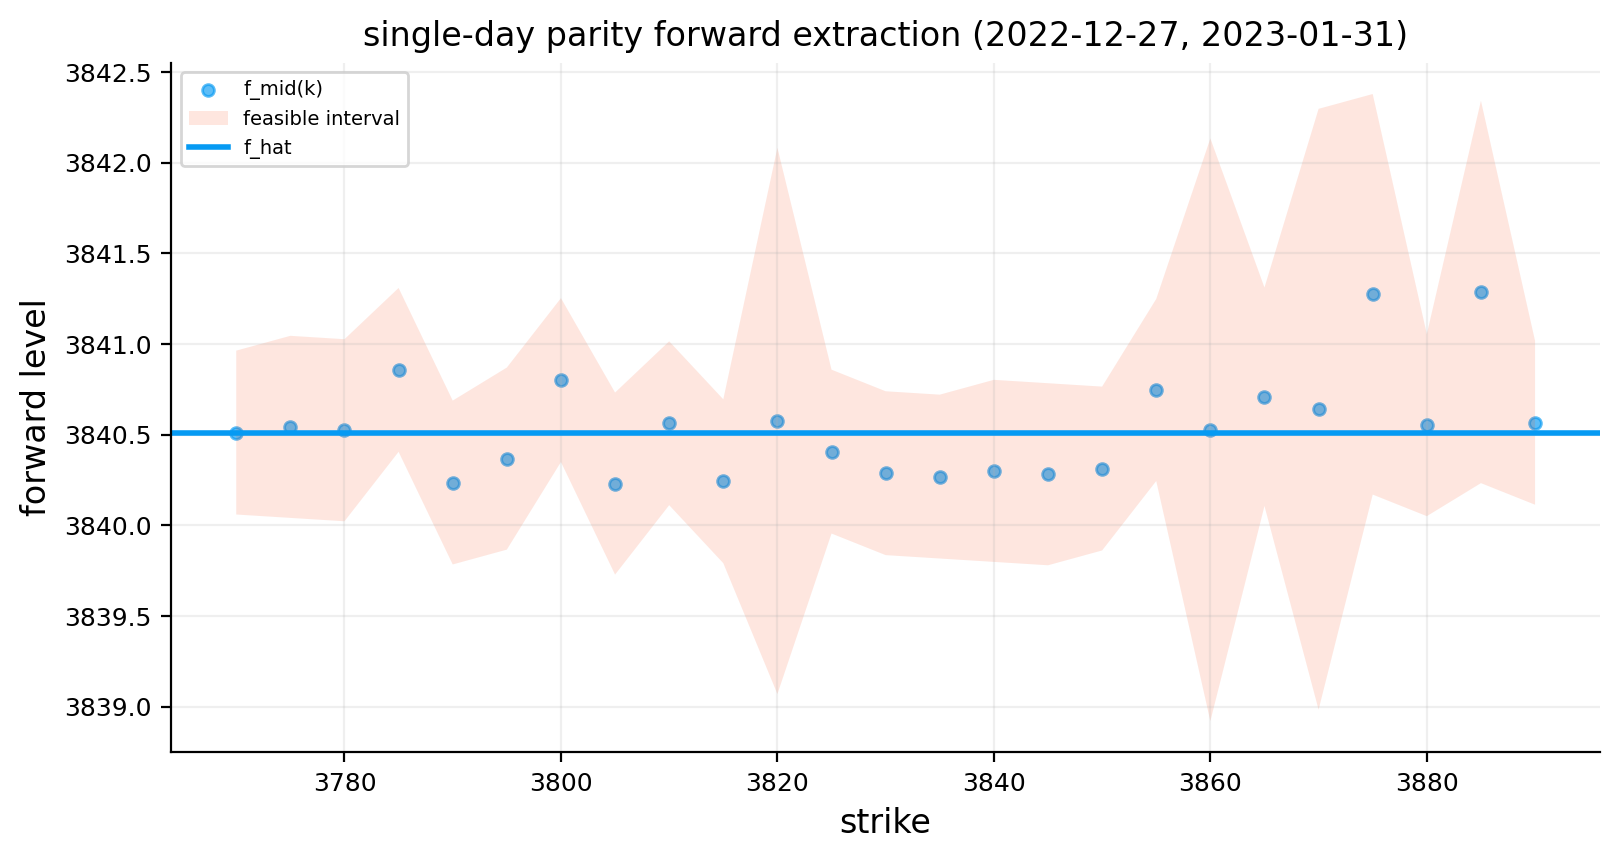

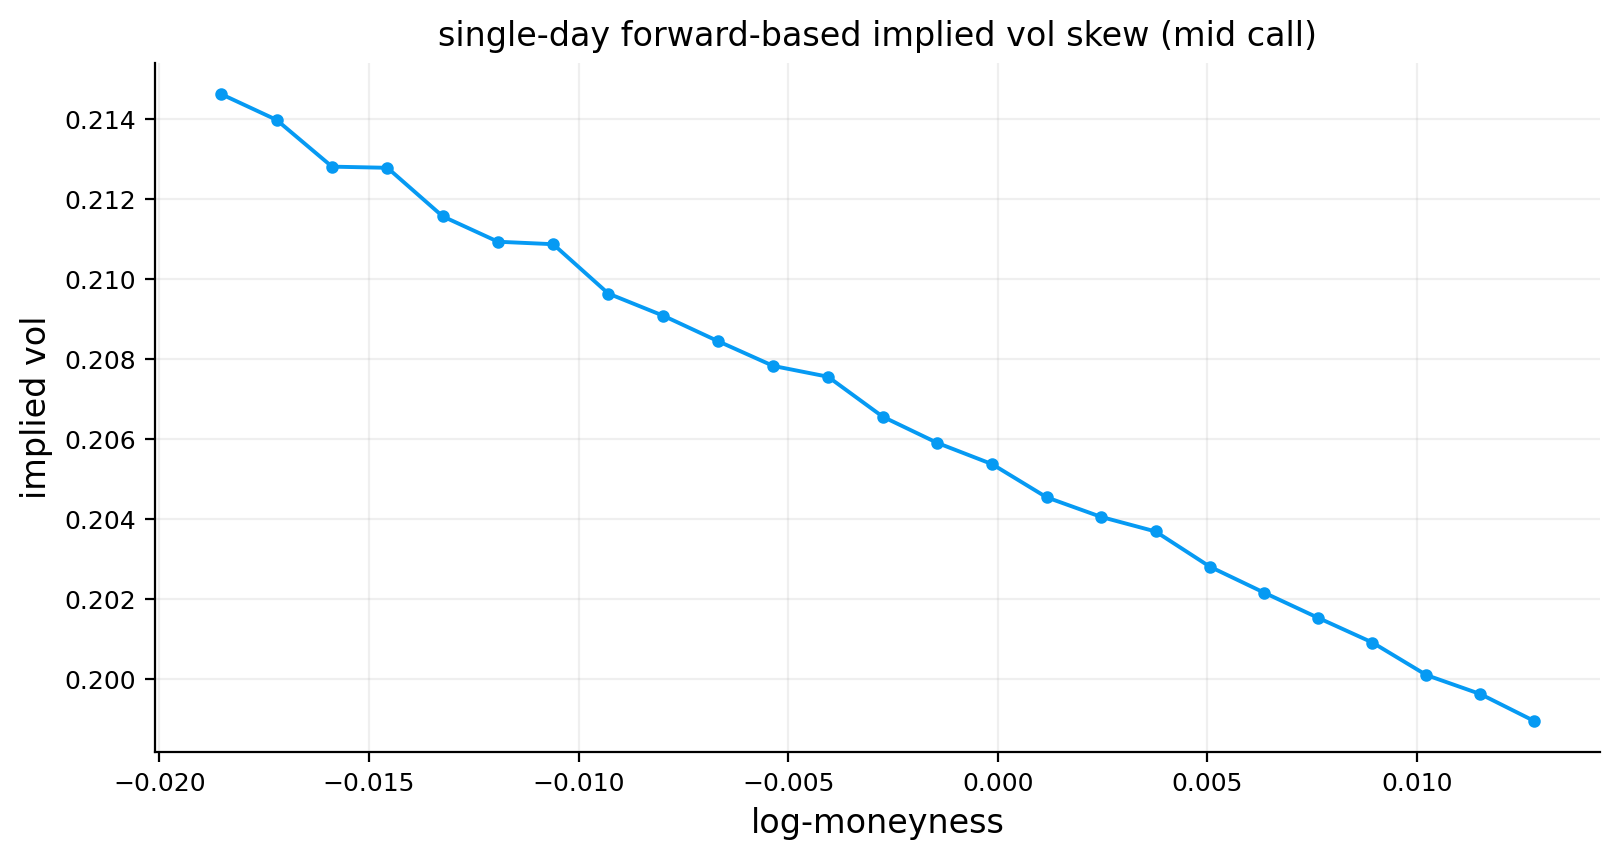

In [8]:
@njit
def call_equiv_price_numba(is_call, price, df, fwd, strike):
    if is_call:
        return price
    return price + df * (fwd - strike)


@njit
def iv_guess_cm_forward_numba(is_call, price, df, fwd, strike, tau):
    a = df * fwd
    b = df * strike
    c = call_equiv_price_numba(is_call, price, df, fwd, strike)
    core = c - 0.5 * (a - b)
    disc = core * core - (a - b) * (a - b) / math.pi
    if disc > 0.0 and (a + b) > 1e-12:
        sigma = math.sqrt(2.0 * math.pi / max(tau, 1e-12)) * (core + math.sqrt(disc)) / (a + b)
    else:
        sigma = math.sqrt(2.0 * math.pi / max(tau, 1e-12)) * c / max(0.5 * (a + b), 1e-12)
    if not np.isfinite(sigma):
        sigma = 0.20
    return min(max(sigma, 0.01), 4.0)


@njit
def iv_guess_transformed_lite_numba(price, low, df, fwd, strike, tau, log_fk):
    time_value = max(price - low, 1e-14)
    beta = time_value / max(df * math.sqrt(max(fwd * strike, 1e-14)), 1e-14)
    x = abs(log_fk)
    total_vol_guess = math.sqrt(2.0 * math.pi) * beta * (1.0 + 0.35 * x + 0.08 * x * x)
    sigma = total_vol_guess / math.sqrt(max(tau, 1e-12))
    return min(max(sigma, 0.01), 4.0)


@njit
def select_seed_lbr_lite_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    g0 = min(max(guess, 0.01), 4.0)
    g1 = iv_guess_cm_forward_numba(is_call, price, df, fwd, strike, tau)
    g2 = iv_guess_transformed_lite_numba(price, low, df, fwd, strike, tau, log_fk)

    x = abs(log_fk)
    if x < 0.08:
        sigma0 = 0.5 * (g0 + g1)
    elif x < 0.18:
        sigma0 = 0.5 * (g1 + g2)
    else:
        sigma0 = g2

    return min(max(sigma0, 0.01), 4.0)


@njit
def iv_one_lbr_lite_core_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    if not (np.isfinite(price) and np.isfinite(low) and np.isfinite(high)
            and np.isfinite(df) and np.isfinite(fwd) and np.isfinite(strike) and np.isfinite(tau)):
        return np.nan, 1, 0
    if (price <= 0.0) or (df <= 0.0) or (fwd <= 0.0) or (strike <= 0.0) or (tau <= 0.0):
        return np.nan, 1, 0
    if (price < low - 1e-10) or (price > high + 1e-10):
        return np.nan, 2, 0

    lo = 1e-8
    hi = 5.0
    sigma = select_seed_lbr_lite_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk)
    sigma = min(max(sigma, 0.01), 4.0)
    n_iter = 0
    diff = 0.0
    
    for _ in range(4):
        n_iter += 1
        p = bsm_price_precomputed_numba(is_call, df, fwd, strike, tau, sqrt_tau, log_fk, sigma)
        diff = p - price
        if abs(diff) < 1e-8:
            return sigma, 0, n_iter

        if diff > 0.0:
            hi = sigma
        else:
            lo = sigma

        v = bsm_vega_precomputed_numba(df, fwd, tau, sqrt_tau, log_fk, sigma)
        if (not np.isfinite(v)) or (v < 1e-10):
            sigma = 0.5 * (lo + hi)
            continue

        volga = bsm_volga_precomputed_numba(df, fwd, tau, sqrt_tau, log_fk, sigma)
        step = diff / v
        denom = 1.0 - 0.5 * step * volga / max(v, 1e-12)

        if np.isfinite(denom) and (abs(denom) > 0.35):
            nxt = sigma - step / denom
        else:
            nxt = sigma - step

        if (not np.isfinite(nxt)) or (nxt <= lo) or (nxt >= hi):
            nxt = 0.5 * (lo + hi)
        sigma = nxt

    for _ in range(8):
        n_iter += 1
        p = bsm_price_precomputed_numba(is_call, df, fwd, strike, tau, sqrt_tau, log_fk, sigma)
        diff = p - price
        if abs(diff) < 1e-8:
            return sigma, 0, n_iter
        if diff > 0.0:
            hi = sigma
        else:
            lo = sigma

        v = bsm_vega_precomputed_numba(df, fwd, tau, sqrt_tau, log_fk, sigma)
        if (not np.isfinite(v)) or (v < 1e-10):
            sigma = 0.5 * (lo + hi)
        else:
            nxt = sigma - diff / v
            if np.isfinite(nxt) and (lo < nxt < hi):
                sigma = nxt
            else:
                sigma = 0.5 * (lo + hi)

    for _ in range(28):
        n_iter += 1
        sigma = 0.5 * (lo + hi)
        p = bsm_price_precomputed_numba(is_call, df, fwd, strike, tau, sqrt_tau, log_fk, sigma)
        diff = p - price

        if (abs(diff) < 1e-8) or (abs(diff) < 1e-6) or ((hi - lo) < 1e-7):
            return sigma, 0, n_iter

        if diff > 0.0:
            hi = sigma
        else:
            lo = sigma

    if (abs(diff) < 1e-6) or ((hi - lo) < 1e-7):
        return sigma, 0, n_iter
    return sigma, 3, n_iter


@njit
def iv_one_lbr_lite_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    sigma, status, _ = iv_one_lbr_lite_core_numba(is_call, price, low, high, guess,
                                                   df, fwd, strike, tau, sqrt_tau, log_fk)
    return sigma, status


@njit(parallel=True)
def iv_array_lbr_lite_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    n = len(price)
    sigma_out = np.empty(n, dtype=np.float64)
    status_out = np.empty(n, dtype=np.int64)
    for i in prange(n):
        sigma_i, status_i = iv_one_lbr_lite_numba(is_call[i],price[i],low[i],high[i]
                                                  ,guess[i],df[i],fwd[i],strike[i],
                                                  tau[i],sqrt_tau[i],log_fk[i])
        sigma_out[i] = sigma_i
        status_out[i] = status_i
    return sigma_out, status_out


@njit(parallel=True)
def iv_array_lbr_lite_with_iters_numba(is_call, price, low, high, guess, df, fwd, strike, tau, sqrt_tau, log_fk):
    n = len(price)
    sigma_out = np.empty(n, dtype=np.float64)
    status_out = np.empty(n, dtype=np.int64)
    iter_out = np.empty(n, dtype=np.int64)
    for i in prange(n):
        sigma_i, status_i, iter_i = iv_one_lbr_lite_core_numba(is_call[i],price[i],low[i],high[i],
                                                               guess[i],df[i],fwd[i],strike[i],
                                                               tau[i],sqrt_tau[i],log_fk[i])
        sigma_out[i] = sigma_i
        status_out[i] = status_i
        iter_out[i] = iter_i
    return sigma_out, status_out, iter_out


def solve_iv_forward(cp, price, df, fwd, strike, tau, init_sigma=0.20):
    tau = float(max(float(tau), 1e-12))
    sqrt_tau = float(np.sqrt(tau))
    log_fk = float(np.log(max(float(fwd), 1e-12) / max(float(strike), 1e-12)))
    low, high = iv_bounds(cp, float(df), float(fwd), float(strike))
    low = float(np.asarray(low).reshape(-1)[0])
    high = float(np.asarray(high).reshape(-1)[0])
    guess = float(np.clip(init_sigma, 0.03, 2.0))
    sigma, status = iv_one_precomputed_numba(bool(cp_is_call(cp)),float(price),low,
                                             high,guess,float(df),float(fwd),float(strike),
                                             tau,sqrt_tau,log_fk)
    reason = iv_status.get(int(status), "unknown")
    return (float(sigma) if int(status) == 0 else np.nan), bool(int(status) == 0), reason

def estimate_forward_slice(df_slice, near_band=0.15):
    if df_slice.empty:
        return {"ok": False}
    tau = float(np.nanmedian(df_slice["tau"]))
    trade_date = pd.Timestamp(df_slice["trade_date"].iloc[0]).normalize()
    df_tau = float(get_df(trade_date, tau))
    strike = df_slice["strike"].to_numpy(dtype=float)
    c_bid = df_slice["c_bid"].to_numpy(dtype=float)
    c_ask = df_slice["c_ask"].to_numpy(dtype=float)
    c_mid = df_slice["c_mid"].to_numpy(dtype=float)
    p_bid = df_slice["p_bid"].to_numpy(dtype=float)
    p_ask = df_slice["p_ask"].to_numpy(dtype=float)
    p_mid = df_slice["p_mid"].to_numpy(dtype=float)
    w = 1.0 / np.clip((c_ask - c_bid) + (p_ask - p_bid), 1e-6, None)
    f_low = strike + (c_bid - p_ask) / df_tau
    f_high = strike + (c_ask - p_bid) / df_tau
    f_mid = strike + (c_mid - p_mid) / df_tau
    prelim = weighted_median(f_mid, w)
    lm = np.log(np.clip(strike, 1e-12, None) / np.clip(prelim, 1e-12, None))
    core = np.abs(lm) <= near_band
    if core.sum() < 3:
        ord_idx = np.argsort(np.abs(lm))
        core = np.zeros(len(lm), dtype=bool)
        core[ord_idx[: min(6, len(lm))]] = True
    f_hat = weighted_median(f_mid[core], w[core])
    med = np.nanmedian(f_mid[core])
    iqr = np.nanquantile(f_mid[core], 0.75) - np.nanquantile(f_mid[core], 0.25)
    dispersion = float(iqr / max(abs(med), 1e-8))
    feasibility = float(np.mean((f_hat >= f_low) & (f_hat <= f_high)))
    f_low_ref = weighted_median(f_low[core], w[core])
    f_high_ref = weighted_median(f_high[core], w[core])
    if not np.isfinite(f_low_ref):
        f_low_ref = float(np.nanmedian(f_low[core]))
    if not np.isfinite(f_high_ref):
        f_high_ref = float(np.nanmedian(f_high[core]))
    return {
        "ok": np.isfinite(f_hat),
        "trade_date": trade_date,
        "expiry_datetime": pd.Timestamp(df_slice["expiry_datetime"].iloc[0]),
        "tau": tau,
        "df": df_tau,
        "r_short": get_r_short(trade_date),
        "f_hat": float(f_hat),
        "f_low_ref": float(f_low_ref),
        "f_high_ref": float(f_high_ref),
        "dispersion": dispersion,
        "feasibility": feasibility,
        "n_obs": int(len(df_slice)),
        "n_core": int(core.sum())}


all_dates = np.sort(df_pairs["trade_date"].dropna().unique())
walk_trade_date = pd.Timestamp(all_dates[len(all_dates) // 2]).normalize()
day_slice = df_pairs[df_pairs["trade_date"] == walk_trade_date].copy()
day_slice["dte_days"] = day_slice["tau"] * 365.25
exp_rank = day_slice.groupby("expiry_datetime")["dte_days"].median().reset_index()
exp_rank["target_dist"] = (exp_rank["dte_days"] - 35.0).abs()
walk_expiry = exp_rank.sort_values("target_dist").iloc[0]["expiry_datetime"]
walk = day_slice[day_slice["expiry_datetime"] == walk_expiry].copy()

walk_est = estimate_forward_slice(walk, near_band=0.12)
walk_df = walk_est["df"]
walk_f_hat = walk_est["f_hat"]
walk["f_low"] = walk["strike"] + (walk["c_bid"] - walk["p_ask"]) / walk_df
walk["f_high"] = walk["strike"] + (walk["c_ask"] - walk["p_bid"]) / walk_df
walk["f_mid"] = walk["strike"] + (walk["c_mid"] - walk["p_mid"]) / walk_df
walk["lm_f"] = np.log(walk["strike"] / walk_f_hat)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.scatter(walk["strike"], walk["f_mid"], s=18, alpha=0.65, label="f_mid(k)")
ax.fill_between(walk["strike"], walk["f_low"], walk["f_high"], alpha=0.13, label="feasible interval")
ax.axhline(walk_f_hat, lw=2, label="f_hat")
ax.set_title(f"single-day parity forward extraction ({walk_trade_date.date()}, {pd.Timestamp(walk_expiry).date()})")
ax.set_xlabel("strike")
ax.set_ylabel("forward level")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

walk_prices = walk["c_mid"].to_numpy(dtype=float)
walk_strikes = walk["strike"].to_numpy(dtype=float)
walk_tau = walk["tau"].to_numpy(dtype=float)
walk_df_arr = np.full(len(walk), float(walk_df))
walk_fwd_arr = np.full(len(walk), float(walk_f_hat))
walk_low, walk_high = iv_bounds("call", walk_df_arr, walk_fwd_arr, walk_strikes)
walk_guess = iv_guess_from_price(walk_prices, walk_low, walk_df_arr, walk_fwd_arr, walk_strikes, walk_tau)
walk_tau = np.clip(walk_tau, 1e-12, None)
walk_sqrt_tau = np.sqrt(walk_tau)
walk_log_fk = np.log(np.clip(walk_fwd_arr, 1e-12, None) / np.clip(walk_strikes, 1e-12, None))
_ = iv_array_numba(np.ones(min(len(walk), 1), dtype=np.bool_), walk_prices[:1], walk_low[:1], walk_high[:1], walk_guess[:1], walk_df_arr[:1], walk_fwd_arr[:1], walk_strikes[:1], walk_tau[:1], walk_sqrt_tau[:1], walk_log_fk[:1])
walk_iv, walk_status = iv_array_numba(
    np.ones(len(walk), dtype=np.bool_), walk_prices, walk_low,
    walk_high, walk_guess, walk_df_arr, walk_fwd_arr,
    walk_strikes, walk_tau, walk_sqrt_tau, walk_log_fk)
df_walk_smile = pd.DataFrame({"lm_f": np.log(walk_strikes / walk_f_hat), "iv_mid": walk_iv, "status": walk_status})
df_walk_smile = df_walk_smile[df_walk_smile["status"] == 0].sort_values("lm_f")

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.plot(df_walk_smile["lm_f"], df_walk_smile["iv_mid"], marker="o", lw=1.4, ms=3.5)
ax.set_title("single-day forward-based implied vol skew (mid call)")
ax.set_xlabel("log-moneyness")
ax.set_ylabel("implied vol")
plt.tight_layout()
plt.show()


The smile we get is not really a symmetric smile. It is more like the familiar **equity-index skew**:

- higher implied vol for downside strikes
- lower implied vol for upside strikes
- a shape consistent with crash protection being expensive

That is a normal result for SPX options.

If we were careless and just plugged spot $S$ and a guessed dividend assumption directly into Black–Scholes, then part of the structure we attribute to volatility would actually be carry mismeasurement. For index options, that is a bad mistake. That's why using forward price can be the best way for handling dividend for assets that even don't pay dividends.

Some of the reasons that markets behave like this and create a skew can be:

- Demand for downside protection: Portfolio hedgers structurally buy OTM puts (low strikes) which pushes their prices (and IVs) higher
- Leverage effect: When the underlying falls, realized volatility tends to increase (firms become more leveraged), so options protecting against declines are priced with higher vol
- Jump risk: The market prices in the possibility of sudden large drops (crashes) more heavily than large rallies, fattening the left tail of the risk-neutral distribution
- Risk-neutral skewness: The skew encodes a negatively skewed risk-neutral distribution — the market assigns more probability to large down-moves than a lognormal model would

In [9]:
forward_rows = []
for key, grp in df_pairs.groupby(["trade_date", "expiry_datetime"], sort=True):
    est = estimate_forward_slice(grp, near_band=0.12)
    if est.get("ok", False):
        forward_rows.append(
            {"trade_date": est["trade_date"], "expiry_datetime": est["expiry_datetime"],
            "tau": est["tau"], "df": est["df"], "r_short": est["r_short"],
            "f_hat": est["f_hat"], "f_low_ref": est["f_low_ref"],
            "f_high_ref": est["f_high_ref"], "dispersion": est["dispersion"],
            "feasibility": est["feasibility"], "n_obs": est["n_obs"], "n_core": est["n_core"]})
        
df_forward = pd.DataFrame(forward_rows)
disp_cut = float(np.nanquantile(df_forward["dispersion"], 0.95)) if len(df_forward) else np.nan
disp_limit = float(max(0.02, disp_cut if np.isfinite(disp_cut) else 0.02))
feas_limit = 0.50
df_forward["forward_quality_ok"] = (df_forward["feasibility"] >= feas_limit) & (df_forward["dispersion"] <= disp_limit)
merge_cols = ["trade_date", "expiry_datetime", "df", "r_short", "f_hat", "f_low_ref", "f_high_ref",
              "dispersion", "feasibility", "n_obs", "n_core", "forward_quality_ok"]

df_pairs = df_pairs.merge(df_forward[merge_cols], on=["trade_date", "expiry_datetime"], how="inner")
df_pairs["lm_f"] = np.log(df_pairs["strike"] / df_pairs["f_hat"])
df_pairs["dte_days"] = df_pairs["tau"] * 365.25

df_forward_quality_summary = pd.DataFrame(
    [{"metric": "n_forward_slices", "value": int(len(df_forward))},
    {"metric": "dispersion_limit", "value": float(disp_limit)},
    {"metric": "feasibility_limit", "value": float(feas_limit)},
    {"metric": "share_quality_ok", "value": float(np.nanmean(df_forward["forward_quality_ok"])) if len(df_forward) else np.nan}])

print("df_forward shape:", df_forward.shape)
print("df_pairs with forward shape:", df_pairs.shape)
df_forward_quality_summary


df_forward shape: (11969, 13)
df_pairs with forward shape: (299214, 41)


,metric,value
0,n_forward_slices,"11,969.000000"
1,dispersion_limit,0.020000
2,feasibility_limit,0.500000
3,share_quality_ok,0.992898


### Quality flags

A slice is more trustworthy when:
   - dispersion is small
   - feasibility is high
   - enough strikes survive filtering

Nearly 12,000 unique (trade date, expiry) combinations were processed. 99.3% of slices out of 11,969 passed quality checks and had acceptable amount of feasibility and dispersion.

---

## 8) Computing rolling realized volatility:

Starting from the SPX closing prices, we compute log-returns:

$$r_t = \ln\!\left(\frac{S_t}{S_{t-1}}\right)$$

Then, for each lookback window $w \in \{10, 21, 42, 63, 84, 126\}$ trading days, we compute the annualized realized volatility:

$$\text{RV}_w(t) = \sigma_w(t) \cdot \sqrt{252}$$

where $\sigma_w(t)$ is the rolling standard deviation of the most recent $w$ log-returns. This gives us six realized volatility time series, each capturing a different horizon of historical price variability.


We use multiple windows because a 10-day option should be compared to recent short-term realized vol, while a 4-month option should be compared to a longer-horizon estimate. A single fixed window would create a maturity mismatch.


#### 8.1 . Maturity-Matched Realized Volatility

Each option has a specific time to expiry $\tau$. If the time to expiry of an option is not exactly one of our computed windows and it's between two of them, we can compute it's RV using the windows that it's between them with **linear interpolation** across the six rolling windows.

For each option row, we collect the six RV values $[\text{RV}_{10}, \text{RV}_{21}, \dots, \text{RV}_{126}]$ observed on that trade date and then we interpolate linearly at the target day count $d$

$$\text{RV}_{\text{matched}} = \text{interp}(d; \; \mathbf{w}, \; \mathbf{RV})$$

where $\mathbf{w} = [10, 21, 42, 63, 84, 126]$ are the knot points and $\mathbf{RV}$ are the corresponding realized volatilities (after dropping any NaN entries from insufficient history).

Example: A 35-day option observed on a date where $\text{RV}_{21} = 18\%$ and $\text{RV}_{42} = 16\%$ would receive:

$$\text{RV}_{\text{matched}} \approx 18\% + \frac{35 - 21}{42 - 21} \times (16\% - 18\%) = 18\% - 1.33\% \approx 16.67\%$$

We use this as our baseline for estimating volatility which is not accurate at all, but we can compare it to implied volatility and other volatility models later. 


In [10]:
df_spx = df_spx.sort_values("trade_date").drop_duplicates("trade_date", keep="last")
df_spx["ret"] = np.log(df_spx["close"] / df_spx["close"].shift(1))
rv_windows = [10, 21, 42, 63, 84, 126]
for w in rv_windows:
    df_spx[f"rv_{w}"] = df_spx["ret"].rolling(w).std() * np.sqrt(252.0)

call_cols = ["trade_date","quote_datetime","expiry_datetime","tau","dte_days",
             "s","strike","pair_id","f_hat","f_low_ref","f_high_ref","df","r_short",
             "lm_f","dispersion","feasibility","forward_quality_ok","c_bid","c_ask",
             "c_mid","c_spread","c_rel_spread","c_volume",]

put_cols = ["trade_date","quote_datetime","expiry_datetime","tau","dte_days","s",
            "strike","pair_id","f_hat","f_low_ref","f_high_ref","df","r_short","lm_f",
            "dispersion","feasibility","forward_quality_ok","p_bid","p_ask","p_mid",
            "p_spread","p_rel_spread","p_volume",]

df_call = df_pairs[call_cols].copy().rename(
    columns={"c_bid": "bid","c_ask": "ask","c_mid": "mid","c_spread": "spread",
             "c_rel_spread": "rel_spread","c_volume": "volume"})

df_call["cp"] = "call"
df_call["contract_id"] = df_call["pair_id"] + "_c"

df_put = df_pairs[put_cols].copy().rename(
    columns={"p_bid": "bid","p_ask": "ask","p_mid": "mid","p_spread": "spread",
             "p_rel_spread": "rel_spread","p_volume": "volume"})

df_put["cp"] = "put"
df_put["contract_id"] = df_put["pair_id"] + "_p"


df_options = pd.concat([df_call, df_put], ignore_index=True)

df_options = df_options.merge(df_spx[["trade_date"] + [f"rv_{w}" for w in rv_windows]], on="trade_date", how="left")
window_arr = np.array(rv_windows, dtype=float)
days = np.clip(np.round(df_options["tau"] * 365.25).to_numpy(dtype=float), window_arr.min(), window_arr.max())
rv_mat = df_options[[f"rv_{w}" for w in rv_windows]].to_numpy(dtype=float)
realized_vol = np.full(len(df_options), np.nan, dtype=float)
for i in range(len(df_options)):
    row = rv_mat[i]
    mask = np.isfinite(row)
    if mask.sum() == 0:
        continue
    if mask.sum() == 1:
        realized_vol[i] = float(row[mask][0])
        continue
    realized_vol[i] = float(np.interp(days[i], window_arr[mask], row[mask]))

df_options["rv_window"] = days
df_options["realized_vol"] = realized_vol

df_options = df_options[df_options["lm_f"].abs() <= 0.25].copy()
df_options = df_options[df_options["forward_quality_ok"].fillna(False)].copy()
df_options["half_spread"] = 0.5 * np.clip(df_options["ask"] - df_options["bid"], 0.0, None)
df_options = df_options.dropna(subset=["realized_vol"]).reset_index(drop=True)

print("df_options shape:", df_options.shape)


df_options shape: (585186, 34)


We now use realized volatility to price every option with the forward-form Black–Scholes model and then compares the model price against the market mid quote.

So if the realized-vol model misses, that does not mean Black–Scholes fails in a narrow mathematical sense. It means a flat-volatility specification is too poor to represent the market surface.

### vega scaled error

A raw dollar pricing error is useful, but it can also be misleading. A \$2 error on a high-vega, long-dated ATM contract is not the same thing as a \$2 error on a short-dated low-vega option. The same dollar difference can imply very different volatility misspecification.

That is why we compute a vega-scaled error:

$$
\text{vega-scaled error}
=
\frac{V^{\text{model}} - V^{\text{mkt}}}{\max(|\mathcal V|, \varepsilon)}.
$$

This shows how large is the pricing miss relative to the contract's volatility sensitivity

The small floor $\varepsilon$ is there so that the ratio does not explode when vega is extremely small.

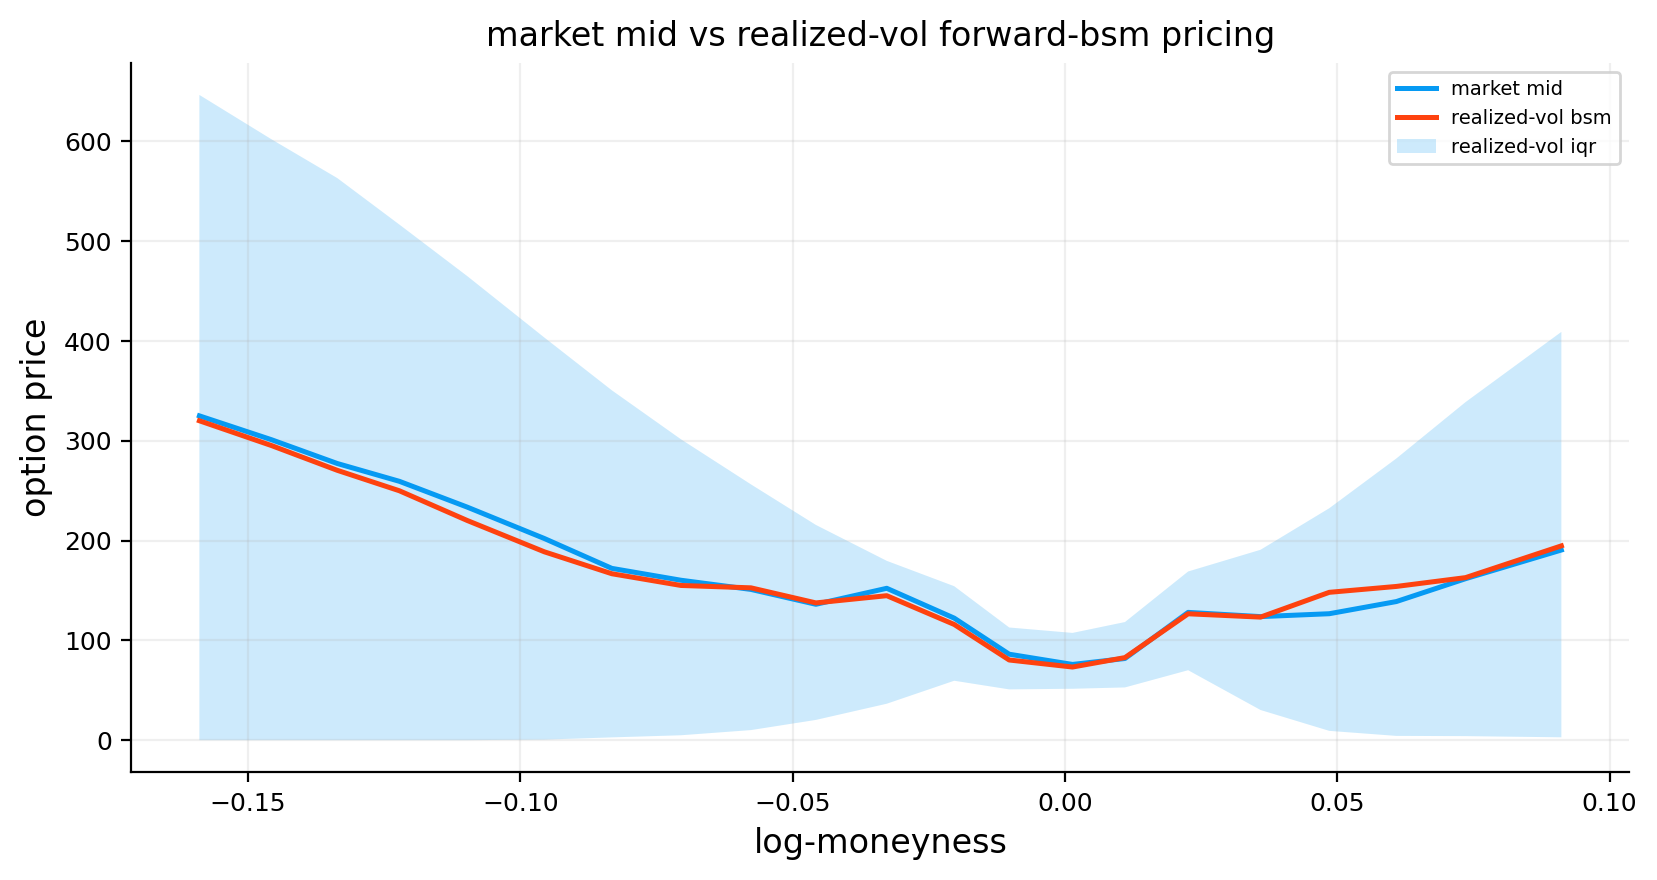

,metric,value
0,median_abs_error,9.790763
1,median_vega_scaled_error,-0.007784
2,inside_spread_hit_rate,0.035271
3,n_quotes,"585,186.000000"


In [11]:
def binned_summary(x, y, bins=21):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 10:
        return pd.DataFrame(columns=["x_mid", "y_med", "y_q1", "y_q3", "count"])
    x = x[mask]
    y = y[mask]
    q = np.linspace(np.nanmin(x), np.nanmax(x), bins + 1)
    q = np.unique(q)
    if len(q) < 3:
        return pd.DataFrame(columns=["x_mid", "y_med", "y_q1", "y_q3", "count"])
    cut = pd.cut(x, bins=q, include_lowest=True, duplicates="drop")
    grp = pd.DataFrame({"x": x, "y": y, "cut": cut}).groupby("cut", observed=False)

    out = grp.agg(x_mid=("x", "median"), y_med=("y", "median"), 
                  y_q1=("y", lambda z: np.nanquantile(z, 0.25)), y_q3=("y", lambda z: np.nanquantile(z, 0.75)),
                  count=("y", "size"),).reset_index(drop=True)
    return out


def forward_vega(cp, df, fwd, strike, tau, sigma):
    tau = np.clip(np.asarray(tau, dtype=float), 1e-12, None)
    sigma = np.clip(np.asarray(sigma, dtype=float), 1e-8, None)
    d1 = (np.log(np.clip(fwd, 1e-12, None) / np.clip(strike, 1e-12, None)) + 0.5 * sigma * sigma * tau) / (sigma * np.sqrt(tau))
    return np.asarray(df, dtype=float) * np.asarray(fwd, dtype=float) * norm.pdf(d1) * np.sqrt(tau)


df_options["price_realized"] = bsm_forward_price(
    df_options["cp"].values, df_options["df"].values, df_options["f_hat"].values,
    df_options["strike"].values, df_options["tau"].values, df_options["realized_vol"].values)

df_options["vega_realized"] = forward_vega(
    df_options["cp"].values, df_options["df"].values, df_options["f_hat"].values,
    df_options["strike"].values, df_options["tau"].values, df_options["realized_vol"].values)

df_options["err_realized"] = df_options["price_realized"] - df_options["mid"]
vega_abs_realized = np.abs(df_options["vega_realized"].to_numpy(dtype=float))
vega_pos_realized = vega_abs_realized[np.isfinite(vega_abs_realized) & (vega_abs_realized > 0)]
vega_floor_realized = float(max(1e-6, np.nanpercentile(vega_pos_realized, 5) if len(vega_pos_realized) else 1e-6))
df_options["vega_scale_realized"] = np.maximum(np.abs(df_options["vega_realized"]), vega_floor_realized)
df_options["vega_scaled_err_realized"] = df_options["err_realized"] / df_options["vega_scale_realized"]
df_options["hit_realized"] = ((df_options["price_realized"] >= df_options["bid"]) & (df_options["price_realized"] <= df_options["ask"])).astype(float)

bin_mkt = binned_summary(df_options["lm_f"], df_options["mid"])
bin_rv = binned_summary(df_options["lm_f"], df_options["price_realized"])
fig, ax = plt.subplots(figsize=(8.4, 4.5))
ax.plot(bin_mkt["x_mid"], bin_mkt["y_med"], lw=1.8, label="market mid")
ax.plot(bin_rv["x_mid"], bin_rv["y_med"], lw=1.8, label="realized-vol bsm")
ax.fill_between(bin_rv["x_mid"], bin_rv["y_q1"], bin_rv["y_q3"], alpha=0.20, label="realized-vol iqr")
ax.set_title("market mid vs realized-vol forward-bsm pricing")
ax.set_xlabel("log-moneyness")
ax.set_ylabel("option price")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

df_realized_summary = pd.DataFrame(
    {"metric": ["median_abs_error", "median_vega_scaled_error", "inside_spread_hit_rate", "n_quotes"],
    "value": [float(np.nanmedian(np.abs(df_options["err_realized"]))),
              float(np.nanmedian(df_options["vega_scaled_err_realized"])),
              float(np.nanmean(df_options["hit_realized"])),
              int(len(df_options))]})

df_realized_summary


Only 1 in 28 realized-vol prices lands within the bid-ask spread

As we can see, The realized-vol model is a poor predictor of option prices. This is entirely expected, and the results quantify why implied volatility extraction is necessary.

The median vega-scaled error of $-0.78\%$ reveals the variance risk premium (VRP) in action. The negative sign means that, on average:

$$\sigma_{\text{impl}} > \sigma_{\text{RV}}$$

The market systematically prices options above the level justified by recent realized volatility.

The dollar error reflects the compounding of the vol mismatch across the range of option maturities and strikes. For a long-dated or high-vega option, even a small vol discrepancy translates into a large dollar difference. This is why vega-scaling is essential. the dollar error alone conflates the pricing bias with the mechanical sensitivity of each contract.

The hit rate here is the most striking result. If realized vol were a reasonable proxy for the market's pricing volatility, we would expect the hit rate to be substantially higher (maybe 40–60\%). A hit rate of 3.5\% means the realized-vol model is outside the bid-ask spread for 96.5\% of all options. The model is not even in the right neighborhood for most contracts.

This proves even more that **implied volatility carries information that realized volatility does not**

In [12]:
t_compile0 = time.time()

n = len(df_options)
cp_arr = df_options["cp"].to_numpy()
is_call_arr = cp_is_call(cp_arr).astype(np.bool_)
mid_arr = df_options["mid"].to_numpy(dtype=float)
bid_arr = df_options["bid"].to_numpy(dtype=float)
ask_arr = df_options["ask"].to_numpy(dtype=float)
df_arr = df_options["df"].to_numpy(dtype=float)
fwd_arr = df_options["f_hat"].to_numpy(dtype=float)
strike_arr = df_options["strike"].to_numpy(dtype=float)
tau_arr = np.clip(df_options["tau"].to_numpy(dtype=float), 1e-12, None)
sqrt_tau_arr = np.sqrt(tau_arr)
log_fk_arr = np.log(np.clip(fwd_arr, 1e-12, None) / np.clip(strike_arr, 1e-12, None))
low_arr, high_arr = iv_bounds(cp_arr, df_arr, fwd_arr, strike_arr)

guess_mid_arr = iv_guess_from_price(mid_arr, low_arr, df_arr, fwd_arr, strike_arr, tau_arr)
guess_bid_arr = iv_guess_from_price(np.maximum(bid_arr, low_arr + 1e-10), low_arr, df_arr, fwd_arr, strike_arr, tau_arr)
guess_ask_arr = iv_guess_from_price(np.minimum(ask_arr, high_arr - 1e-10), low_arr, df_arr, fwd_arr, strike_arr, tau_arr)

warm_n = min(max(8, min(n, 512)), n)

_ = iv_array_numba_with_iters(is_call_arr[:warm_n], mid_arr[:warm_n], low_arr[:warm_n],
                               high_arr[:warm_n], guess_mid_arr[:warm_n], df_arr[:warm_n],
                                 fwd_arr[:warm_n], strike_arr[:warm_n], tau_arr[:warm_n],
                                   sqrt_tau_arr[:warm_n], log_fk_arr[:warm_n])

compile_numba_sec = time.time() - t_compile0
t_compile1 = time.time()

_ = iv_array_lbr_lite_with_iters_numba(is_call_arr[:warm_n], mid_arr[:warm_n],
                                        low_arr[:warm_n], high_arr[:warm_n],
                                         guess_mid_arr[:warm_n], df_arr[:warm_n],
                                         fwd_arr[:warm_n], strike_arr[:warm_n],
                                         tau_arr[:warm_n], sqrt_tau_arr[:warm_n], log_fk_arr[:warm_n])

compile_lbr_lite_sec = time.time() - t_compile1

def run_solver_triplet(label, solve_fn):
    t0 = time.time()

    iv_mid, st_mid, it_mid = solve_fn(is_call_arr, mid_arr, low_arr, high_arr,
                                       guess_mid_arr,df_arr, fwd_arr, strike_arr,
                                         tau_arr, sqrt_tau_arr, log_fk_arr)
    iv_bid, st_bid, it_bid = solve_fn(is_call_arr, bid_arr, low_arr, high_arr,
                                     guess_bid_arr,df_arr, fwd_arr, strike_arr,
                                     tau_arr, sqrt_tau_arr, log_fk_arr)
    iv_ask, st_ask, it_ask = solve_fn(is_call_arr, ask_arr, low_arr, high_arr,
                                    guess_ask_arr,df_arr, fwd_arr, strike_arr,
                                     tau_arr, sqrt_tau_arr, log_fk_arr)

    elapsed = time.time() - t0

    iv_mid = np.where(st_mid == 0, iv_mid, np.nan)
    iv_bid = np.where(st_bid == 0, iv_bid, np.nan)
    iv_ask = np.where(st_ask == 0, iv_ask, np.nan)

    price_back = bsm_forward_price(cp_arr, df_arr, fwd_arr, strike_arr, tau_arr, iv_mid)
    abs_price_err = np.abs(price_back - mid_arr)

    return {"label": label, "elapsed_sec": float(elapsed), "iv_mid": iv_mid, "iv_bid": iv_bid,
             "iv_ask": iv_ask, "st_mid": st_mid, "st_bid": st_bid, "st_ask": st_ask,
               "it_mid": it_mid, "it_bid": it_bid, "it_ask": it_ask, "abs_price_err": abs_price_err}


solver_runs = {"numba": run_solver_triplet("numba: newton + bracket", iv_array_numba_with_iters),
               "lbr_lite": run_solver_triplet("lbr-lite: transformed guess + halley/newton", iv_array_lbr_lite_with_iters_numba)}

solver_summary_rows = []
for prefix, res in solver_runs.items():
    ok_mid = res["st_mid"] == 0
    ok_bid = res["st_bid"] == 0
    ok_ask = res["st_ask"] == 0

    solver_summary_rows.append(
        {"solver": prefix,
        "label": res["label"],
        "compile_warmup_sec": float(compile_numba_sec if prefix == "numba" else compile_lbr_lite_sec),
        "mid_success_rate": float(np.nanmean(ok_mid)),
        "bid_success_rate": float(np.nanmean(ok_bid)),
        "ask_success_rate": float(np.nanmean(ok_ask)),
        "solve_elapsed_sec": float(res["elapsed_sec"]),
        "quotes_per_sec": float(3.0 * n / max(res["elapsed_sec"], 1e-9)),
        "median_mid_iterations": float(np.nanmedian(res["it_mid"][ok_mid])) if np.any(ok_mid) else np.nan,
        "p90_mid_iterations": float(np.nanquantile(res["it_mid"][ok_mid], 0.90)) if np.any(ok_mid) else np.nan,
        "median_mid_abs_price_error": float(np.nanmedian(res["abs_price_err"][ok_mid])) if np.any(ok_mid) else np.nan,
        "p90_mid_abs_price_error": float(np.nanquantile(res["abs_price_err"][ok_mid], 0.90)) if np.any(ok_mid) else np.nan})

df_iv_solver_compare = pd.DataFrame(solver_summary_rows).sort_values(
    ["mid_success_rate", "solve_elapsed_sec", "median_mid_iterations", "median_mid_abs_price_error"],
    ascending=[False, True, True, True],).reset_index(drop=True)

chosen_prefix = str(df_iv_solver_compare.iloc[0]["solver"])
secondary_prefix = "lbr_lite" if chosen_prefix == "numba" else "numba"

for prefix, res in solver_runs.items():
    df_options[f"iv_mid_{prefix}"] = res["iv_mid"]
    df_options[f"iv_bid_{prefix}"] = res["iv_bid"]
    df_options[f"iv_ask_{prefix}"] = res["iv_ask"]
    df_options[f"iv_ok_{prefix}"] = res["st_mid"] == 0
    df_options[f"iv_bid_ok_{prefix}"] = res["st_bid"] == 0
    df_options[f"iv_ask_ok_{prefix}"] = res["st_ask"] == 0
    df_options[f"iv_reason_{prefix}"] = pd.Series(res["st_mid"]).map(iv_status).to_numpy()
    df_options[f"iv_mid_iters_{prefix}"] = res["it_mid"]
    df_options[f"iv_bid_iters_{prefix}"] = res["it_bid"]
    df_options[f"iv_ask_iters_{prefix}"] = res["it_ask"]
    df_options[f"iv_mid_abs_price_err_{prefix}"] = res["abs_price_err"]

df_options["iv_solver_primary"] = chosen_prefix
df_options["iv_mid"] = df_options[f"iv_mid_{chosen_prefix}"]
df_options["iv_bid"] = df_options[f"iv_bid_{chosen_prefix}"]
df_options["iv_ask"] = df_options[f"iv_ask_{chosen_prefix}"]
df_options["iv_reason"] = df_options[f"iv_reason_{chosen_prefix}"]
df_options["iv_ok"] = df_options[f"iv_ok_{chosen_prefix}"]
df_options["iv_bid_ok"] = df_options[f"iv_bid_ok_{chosen_prefix}"]
df_options["iv_ask_ok"] = df_options[f"iv_ask_ok_{chosen_prefix}"]

iv_bid_fill = df_options["iv_bid"].where(df_options["iv_bid_ok"], df_options["iv_mid"])
iv_ask_fill = df_options["iv_ask"].where(df_options["iv_ask_ok"], df_options["iv_mid"])
df_options["iv_bid_fill"] = np.minimum(iv_bid_fill, df_options["iv_mid"])
df_options["iv_ask_fill"] = np.maximum(iv_ask_fill, df_options["iv_mid"])

df_iv_solver_compare

,solver,label,compile_warmup_sec,mid_success_rate,bid_success_rate,ask_success_rate,solve_elapsed_sec,quotes_per_sec,median_mid_iterations,p90_mid_iterations,median_mid_abs_price_error,p90_mid_abs_price_error
0,lbr_lite,lbr-lite: transformed guess + halley/newton,1.818636,0.999985,0.999751,1.000000,0.058734,"29,890,009.018267",3.000000,4.000000,0.000000,0.000000
1,numba,numba: newton + bracket,1.227526,0.999985,0.999749,1.000000,0.086050,"20,401,708.813725",4.000000,5.000000,0.000000,0.000000


### IV models comparison

| Metric | Newton-Bisection | LBR-Lite |
|---|---|---|
| Mid success rate | 99.9985% | 99.9985% |
| Bid success rate | 99.9749% | 99.9751% |
| Ask success rate | 100% | 100% |
| Solve time (3 × 585K) | 0.086 s | 0.058 s |
| Throughput | 20.4M quotes/sec | 29.8M quotes/sec |
| Median iterations (mid) | 4 | 3 |
| P90 iterations (mid) | 5 | 4 |
| Median price error | 0.000000 | 0.000000 |
| P90 price error | 0.000000 | 0.000000 |

Both solvers have performed pretty good:

They both achieve zero round-trip pricing error at machine precision which means the extracted $\sigma$ reproduces the input price exactly. This confirms that the root-finding converged to the true solution, not a nearby local minimum or a boundary artifact.

LBR-lite converges in fewer iterations (median 3 vs. 4, P90 of 4 vs. 5). This is expected. Each LBR-lite iteration is more expensive (it computes both $f'$ and $f''$), but the reduced iteration count might worth it and shows that the initial guess and the model actually helped for faster convergence.
This is why this model is faster than Newton-Bisection method in time, processing 1.75 million options across three price surfaces in around 60 milliseconds. Two models are so close in speed that in different systems and different runtimes the results are different and sometimes Newton-Bisection ends up faster. 

Both solvers fail on ~0.0015% of mid-price extractions (~9 options out of 585K). These are deep OTM options where the market mid sits at or very near the arbitrage bound, making the IV either undefined or astronomically large. The bid success rate is slightly lower (99.97%) because bid prices are more likely to sit at or below the intrinsic value floor, especially for illiquid deep OTM contracts.


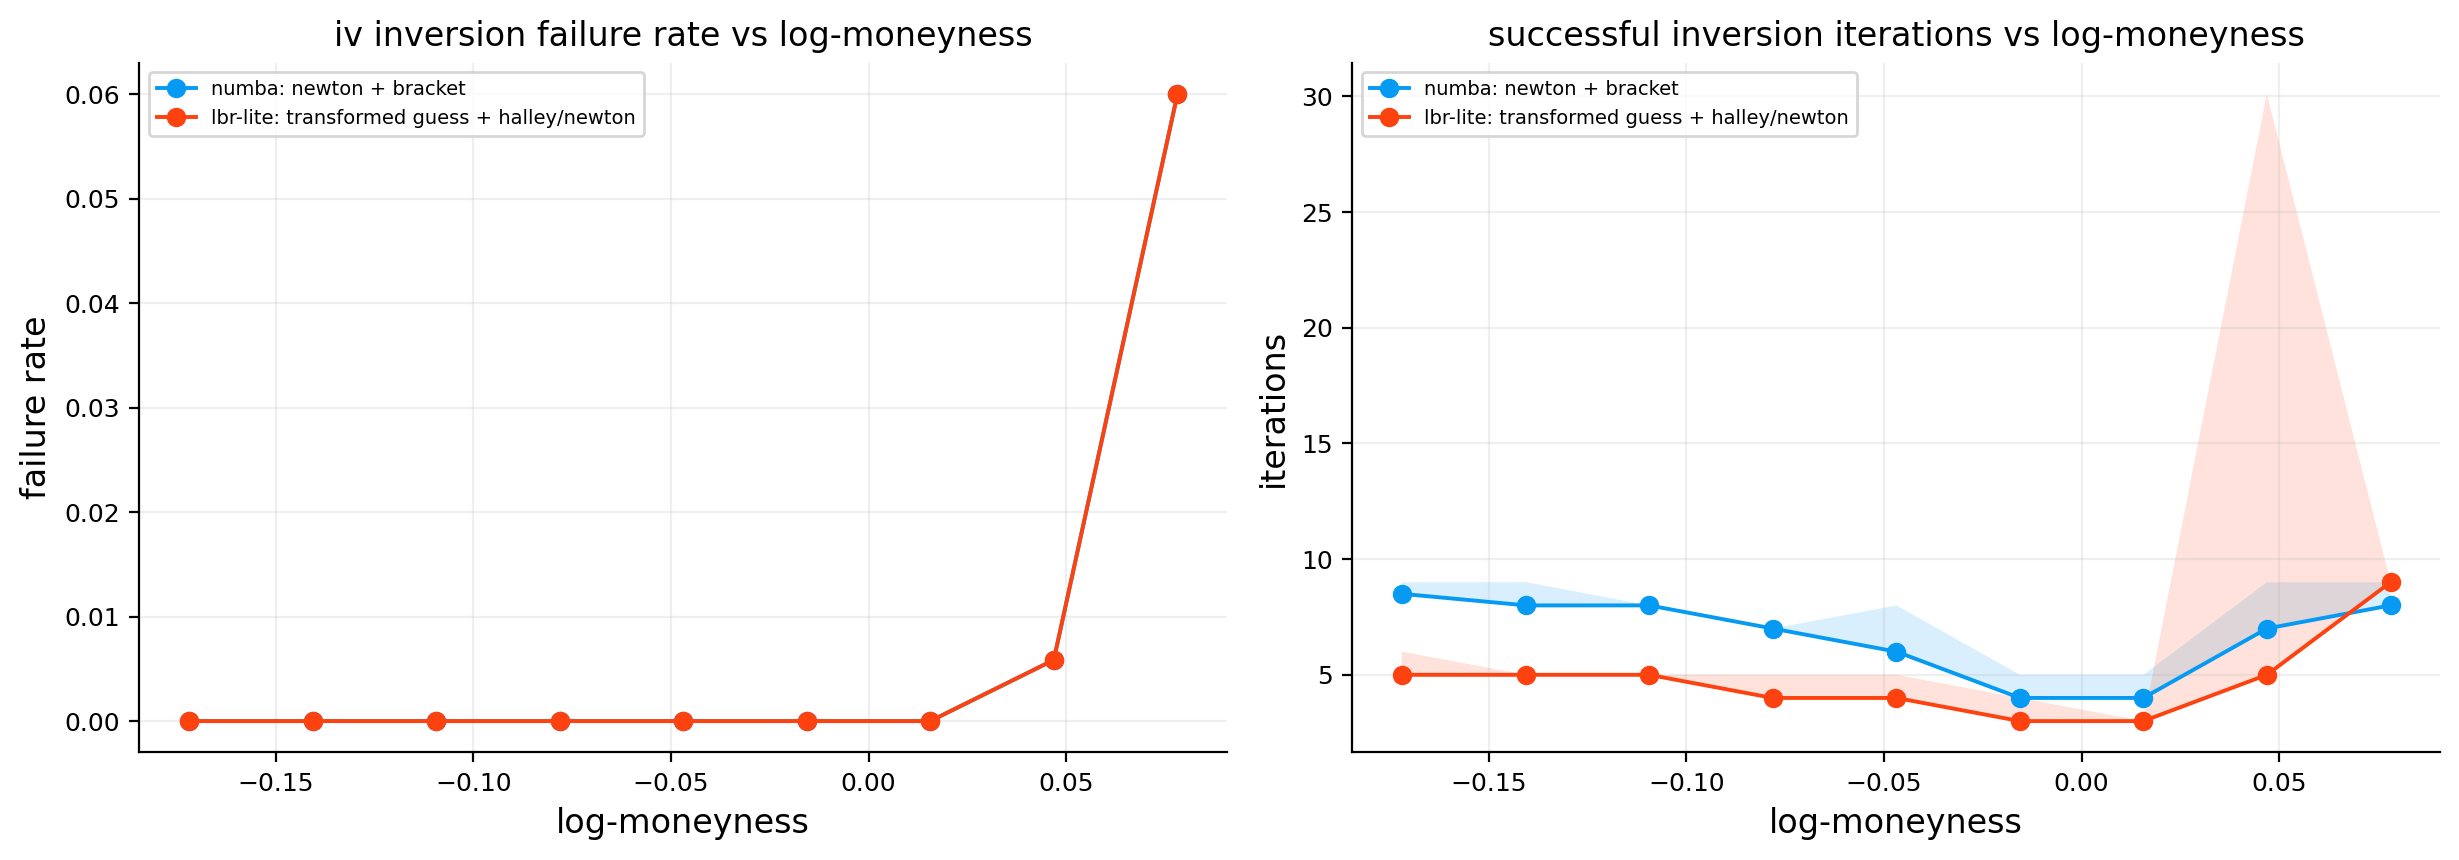

In [13]:
tmp = df_options.copy()
tmp["lm_bin"] = pd.cut(tmp["lm_f"], bins=np.linspace(-0.25, 0.25, 17), include_lowest=True)

fail_rows = []
iter_rows = []

for prefix in ["numba", "lbr_lite"]:
    g_fail = tmp.groupby("lm_bin", observed=False)[f"iv_ok_{prefix}"].agg(["mean", "size"]).reset_index()
    g_fail["fail_rate"] = 1.0 - g_fail["mean"]
    g_fail["lm_mid"] = g_fail["lm_bin"].apply(lambda b: b.mid if pd.notna(b) else np.nan).astype(float)
    g_fail["solver"] = prefix
    fail_rows.append(g_fail[["solver", "lm_mid", "fail_rate", "size"]])

    ok_mask = tmp[f"iv_ok_{prefix}"]
    g_iter = (tmp.loc[ok_mask].groupby("lm_bin", observed=False)[f"iv_mid_iters_{prefix}"]
        .agg(iter_med="median", iter_p90=lambda x: np.nanquantile(x, 0.90), n="size").reset_index())
    
    g_iter["lm_mid"] = g_iter["lm_bin"].apply(lambda b: b.mid if pd.notna(b) else np.nan).astype(float)
    g_iter["solver"] = prefix
    iter_rows.append(g_iter[["solver", "lm_mid", "iter_med", "iter_p90", "n"]])

df_iv_fail_curve = pd.concat(fail_rows, ignore_index=True)
df_iv_iter_curve = pd.concat(iter_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))

for prefix, label in [("numba", "numba: newton + bracket"),
                      ("lbr_lite", "lbr-lite: transformed guess + halley/newton")]:
    g = df_iv_fail_curve[df_iv_fail_curve["solver"] == prefix]
    axes[0].plot(g["lm_mid"], g["fail_rate"], marker="o", lw=1.4, label=label)

    gi = df_iv_iter_curve[df_iv_iter_curve["solver"] == prefix]
    axes[1].plot(gi["lm_mid"], gi["iter_med"], marker="o", lw=1.4, label=label)
    axes[1].fill_between(gi["lm_mid"], gi["iter_med"], gi["iter_p90"], alpha=0.15)

axes[0].set_title("iv inversion failure rate vs log-moneyness")
axes[0].set_xlabel("log-moneyness")
axes[0].set_ylabel("failure rate")
axes[0].legend(loc="best")

axes[1].set_title("successful inversion iterations vs log-moneyness")
axes[1].set_xlabel("log-moneyness")
axes[1].set_ylabel("iterations")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

The plot also shows that for the most moneyness, newton/bisection method almost stayed consistent but LBR-lite model had problems converging and even took maximum of 30 iterations in some cases. but overall for the most part, LBR-lite required less iterations to converge.

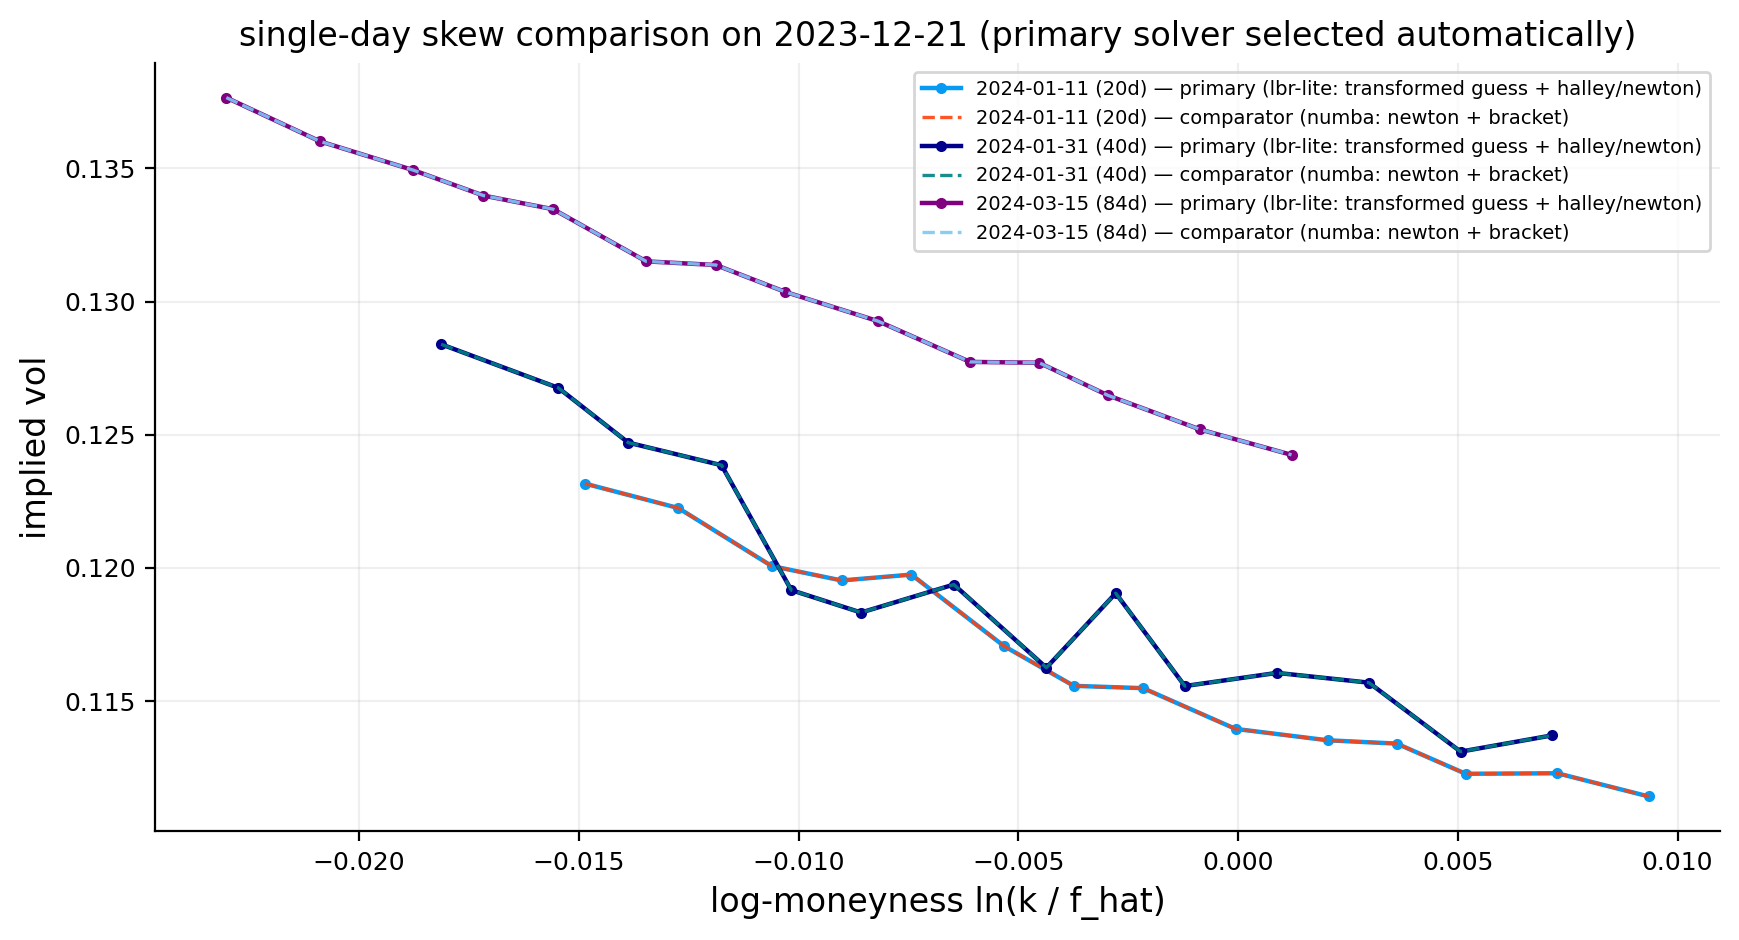

,selected_primary_solver,primary_label,secondary_solver,secondary_label
0,lbr_lite,lbr-lite: transformed guess + halley/newton,numba,numba: newton + bracket


In [14]:
iv_calls_ok = df_options[(df_options["cp"] == "call") & df_options["iv_ok"]].copy()
iv_calls_raw = df_options[df_options["cp"] == "call"].copy()

pool_raw = iv_calls_raw.groupby(["trade_date", "expiry_datetime"]).size().rename("n_raw").reset_index()
pool_ok = iv_calls_ok.groupby(["trade_date", "expiry_datetime"]).size().rename("n_ok").reset_index()
pool = pool_raw.merge(pool_ok, on=["trade_date", "expiry_datetime"], how="left")
pool["n_ok"] = pool["n_ok"].fillna(0)
pool = pool[(pool["n_raw"] >= 8)].copy()

if pool.empty:
    date_ref = pd.Timestamp(iv_calls_raw["trade_date"].dropna().iloc[0]).normalize()
else:
    date_score = pool.groupby("trade_date").agg(n_exp_raw=("expiry_datetime", "nunique"),
        n_exp_ok=("n_ok", lambda x: int(np.sum(np.asarray(x) >= 6))),
        n_pts_ok=("n_ok", "sum")).reset_index()
    
    date_ref = pd.Timestamp(date_score.sort_values(["n_exp_ok", "n_exp_raw", "n_pts_ok"],
                                                   ascending=False).iloc[0]["trade_date"]).normalize()

date_slice = iv_calls_ok[iv_calls_ok["trade_date"] == date_ref].copy()
exp_info = date_slice.groupby("expiry_datetime")["dte_days"].median().reset_index().rename(columns={"dte_days": "dte_med"})
targets = [20.0, 40.0, 80.0]
chosen_exp = []
for t in targets:
    if len(exp_info) == 0:
        continue
    exp_info["dist"] = (exp_info["dte_med"] - t).abs()
    chosen_exp.append(exp_info.sort_values("dist").iloc[0]["expiry_datetime"])
chosen_exp = list(dict.fromkeys(chosen_exp))

solver_label_map = {"numba": "numba: newton + bracket",
                    "lbr_lite": "lbr-lite: transformed guess + halley/newton"}
primary_col = f"iv_mid_{chosen_prefix}"
secondary_col = f"iv_mid_{secondary_prefix}"

fig, ax = plt.subplots(figsize=(8.8, 4.8))
line_count = 0

for exp in chosen_exp[:3]:
    g = date_slice[date_slice["expiry_datetime"] == exp].copy()
    if len(g) < 6:
        continue

    b_primary = binned_summary(g["lm_f"], g[primary_col], bins=14)
    b_secondary = binned_summary(g["lm_f"], g[secondary_col], bins=14)
    if b_primary.empty:
        continue

    tag = f"{pd.Timestamp(exp).date()} ({g['dte_days'].median():.0f}d)"
    ax.plot(b_primary["x_mid"], b_primary["y_med"],
            marker="o", ms=3.0, lw=1.6,
            label=f"{tag} — primary ({solver_label_map[chosen_prefix]})")
    if not b_secondary.empty:
        ax.plot(b_secondary["x_mid"], b_secondary["y_med"],
                lw=1.2, ls="--", alpha=0.90,
                label=f"{tag} — comparator ({solver_label_map[secondary_prefix]})")
    line_count += 1

if line_count == 0:
    fallback = (iv_calls_ok.groupby("expiry_datetime").size()
                .reset_index(name="n").sort_values("n", ascending=False))
    if len(fallback):
        exp = fallback.iloc[0]["expiry_datetime"]
        g = date_slice[date_slice["expiry_datetime"] == exp].copy()
        b_primary = binned_summary(g["lm_f"], g[primary_col], bins=14)
        b_secondary = binned_summary(g["lm_f"], g[secondary_col], bins=14)
        if not b_primary.empty:
            tag = f"{pd.Timestamp(exp).date()} ({g['dte_days'].median():.0f}d)"
            ax.plot(b_primary["x_mid"], b_primary["y_med"], marker="o", ms=3.0, lw=1.6,
                    label=f"{tag} — primary ({solver_label_map[chosen_prefix]})")
            if not b_secondary.empty:
                ax.plot(b_secondary["x_mid"], b_secondary["y_med"],lw=1.2, ls="--", alpha=0.90,
                        label=f"{tag} — comparator ({solver_label_map[secondary_prefix]})")

ax.set_title(f"single-day skew comparison on {date_ref.date()} (primary solver selected automatically)")
ax.set_xlabel("log-moneyness ln(k / f_hat)")
ax.set_ylabel("implied vol")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

selection_note = pd.DataFrame([{"selected_primary_solver": chosen_prefix,
                                "primary_label": solver_label_map[chosen_prefix],
                                "secondary_solver": secondary_prefix,
                                "secondary_label": solver_label_map[secondary_prefix]}])
selection_note

#### Solver Selection and Output

The comparison table is sorted by success rate (descending), then solve time, then iterations, then pricing error. The LBR-lite solver wins on speed and is selected as the primary solver and we are going to keep up with it for the rest of the notebook. but the difference is so small that both models can perform great in all cases.

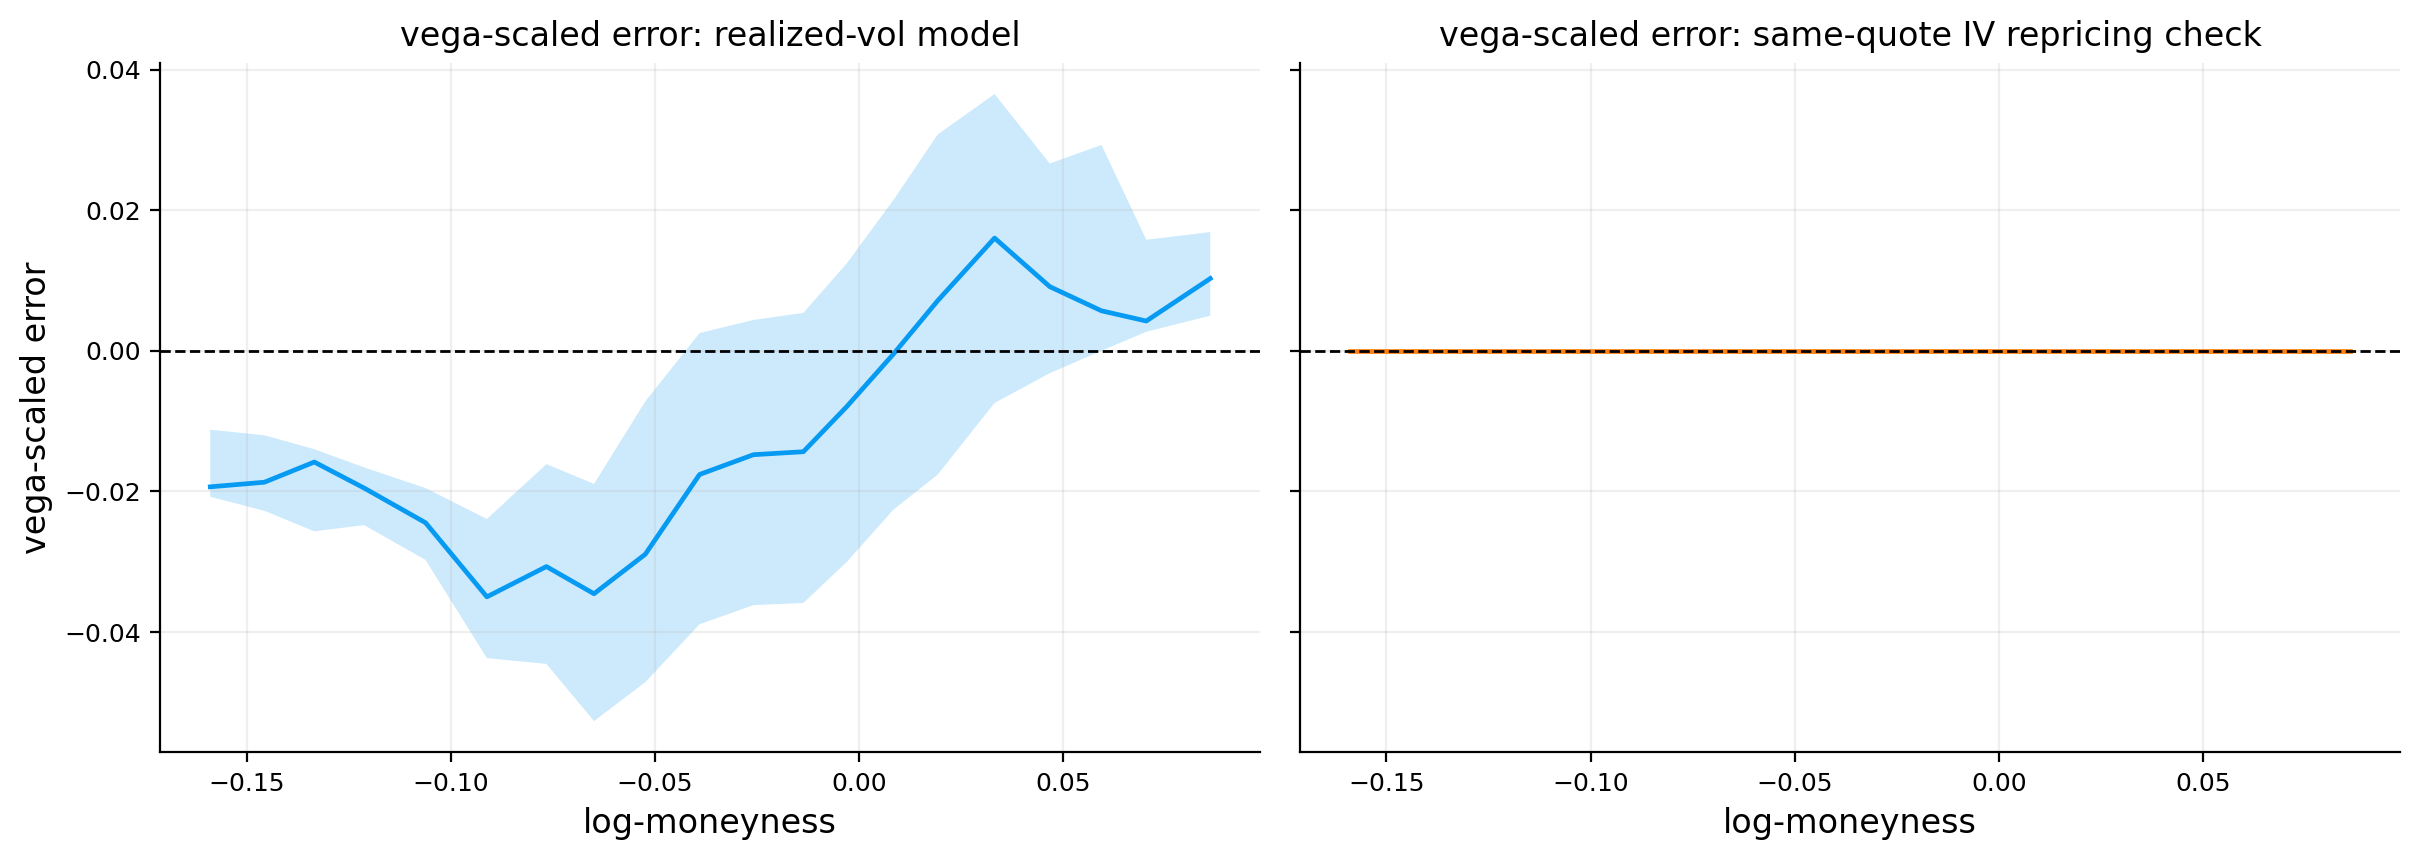

,model,median_abs_error,median_vega_scaled_error,inside_spread_hit_rate
0,realized_vol,9.790763,-0.007782,0.035271
1,same_quote_iv_repricing,0.000000,-0.000000,0.999985


In [15]:
df_options["price_iv"] = bsm_forward_price(
    df_options["cp"].values, df_options["df"].values,
    df_options["f_hat"].values, df_options["strike"].values,
    df_options["tau"].values, np.where(df_options["iv_ok"], df_options["iv_mid"], np.nan))

df_options["vega_iv"] = forward_vega(
    df_options["cp"].values, df_options["df"].values, df_options["f_hat"].values,
    df_options["strike"].values, df_options["tau"].values,
    np.where(df_options["iv_ok"], df_options["iv_mid"], np.nan))

df_options["err_iv"] = df_options["price_iv"] - df_options["mid"]
vega_abs_iv = np.abs(df_options["vega_iv"].to_numpy(dtype=float))
vega_abs_realized = np.abs(df_options["vega_realized"].to_numpy(dtype=float))
vega_union = np.r_[vega_abs_realized, vega_abs_iv]
vega_pos_union = vega_union[np.isfinite(vega_union) & (vega_union > 0)]
vega_floor_common = float(max(1e-6, np.nanpercentile(vega_pos_union, 5) if len(vega_pos_union) else 1e-6))
df_options["vega_scale_iv"] = np.maximum(np.abs(df_options["vega_iv"]), vega_floor_common)
df_options["vega_scaled_err_iv"] = df_options["err_iv"] / df_options["vega_scale_iv"]
df_options["vega_scale_realized"] = np.maximum(np.abs(df_options["vega_realized"]), vega_floor_common)
df_options["vega_scaled_err_realized"] = df_options["err_realized"] / df_options["vega_scale_realized"]
df_options["hit_iv"] = ((df_options["price_iv"] >= df_options["bid"]) & (df_options["price_iv"] <= df_options["ask"])).astype(float)

rv_bin = binned_summary(df_options["lm_f"], df_options["vega_scaled_err_realized"], bins=20)
iv_bin = binned_summary(df_options["lm_f"], df_options["vega_scaled_err_iv"], bins=20)
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4), sharey=True)
axes[0].plot(rv_bin["x_mid"], rv_bin["y_med"], lw=1.7)
axes[0].fill_between(rv_bin["x_mid"], rv_bin["y_q1"], rv_bin["y_q3"], alpha=0.20)
axes[0].axhline(0.0, lw=1.0, c="k", ls="--")
axes[0].set_title("vega-scaled error: realized-vol model")
axes[0].set_xlabel("log-moneyness")
axes[0].set_ylabel("vega-scaled error")
axes[1].plot(iv_bin["x_mid"], iv_bin["y_med"], lw=1.7, c="tab:orange")
axes[1].fill_between(iv_bin["x_mid"], iv_bin["y_q1"], iv_bin["y_q3"], alpha=0.20, color="tab:orange")
axes[1].axhline(0.0, lw=1.0, c="k", ls="--")
axes[1].set_title("vega-scaled error: same-quote IV repricing check")
axes[1].set_xlabel("log-moneyness")
plt.tight_layout()
plt.show()

df_model_compare = pd.DataFrame(
    [{"model": "realized_vol",
    "median_abs_error": float(np.nanmedian(np.abs(df_options["err_realized"]))),
    "median_vega_scaled_error": float(np.nanmedian(df_options["vega_scaled_err_realized"])),
    "inside_spread_hit_rate": float(np.nanmean(df_options["hit_realized"]))},
    {"model": "same_quote_iv_repricing",
    "median_abs_error": float(np.nanmedian(np.abs(df_options["err_iv"]))),
    "median_vega_scaled_error": float(np.nanmedian(df_options["vega_scaled_err_iv"])),
    "inside_spread_hit_rate": float(np.nanmean(df_options["hit_iv"]))}])

df_model_compare

## 9) Greeks computation, Auto Differentiation and analytic approximation


### 9.1 Implied Rate and Dividend Yield

Before computing Greeks in the standard Black-Scholes-Merton (BSM) spot formulation, we need a risk-free rate $r$ and a continuous dividend yield $q$ with a discount factor $D$ and an estimated forward price $\hat{F}$ which we made both earlier in this notebook.

$$r = -\frac{\ln D}{\tau}$$

$$q = r - \frac{1}{\tau}\ln\!\left(\frac{\hat{F}}{S}\right)$$

The logic: $D = e^{-r\tau}$ gives us $r$, and the forward-spot relationship $\hat{F} = S \, e^{(r - q)\tau}$ gives us $q$ by rearranging. These are not true market rates. They are the implied values that make the spot-based BSM formula consistent with the forward-based pricing we've already done. This ensures the Greeks are computed in a framework that exactly reproduces the prices we extracted IV from.

---

### 9.2 The Greeks

The **Greeks** are partial derivatives of the option price with respect to various parameters inside BSM formula. They measure the sensitivity of the option price to changes in market conditions and are essential for risk management.

### 9.2.1 Delta ($\Delta$)

Rate of change of option price with respect to stock price. It shows us how much the price of the option is senstitve to changes in the underlying asset's price.

$$\Delta = \frac{\partial C}{\partial S}$$

Which can be calculated using:

$$\Delta_{\text{call}} = \Phi(d_1) \qquad \Delta_{\text{put}} = \Phi(d_1) - 1 = -\Phi(-d_1)$$


**Properties**:
- Call delta: $0 < \Delta_{\text{call}} < 1$
- Put delta: $-1 < \Delta_{\text{put}} < 0$
- Deep in the money call: $\Delta \approx 1$ (moves almost 1-to-1 with stock)
- Deep out of the money call: $\Delta \approx 0$ (barely moves)
- At-the-money call: $\Delta \approx 0.5$

**Usage**: Delta hedging. To hedge an option position, hold $-\Delta$ shares of stock. If you're long 1 call with $\Delta = 0.6$, short 0.6 shares to hedge. A lot of traders use this type of hedging everyday. They track delta everyday and with changes to their option's delta, they change their position for holding or shorting the underlying asset.

### 9.2.2 Gamma ($\Gamma$)

Rate of change of delta with respect to stock price (second derivative of option price). It shows us how sensitive the option's price is to changes in Delta.

$$\Gamma = \frac{\partial^2 C}{\partial S^2} = \frac{\partial \Delta}{\partial S}$$

**Formula** (same for calls and puts):

$$\Gamma = \frac{\phi(d_1)}{S_0 \sigma \sqrt{T}}$$

**Properties**:
- Always positive for long options
- Highest for at the money options
- Approaches zero for deep in/out of the money options
- Increases as maturity approaches (gamma risk increases near expiration)

**Usage**: Measures how often you need to rebalance your delta hedge. High gamma means delta changes rapidly, requiring frequent rehedging.

### 9.2.3 Vega ($\mathcal{V}$)

Rate of change of option price with respect to volatility. It tells us the sensitivity of option price to changes in volatility.

$$\mathcal{V} = \frac{\partial C}{\partial \sigma}$$

**Formula** (same for calls and puts):

$$\mathcal{V} = S_0 \phi(d_1) \sqrt{T}$$

**Properties**:
- Always positive for long options (higher volatility increases option value)
- Highest for at the money options
- Increases with time to maturity (longer-dated options more sensitive to volatility)

**Usage**: Measures exposure to changes in implied volatility. Critical for volatility trading strategies. We also have already used it as the derivative of BSM $f'(\sigma_n)$ for root finding in both of our IV solvers.

### 9.2.4 Theta ($\Theta$)

Rate of change of option price with respect to time (time decay). It shows sensitivity of option's price to time that we have held the option.

$$\Theta = \frac{\partial C}{\partial t}$$

**Formula**:

$$\Theta_{\text{call}} = -\frac{S_0 \phi(d_1) \sigma}{2\sqrt{T}} - rKe^{-rT}\Phi(d_2) \qquad \Theta_{\text{put}} = -\frac{S_0 \phi(d_1) \sigma}{2\sqrt{T}} + rKe^{-rT}\Phi(-d_2)$$

**Properties**:
- Usually negative for long options (options lose value as time passes)
- Highest (most negative) for at the money options near expiration
- Represents the cost of holding an option

**Usage**: Measures time decay. Option sellers benefit from positive theta (they collect time decay), while buyers suffer from negative theta.

### 9.2.5 Rho ($\rho$)

Rate of change of option price with respect to risk-free rate. It tells us how sensitive the option's price is to changes in risk free rate.

$$\rho = \frac{\partial C}{\partial r}$$

**Formula**:

$$\rho_{\text{call}} = KTe^{-rT}\Phi(d_2) \qquad \rho_{\text{put}} = -KTe^{-rT}\Phi(-d_2)$$


**Properties**:
- Positive for calls (higher rates increase call value)
- Negative for puts (higher rates decrease put value)
- Usually the least important Greek in practice

**Usage**: Measures interest rate risk. More relevant for long-dated options.

 
### 9.2.6 Volga (vega convexity)

sensitivity of vega to volatility. Volga measures how vega itself changes when vol moves.

$$\text{Volga} = \frac{\partial^2 C}{\partial \sigma^2}$$

**Formula:**

$$\text{Volga} = \mathcal{V} \cdot \frac{d_1 \, d_2}{\sigma}$$

It's important for understanding the P&L of volatility-of-volatility exposure. If you're long volga, you benefit from vol moving in either direction.

### 9.2.7 Vanna
cross-sensitivity of delta to volatility. Vanna captures the interaction between spot and vol risk. IT can track the sensitivity of option's value to both Volatility and underlying's price. 

$$\text{Vanna} = \frac{\partial^2 C}{\partial S \partial \sigma} = \frac{\partial \Delta}{\partial \sigma}$$

**Formula:**

$$\text{Vanna} = -e^{-q\tau} \, \phi(d_1) \, \frac{d_2}{\sigma}$$

It matters for skew trading. when the underlying moves, implied vol tends to move too (the leverage effect), and vanna quantifies your exposure to that joint movement.



| Greek | Symbol | Definition | Formula (Call) | Formula (Put) | Range |
|-------|--------|------------|----------------|---------------|-------|
| **Delta** | $\Delta$ | $\frac{\partial C}{\partial S}$ | $\Phi(d_1)$ | $\Phi(d_1) - 1 = -\Phi(-d_1)$ | Call: $(0, 1)$<br>Put: $(-1, 0)$ |
| **Gamma** | $\Gamma$ | $\frac{\partial^2 C}{\partial S^2} = \frac{\partial \Delta}{\partial S}$ | $\frac{\phi(d_1)}{S_0 \sigma \sqrt{T}}$ | $\frac{\phi(d_1)}{S_0 \sigma \sqrt{T}}$ | $(0, \infty)$ |
| **Vega** | $\mathcal{V}$ | $\frac{\partial C}{\partial \sigma}$ | $S_0 \phi(d_1) \sqrt{T}$ | $S_0 \phi(d_1) \sqrt{T}$ | $(0, \infty)$ |
| **Theta** | $\Theta$ | $\frac{\partial C}{\partial t}$ | $-\frac{S_0 \phi(d_1) \sigma}{2\sqrt{T}} - rKe^{-rT}\Phi(d_2)$ | $-\frac{S_0 \phi(d_1) \sigma}{2\sqrt{T}} + rKe^{-rT}\Phi(-d_2)$ | Call: $(-\infty, 0)$<br>Put: $(-\infty, 0)$ typically |
| **Rho** | $\rho$ | $\frac{\partial C}{\partial r}$ | $KT e^{-rT}\Phi(d_2)$ | $-KT e^{-rT}\Phi(-d_2)$ | Call: $(0, \infty)$<br>Put: $(-\infty, 0)$ |
| **Vanna** | $\text{Vanna}$ | $\frac{\partial^2 C}{\partial S \partial \sigma} = \frac{\partial \Delta}{\partial \sigma} = \frac{\partial \mathcal{V}}{\partial S}$ | $-\phi(d_1) \frac{d_2}{\sigma}$ | $-\phi(d_1) \frac{d_2}{\sigma}$ | $(-\infty, \infty)$ |
| **Volga** | $\text{Volga}$ | $\frac{\partial^2 C}{\partial \sigma^2} = \frac{\partial \mathcal{V}}{\partial \sigma}$ | $S_0 \phi(d_1) \sqrt{T} \frac{d_1 d_2}{\sigma}$ | $S_0 \phi(d_1) \sqrt{T} \frac{d_1 d_2}{\sigma}$ | $(-\infty, \infty)$ |

where

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

$$\phi(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2} \quad \text{(standard normal PDF)}$$

$$\Phi(x) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{x} e^{-z^2/2} \, dz \quad \text{(standard normal CDF)}$$


---

### 9.3 Uncertainty Bands via Corner Analysis

Every Greek is a function of two quantities that are themselves uncertain:

1. **Implied volatility**: we know $\sigma_{\text{mid}}$, but the "true" vol could be anywhere in $[\sigma_{\text{bid}}, \sigma_{\text{ask}}]$
2. **Forward price**: the estimated $\hat{F}$ has a confidence range $[\hat{F}_{\text{low}}, \hat{F}_{\text{high}}]$ from the put-call parity estimation

Rather than propagating uncertainty analytically (which would require messy second-order Taylor expansions for each Greek), the code uses a **corner enumeration** approach. It evaluates every Greek at all four combinations of extreme inputs:

| Corner | Volatility | Forward |
|---|---|---|
| 0 | $\sigma_{\text{bid}}$ | $\hat{F}_{\text{low}}$ |
| 1 | $\sigma_{\text{bid}}$ | $\hat{F}_{\text{high}}$ |
| 2 | $\sigma_{\text{ask}}$ | $\hat{F}_{\text{low}}$ |
| 3 | $\sigma_{\text{ask}}$ | $\hat{F}_{\text{high}}$ |

For each Greek, the band is then:

$$G_{\text{low}} = \min_{j \in \{0,1,2,3\}} G^{(j)}, \qquad G_{\text{high}} = \max_{j \in \{0,1,2,3\}} G^{(j)}$$

$$\text{band} = G_{\text{high}} - G_{\text{low}}$$

This tells us given the uncertainty in vol and forward, the true delta could be anywhere in this range. A wide band means the Greek is poorly determined and hedging would be dificault and not trustworthy because we don't know the Greek precisely.

In [16]:
def implied_rate_dividend(spot, df, fwd, tau):
    tau = np.clip(np.asarray(tau, dtype=float), 1e-12, None)
    spot = np.clip(np.asarray(spot, dtype=float), 1e-12, None)
    df = np.clip(np.asarray(df, dtype=float), 1e-12, None)
    fwd = np.clip(np.asarray(fwd, dtype=float), 1e-12, None)
    rate = -np.log(df) / tau
    div = rate - np.log(fwd / spot) / tau
    carry_disc = np.exp(-div * tau)
    return rate, div, carry_disc


def bsm_spot_price_div(cp, spot, strike, tau, rate, div, sigma):
    tau = np.clip(np.asarray(tau, dtype=float), 1e-12, None)
    sigma = np.clip(np.asarray(sigma, dtype=float), 1e-8, None)
    spot = np.asarray(spot, dtype=float)
    strike = np.asarray(strike, dtype=float)
    rate = np.asarray(rate, dtype=float)
    div = np.asarray(div, dtype=float)
    sqrt_tau = np.sqrt(tau)
    disc_r = np.exp(-rate * tau)
    disc_q = np.exp(-div * tau)
    d1 = (np.log(np.clip(spot, 1e-12, None) / np.clip(strike, 1e-12, None)) 
          + (rate - div + 0.5 * sigma * sigma) * tau) / (sigma * sqrt_tau)
    d2 = d1 - sigma * sqrt_tau
    is_call = cp_is_call(cp)
    call_val = disc_q * spot * norm.cdf(d1) - disc_r * strike * norm.cdf(d2)
    put_val = disc_r * strike * norm.cdf(-d2) - disc_q * spot * norm.cdf(-d1)
    return np.where(is_call, call_val, put_val)


def bsm_spot_greeks(cp, spot, strike, tau, rate, div, sigma, fwd=None, df=None):
    tau = np.clip(np.asarray(tau, dtype=float), 1e-12, None)
    sigma = np.clip(np.asarray(sigma, dtype=float), 1e-8, None)
    spot = np.asarray(spot, dtype=float)
    strike = np.asarray(strike, dtype=float)
    rate = np.asarray(rate, dtype=float)
    div = np.asarray(div, dtype=float)

    sqrt_tau = np.sqrt(tau)
    disc_r = np.exp(-rate * tau)
    disc_q = np.exp(-div * tau)
    d1 = (np.log(np.clip(spot, 1e-12, None) / np.clip(strike, 1e-12, None)) 
          + (rate - div + 0.5 * sigma * sigma) * tau) / (sigma * sqrt_tau)
    d2 = d1 - sigma * sqrt_tau
    pdf = norm.pdf(d1)
    is_call = cp_is_call(cp)

    delta_call = disc_q * norm.cdf(d1)
    delta_put = disc_q * (norm.cdf(d1) - 1.0)
    delta_spot = np.where(is_call, delta_call, delta_put)
    gamma_spot = disc_q * pdf / (np.clip(spot, 1e-12, None) * sigma * sqrt_tau)
    vega = spot * disc_q * pdf * sqrt_tau
    volga = vega * (d1 * d2) / sigma
    vanna = -disc_q * pdf * d2 / sigma

    theta_call = (
        -(spot * disc_q * pdf * sigma) / (2.0 * sqrt_tau)
        - rate * strike * disc_r * norm.cdf(d2)
        + div * spot * disc_q * norm.cdf(d1))
    theta_put = (
        -(spot * disc_q * pdf * sigma) / (2.0 * sqrt_tau)
        + rate * strike * disc_r * norm.cdf(-d2)
        - div * spot * disc_q * norm.cdf(-d1))

    theta = np.where(is_call, theta_call, theta_put)

    rho_call = strike * tau * disc_r * norm.cdf(d2)
    rho_put = -strike * tau * disc_r * norm.cdf(-d2)
    rho = np.where(is_call, rho_call, rho_put)

    out = {"delta_spot": delta_spot, "gamma_spot": gamma_spot,
        "vega": vega, "volga": volga, "vanna": vanna, "theta": theta,
        "rho": rho, "d1": d1, "d2": d2,}

    if (fwd is not None) and (df is not None):
        fwd = np.asarray(fwd, dtype=float)
        df = np.asarray(df, dtype=float)
        delta_fwd_call = df * norm.cdf(d1)
        delta_fwd_put = -df * norm.cdf(-d1)
        out["delta_fwd"] = np.where(is_call, delta_fwd_call, delta_fwd_put)
        out["gamma_fwd"] = df * pdf / (np.clip(fwd, 1e-12, None) * sigma * sqrt_tau)

    return out


mid_sigma = np.where(df_options["iv_ok"], df_options["iv_mid"], np.nan)
rate_imp, div_imp, carry_disc = implied_rate_dividend(
    df_options["s"].values, df_options["df"].values,
    df_options["f_hat"].values, df_options["tau"].values)

df_options["rate_imp"] = rate_imp
df_options["div_imp"] = div_imp
df_options["carry_disc"] = carry_disc

mid_g = bsm_spot_greeks(
    df_options["cp"].values, df_options["s"].values,
    df_options["strike"].values, df_options["tau"].values,
    df_options["rate_imp"].values, df_options["div_imp"].values,
    mid_sigma, fwd=df_options["f_hat"].values, df=df_options["df"].values)

for key, val in mid_g.items():
    df_options[f"{key}_mid"] = val

sigma_low = df_options["iv_bid_fill"].where(np.isfinite(df_options["iv_bid_fill"]), df_options["iv_mid"]).to_numpy(dtype=float)
sigma_high = df_options["iv_ask_fill"].where(np.isfinite(df_options["iv_ask_fill"]), df_options["iv_mid"]).to_numpy(dtype=float)
f_low = np.minimum(df_options["f_low_ref"].to_numpy(dtype=float), df_options["f_high_ref"].to_numpy(dtype=float))
f_high = np.maximum(df_options["f_low_ref"].to_numpy(dtype=float), df_options["f_high_ref"].to_numpy(dtype=float))
f_low = np.where(np.isfinite(f_low) & (f_low > 0), f_low, df_options["f_hat"].to_numpy(dtype=float))
f_high = np.where(np.isfinite(f_high) & (f_high > 0), f_high, df_options["f_hat"].to_numpy(dtype=float))

corner_inputs = [(sigma_low, f_low), (sigma_low, f_high),
                  (sigma_high, f_low), (sigma_high, f_high)]
corner_store = {}
for j, (sigma_j, fwd_j) in enumerate(corner_inputs):
    rate_j, div_j, _ = implied_rate_dividend(df_options["s"].values, df_options["df"].values,
                                             fwd_j, df_options["tau"].values)
    corner_store[j] = bsm_spot_greeks(df_options["cp"].values, df_options["s"].values,
                                      df_options["strike"].values, df_options["tau"].values,
                                      rate_j, div_j, sigma_j, fwd=fwd_j, df=df_options["df"].values)

greek_names = ["delta_fwd", "gamma_fwd", "delta_spot", "gamma_spot", "vega", "volga", "vanna", "rho", "theta"]
for gname in greek_names:
    arrs = [np.asarray(corner_store[j][gname], dtype=float) for j in range(len(corner_store))]
    stack = np.vstack(arrs)
    df_options[f"{gname}_low"] = np.nanmin(stack, axis=0)
    df_options[f"{gname}_high"] = np.nanmax(stack, axis=0)
    df_options[f"{gname}_band"] = df_options[f"{gname}_high"] - df_options[f"{gname}_low"]


### 9.4 Automatic Differentiation with JAX

AS we saw, every Greek is a derivative of the option pricing function. The standard approach is to derive these formulas by hand using calculus, then implement them in code.

This works, but it's fragile. The Black-Scholes formula involves logarithms, exponentials, normal CDFs, and products of multiple terms. Taking derivatives requires careful application of the chain rule, product rule, and quotient rule. A single sign error, a missing factor of $e^{-q\tau}$, or an incorrect simplification can produce a Greek formula that looks reasonable but is subtly wrong.

Automatic differentiation (autodiff) solves this by computing derivatives mechanically, without requiring you to derive or implement the derivative formulas at all. You write the pricing function once, and the autodiff system computes exact derivatives by applying the chain rule automatically to the function's computational graph.

1. **Forward pass:** Evaluate the function normally to compute the output (the option price $C$)
2. **Reverse pass:** Walk backward through the computational graph, applying the chain rule at each operation to accumulate the derivative

This is called **reverse-mode autodiff** (or backpropagation in the neural network literature). It computes the gradient of a scalar output with respect to all inputs in a single backward pass, making it extremely efficient for functions with many inputs and one output. Exactly the structure of option pricing.

**The Reverse Pass:**

To compute $\frac{\partial C}{\partial S}$ (delta), autodiff starts at the output node with $\frac{\partial C}{\partial C} = 1$ and walks backward through the graph, applying the chain rule at each operation.

For example, the final operation is a subtraction: $C = A - B$ where $A = S e^{-q\tau} \Phi(d_1)$ and $B = K e^{-r\tau} \Phi(d_2)$. The chain rule says:

$$\frac{\partial C}{\partial S} = \frac{\partial C}{\partial A} \cdot \frac{\partial A}{\partial S} + \frac{\partial C}{\partial B} \cdot \frac{\partial B}{\partial S}$$

We know $\frac{\partial C}{\partial A} = 1$ and $\frac{\partial C}{\partial B} = -1$ (derivative of subtraction). Now we need $\frac{\partial A}{\partial S}$ and $\frac{\partial B}{\partial S}$.

For $A = S e^{-q\tau} \Phi(d_1)$, this is a product, so:

We keep applying the chain rule and accumulate all the derivatives until we get to a chain of partial derivatives which is equal to the $\frac{\partial C}{\partial S}$.

The autodiff system does all of this automatically. It walks backward through every node, accumulating gradients using the chain rule, until it reaches the input nodes. At that point, it has computed all the first-order Greeks at the same time.

Also for second derivatives like gamma or vanna, you simply differentiate the first derivative function.

The autodiff Greeks are computed through a completely independent code path. They don't use any of the manually derived formulas. If your analytic delta formula has a bug, the autodiff delta will be correct, and the discrepancy will show up immediately when you compare them. Also with more factors that we have and more exposures we want to calculate for a model, autodiff is much faster. it calcuulates sensitivities to all the parameters at the same time.

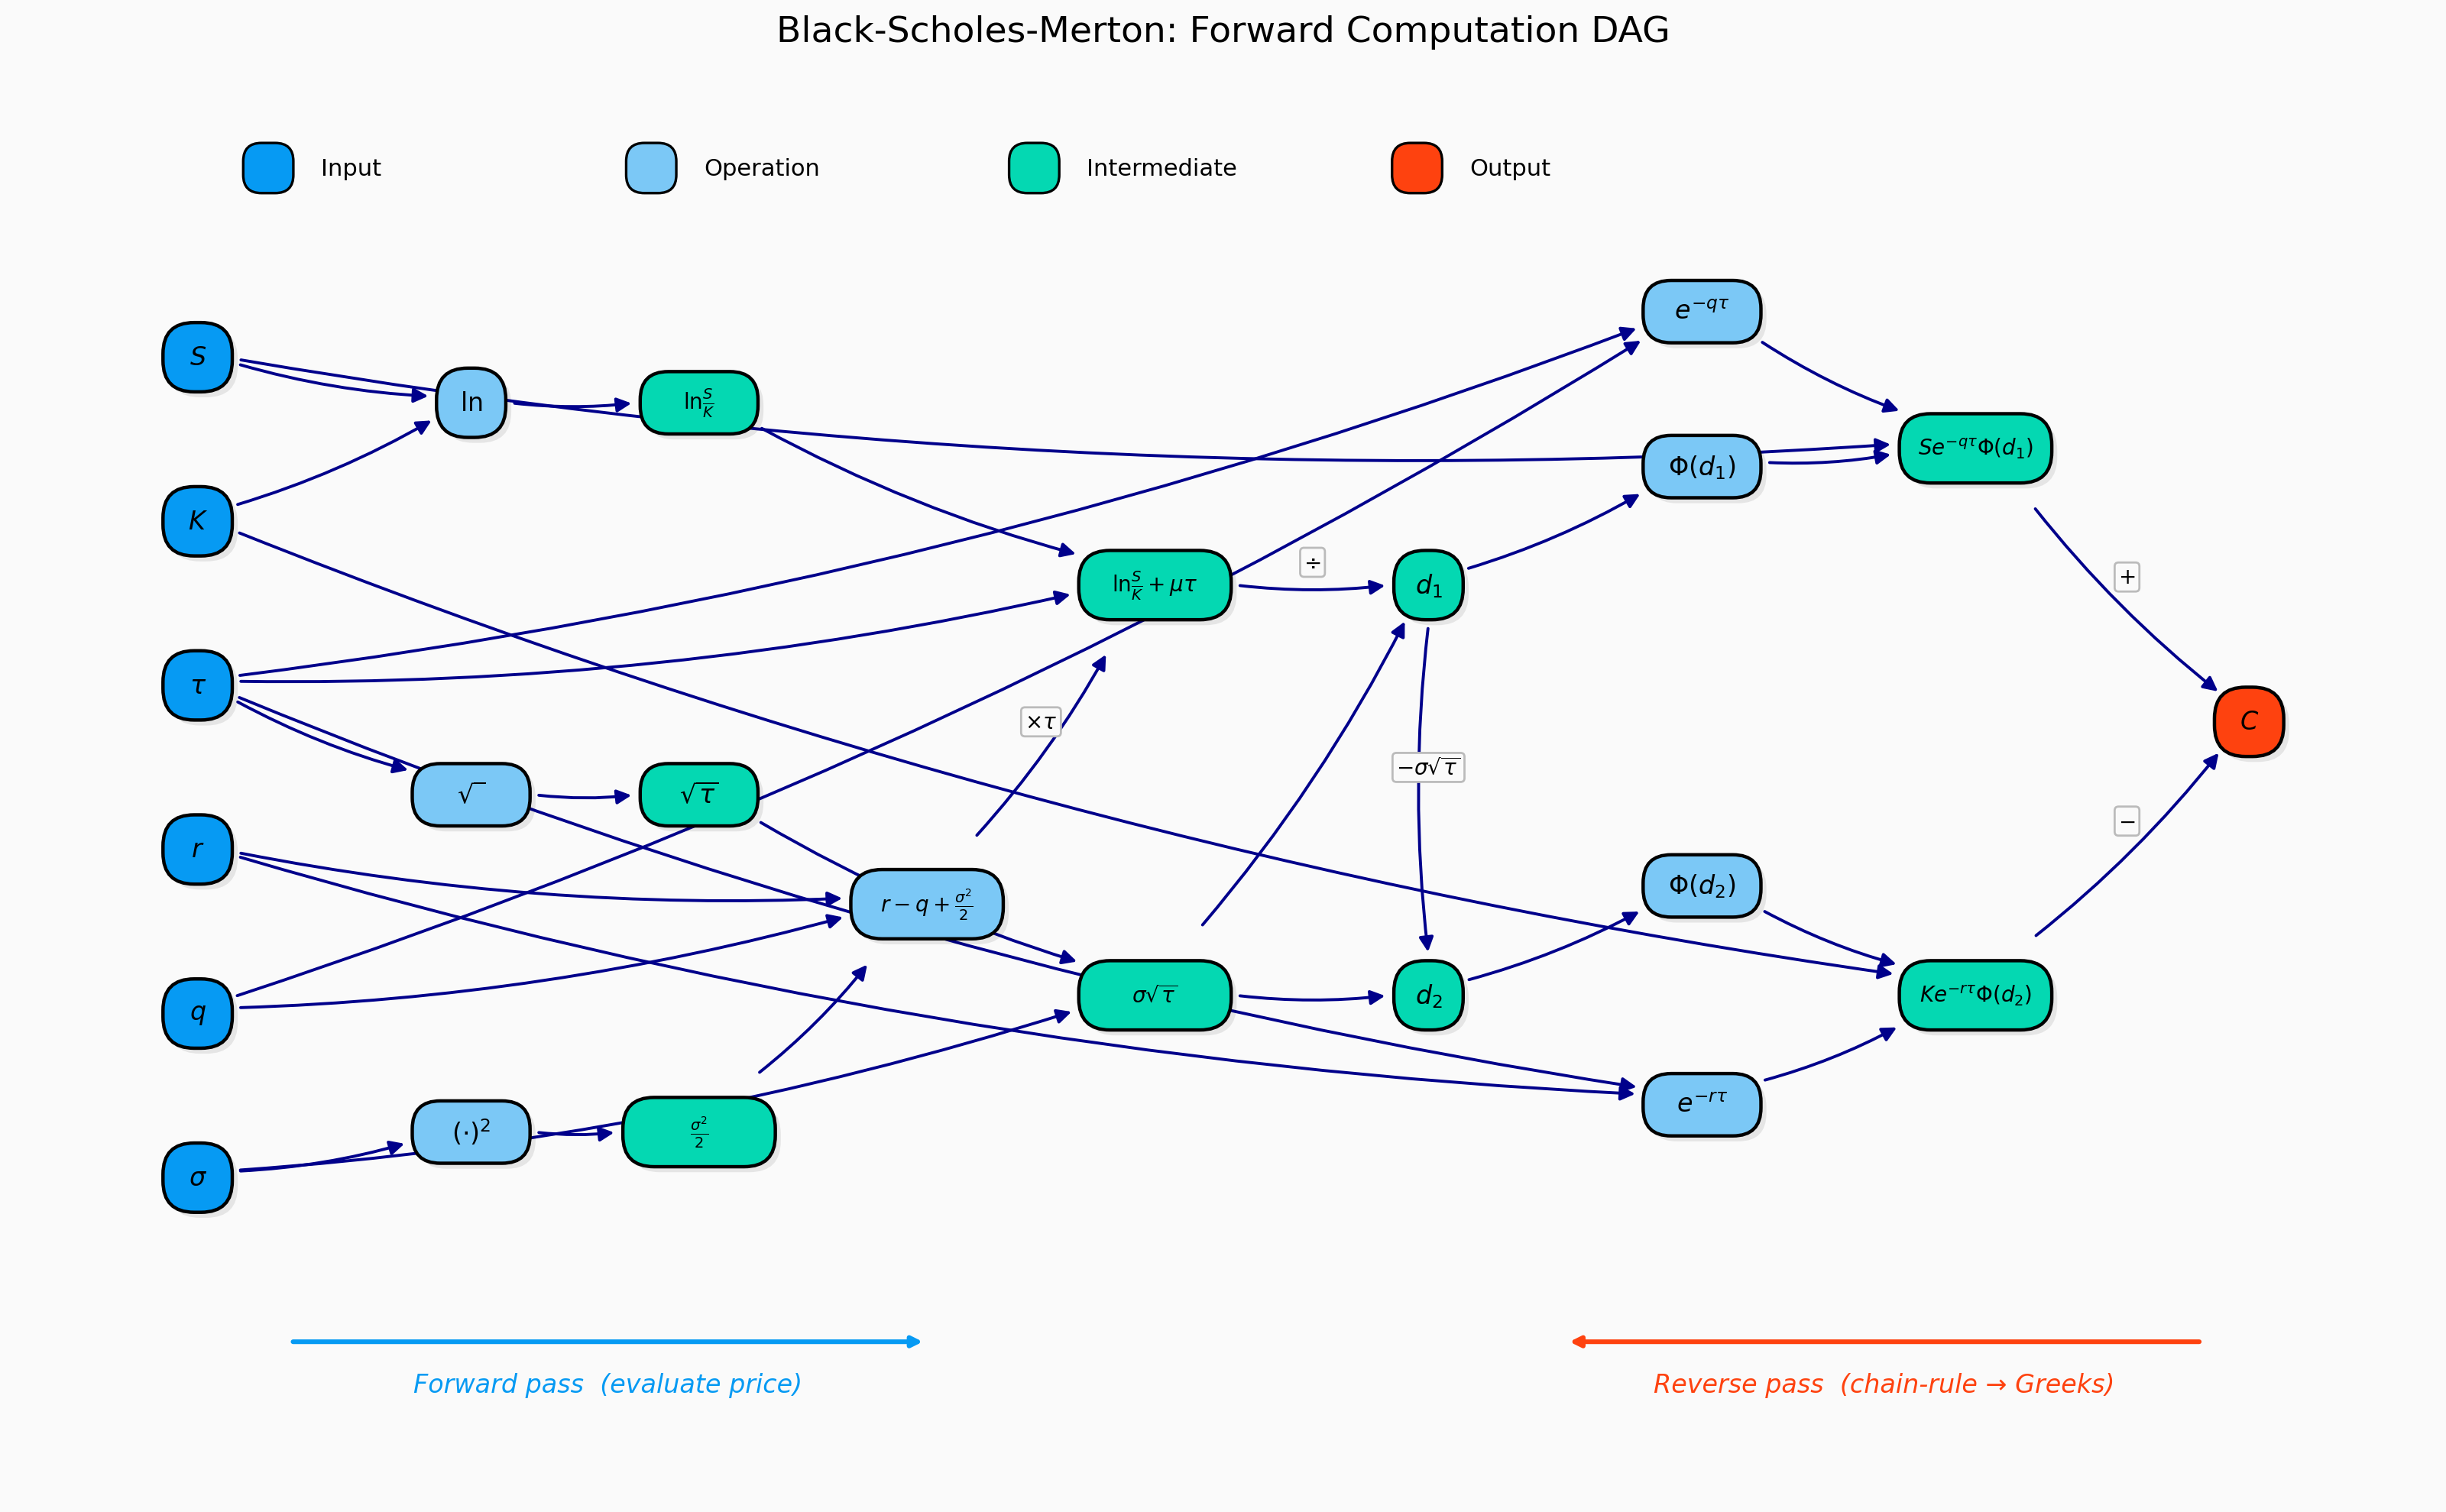

In [17]:
import quantfinlab.plots as pl
fig, ax = pl.plot_bsm_comp_graph(title="Black-Scholes-Merton: Forward Computation DAG", figsize=(20, 10))


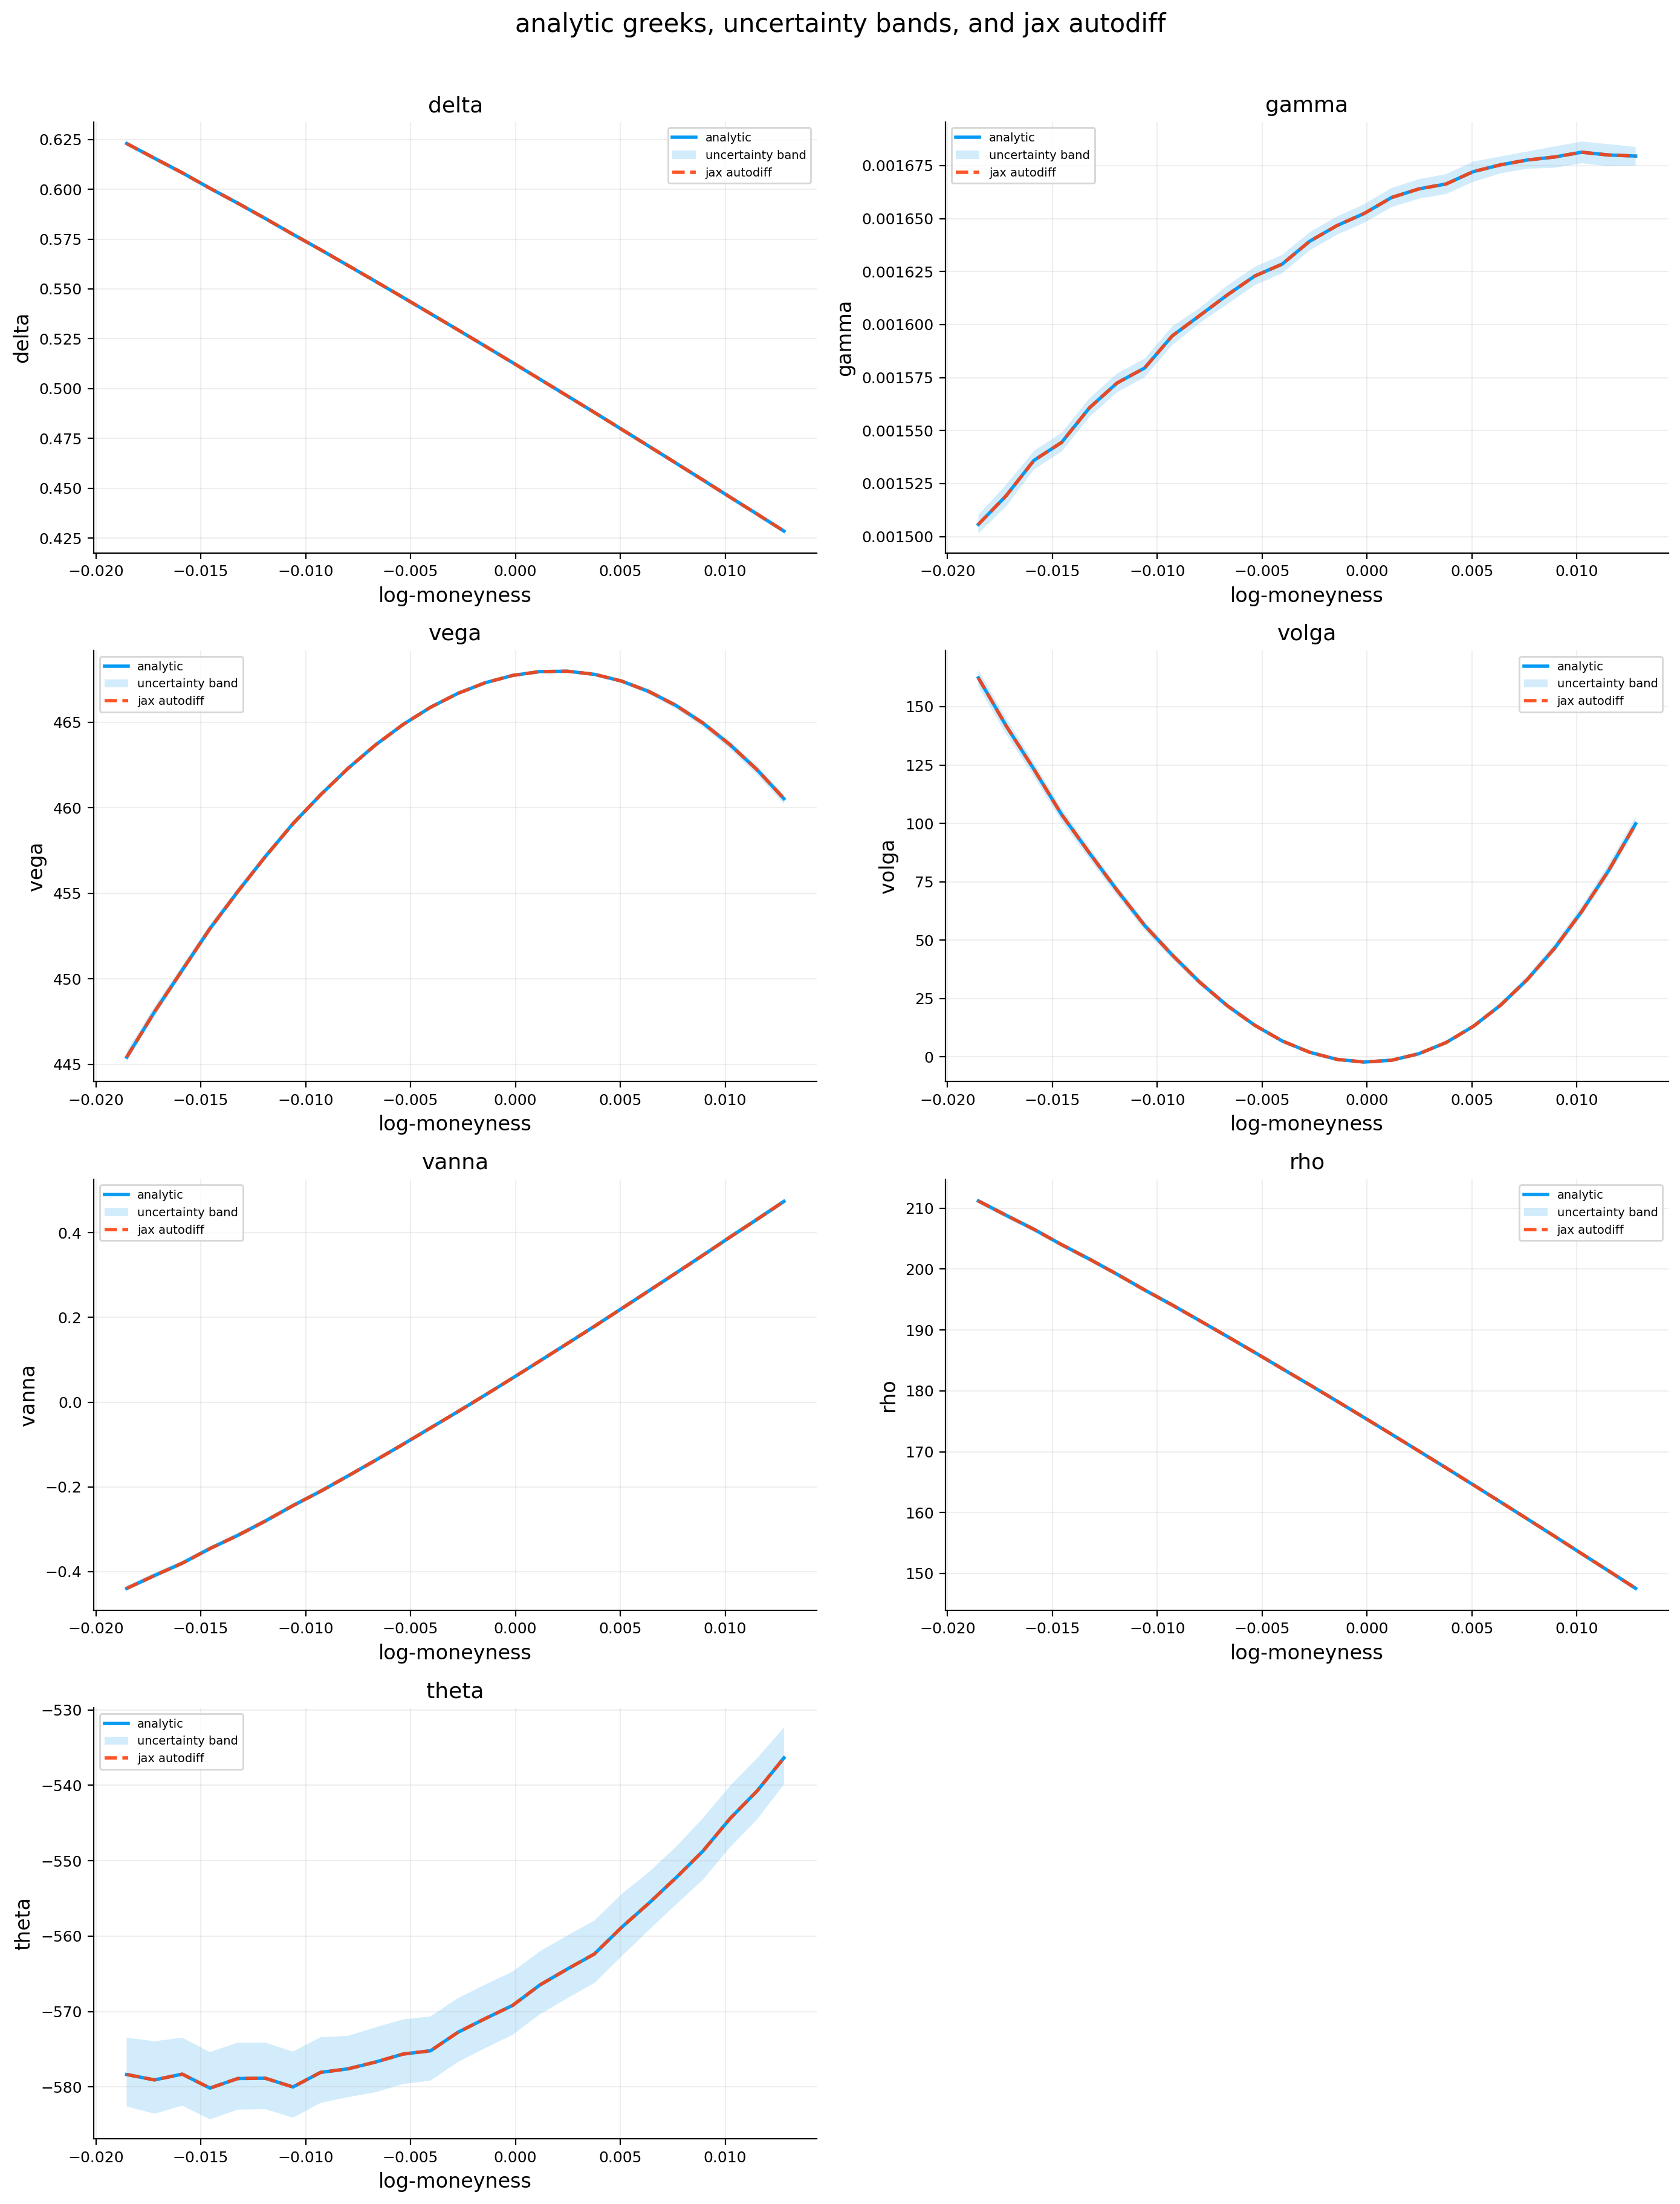

,greek,median_band,p90_band,median_relative_band_pct,jax_mae
0,delta,0.002033,0.002222,0.349393,0.000000
1,gamma,0.000009,0.000010,0.553225,0.000000
2,vega,0.283466,0.546604,0.060725,0.000059
3,volga,2.876492,5.748516,7.785957,0.000493
4,vanna,0.010229,0.011630,4.301923,0.000002
5,rho,0.684059,0.749901,0.364283,0.000130
6,theta,8.428743,8.971673,1.487109,0.000084


In [18]:
fan_slice = df_options[
    (df_options["trade_date"] == walk_trade_date)
    & (df_options["expiry_datetime"] == walk_expiry)
    & (df_options["cp"] == "call")
    & df_options["iv_ok"]
].copy()

if len(fan_slice) < 10:
    dense = (df_options[(df_options["cp"] == "call") & df_options["iv_ok"]].groupby(["trade_date", "expiry_datetime"])
        .size().rename("n").reset_index().sort_values("n", ascending=False))
    if len(dense):
        best = dense.iloc[0]
        fan_slice = df_options[(df_options["trade_date"] == best["trade_date"])
                               & (df_options["expiry_datetime"] == best["expiry_datetime"])
                               & (df_options["cp"] == "call")& df_options["iv_ok"]].copy()

fan_slice = fan_slice.sort_values("lm_f").copy()

sqrt2 = np.sqrt(2.0)

def norm_cdf_jax(x):
    return 0.5 * (1.0 + jax.lax.erf(x / sqrt2))

def call_price_jax_spot(spot, strike, tau, rate, div, sigma):
    tau = jnp.maximum(tau, 1e-12)
    sigma = jnp.maximum(sigma, 1e-8)
    sqrt_tau = jnp.sqrt(tau)
    disc_r = jnp.exp(-rate * tau)
    disc_q = jnp.exp(-div * tau)
    d1 = (jnp.log(spot / strike) + (rate - div + 0.5 * sigma**2) * tau) / (sigma * sqrt_tau)
    d2 = d1 - sigma * sqrt_tau
    return disc_q * spot * norm_cdf_jax(d1) - disc_r * strike * norm_cdf_jax(d2)

if len(fan_slice):
    spot_j = jnp.array(fan_slice["s"].to_numpy(dtype=float))
    strike_j = jnp.array(fan_slice["strike"].to_numpy(dtype=float))
    tau_j = jnp.array(fan_slice["tau"].to_numpy(dtype=float))
    rate_j = jnp.array(fan_slice["rate_imp"].to_numpy(dtype=float))
    div_j = jnp.array(fan_slice["div_imp"].to_numpy(dtype=float))
    sigma_j = jnp.array(fan_slice["iv_mid"].to_numpy(dtype=float))

    delta_jax_fn = grad(call_price_jax_spot, argnums=0)
    vega_jax_fn = grad(call_price_jax_spot, argnums=5)
    rho_jax_fn = grad(call_price_jax_spot, argnums=3)
    theta_jax_fn = lambda S, K, t, r, q, sig: -grad(call_price_jax_spot, argnums=2)(S, K, t, r, q, sig)
    gamma_jax_fn = grad(delta_jax_fn, argnums=0)
    volga_jax_fn = grad(vega_jax_fn, argnums=5)
    vanna_jax_fn = grad(delta_jax_fn, argnums=5)

    fan_slice["delta_spot_jax"] = np.asarray(vmap(delta_jax_fn)(spot_j, strike_j, tau_j, rate_j, div_j, sigma_j))
    fan_slice["gamma_spot_jax"] = np.asarray(vmap(gamma_jax_fn)(spot_j, strike_j, tau_j, rate_j, div_j, sigma_j))
    fan_slice["vega_jax"] = np.asarray(vmap(vega_jax_fn)(spot_j, strike_j, tau_j, rate_j, div_j, sigma_j))
    fan_slice["volga_jax"] = np.asarray(vmap(volga_jax_fn)(spot_j, strike_j, tau_j, rate_j, div_j, sigma_j))
    fan_slice["vanna_jax"] = np.asarray(vmap(vanna_jax_fn)(spot_j, strike_j, tau_j, rate_j, div_j, sigma_j))
    fan_slice["rho_jax"] = np.asarray(vmap(rho_jax_fn)(spot_j, strike_j, tau_j, rate_j, div_j, sigma_j))
    fan_slice["theta_jax"] = np.asarray(vmap(theta_jax_fn)(spot_j, strike_j, tau_j, rate_j, div_j, sigma_j))
else:
    fan_slice = fan_slice.copy()
    for c in ["delta_spot_jax", "gamma_spot_jax", "vega_jax",
              "volga_jax", "vanna_jax", "rho_jax", "theta_jax"]:
        fan_slice[c] = np.nan

greek_specs = [("delta_spot", "delta_spot_jax", "delta"),
               ("gamma_spot", "gamma_spot_jax", "gamma"),
               ("vega", "vega_jax", "vega"),
               ("volga", "volga_jax", "volga"),
               ("vanna", "vanna_jax", "vanna"),
               ("rho", "rho_jax", "rho"),("theta", "theta_jax", "theta")]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes_flat = axes.ravel()

for idx, (base_name, jax_name, label) in enumerate(greek_specs):
    ax = axes_flat[idx]
    ax.plot(fan_slice["lm_f"], fan_slice[f"{base_name}_mid"], lw=2.0, label="analytic")
    ax.fill_between(fan_slice["lm_f"], fan_slice[f"{base_name}_low"],
                    fan_slice[f"{base_name}_high"], alpha=0.18, label="uncertainty band")
    ax.plot(fan_slice["lm_f"], fan_slice[jax_name], lw=2.0, ls="--", alpha=0.90, label="jax autodiff")
    ax.set_title(label, fontsize=13)
    ax.set_xlabel("log-moneyness")
    ax.set_ylabel(label)
    ax.legend(loc="best")

axes_flat[-1].set_visible(False)
fig.suptitle("analytic greeks, uncertainty bands, and jax autodiff", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

band_rows = []
for base_name, jax_name, label in greek_specs:
    band_vals = fan_slice[f"{base_name}_band"].to_numpy(dtype=float)
    mid_vals = np.abs(fan_slice[f"{base_name}_mid"].to_numpy(dtype=float))
    ana_vals = fan_slice[f"{base_name}_mid"].to_numpy(dtype=float)
    jax_vals = fan_slice[jax_name].to_numpy(dtype=float)
    mask = np.isfinite(ana_vals) & np.isfinite(jax_vals)
    mae = float(np.nanmean(np.abs(ana_vals[mask] - jax_vals[mask]))) if mask.any() else np.nan

    band_rows.append(
        {"greek": label,
        "median_band": float(np.nanmedian(band_vals)),
        "p90_band": float(np.nanquantile(band_vals, 0.90)),
        "median_relative_band_pct": float(100.0 * np.nanmedian(band_vals / np.maximum(mid_vals, 1e-12))),
        "jax_mae": mae})

df_greek_band_summary = pd.DataFrame(band_rows)
df_greek_band_summary


All Greeks show near-zero error against autodiff except theta. Delta and gamma are exact to machine precision, while the others have errors in the range of $10^{-4}$ to $10^{-7}$. This confirms the analytic formulas are correctly implemented. The tiny non-zero errors for vega, volga, vanna, rho, and theta are maybe due to numerical precision in the normal CDF/PDF evaluations.

**Uncertainty quantification (relative band column):**

For Vanna The cross sensitivity between spot and vol has around 4% uncertainty. This matters for skew trading strategies where you're exposed to the correlation between spot moves and vol moves.

Volga has around 8% uncertainty. This is the least precise Greek in the table. Volga matters for volatility of volatility exposure. if we're trading variance swaps or vol of vol products, this uncertainty is significant. For vanilla option hedging, it's less critical.

In [19]:
greek_map = [
    ("delta_spot_mid", "delta_spot_jax", r"delta"),
    ("gamma_spot_mid", "gamma_spot_jax", r"gamma"),
    ("vega_mid", "vega_jax", r"vega"),
    ("volga_mid", "volga_jax", r"volga"),
    ("vanna_mid", "vanna_jax", r"vanna"),
    ("rho_mid", "rho_jax", r"rho"),
    ("theta_mid", "theta_jax", r"theta"),
]

mae_rows = []
for col_ana, col_jax, label in greek_map:
    ana_vals = fan_slice[col_ana].to_numpy(dtype=float)
    jax_vals = fan_slice[col_jax].to_numpy(dtype=float)
    mask = np.isfinite(ana_vals) & np.isfinite(jax_vals)
    if mask.sum() > 0:
        mae = np.mean(np.abs(ana_vals[mask] - jax_vals[mask]))
        maxe = np.max(np.abs(ana_vals[mask] - jax_vals[mask]))
        mean_abs = np.mean(np.abs(ana_vals[mask]))
        rel_pct = (mae / mean_abs * 100.0) if mean_abs > 1e-15 else 0.0
    else:
        mae = maxe = rel_pct = np.nan

    mae_rows.append(
        {
            "Greek": label,
            "MAE": mae,
            "Max Abs Error": maxe,
            "Rel MAE (%)": rel_pct,
            "N": int(mask.sum()),
        }
    )

mae_df = pd.DataFrame(mae_rows)
mae_df

,Greek,MAE,Max Abs Error,Rel MAE (%),N
0,delta,0.000000,0.000001,0.000064,25
1,gamma,0.000000,0.000000,0.000020,25
2,vega,0.000059,0.000159,0.000013,25
3,volga,0.000493,0.001776,0.000997,25
4,vanna,0.000002,0.000005,0.000695,25
5,rho,0.000130,0.000374,0.000072,25
6,theta,0.000084,0.000268,0.000015,25


## 10) Dispersion Over Time

We computed and talked about dispersion earlier in this notebook. Now we analyze it through time



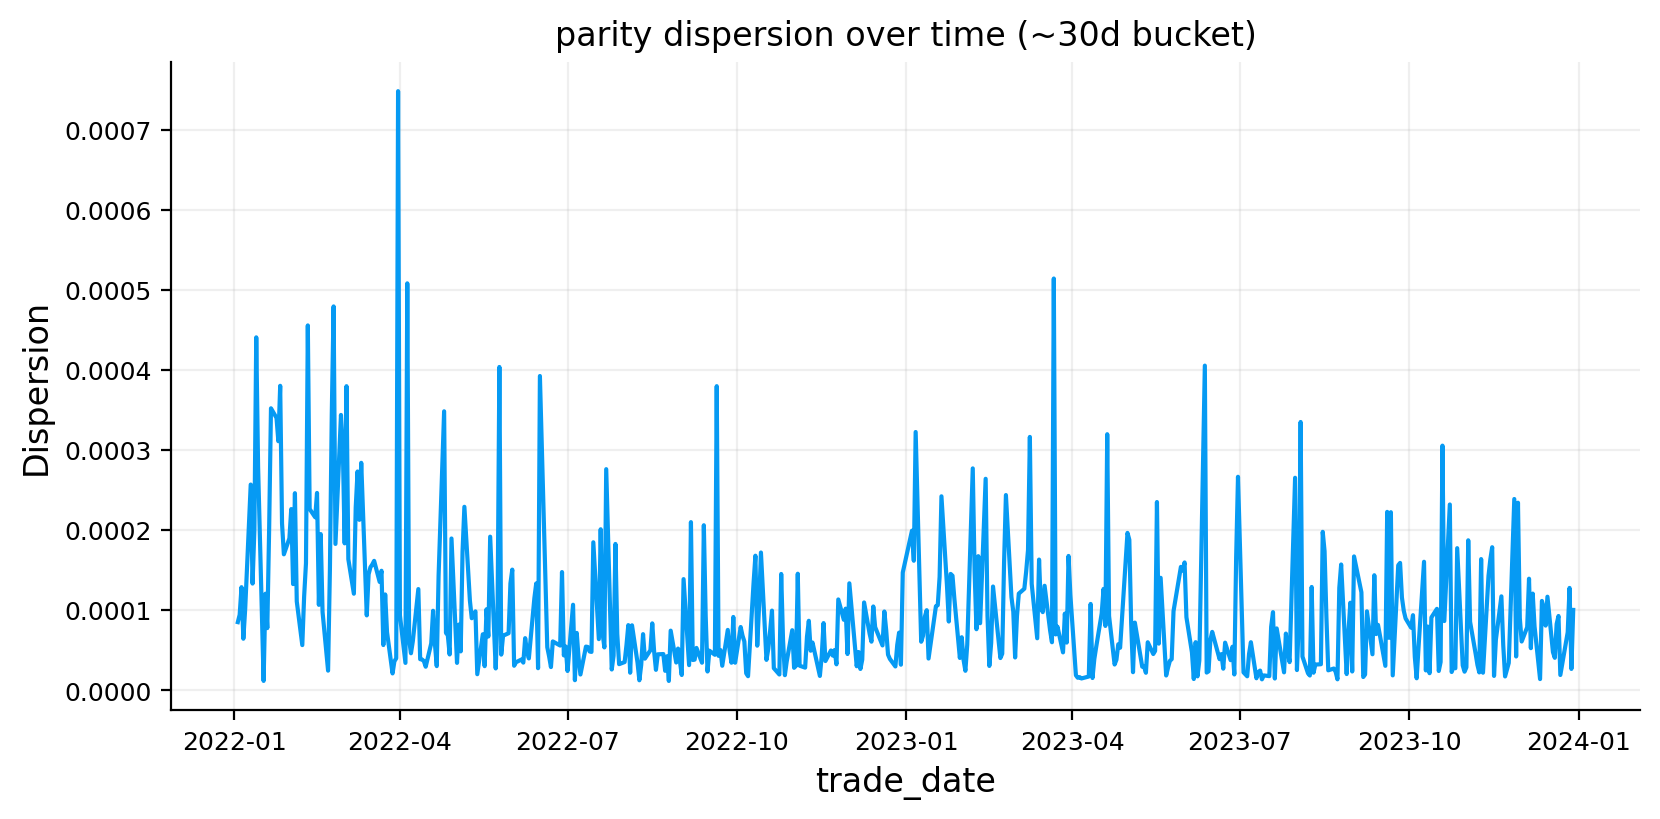

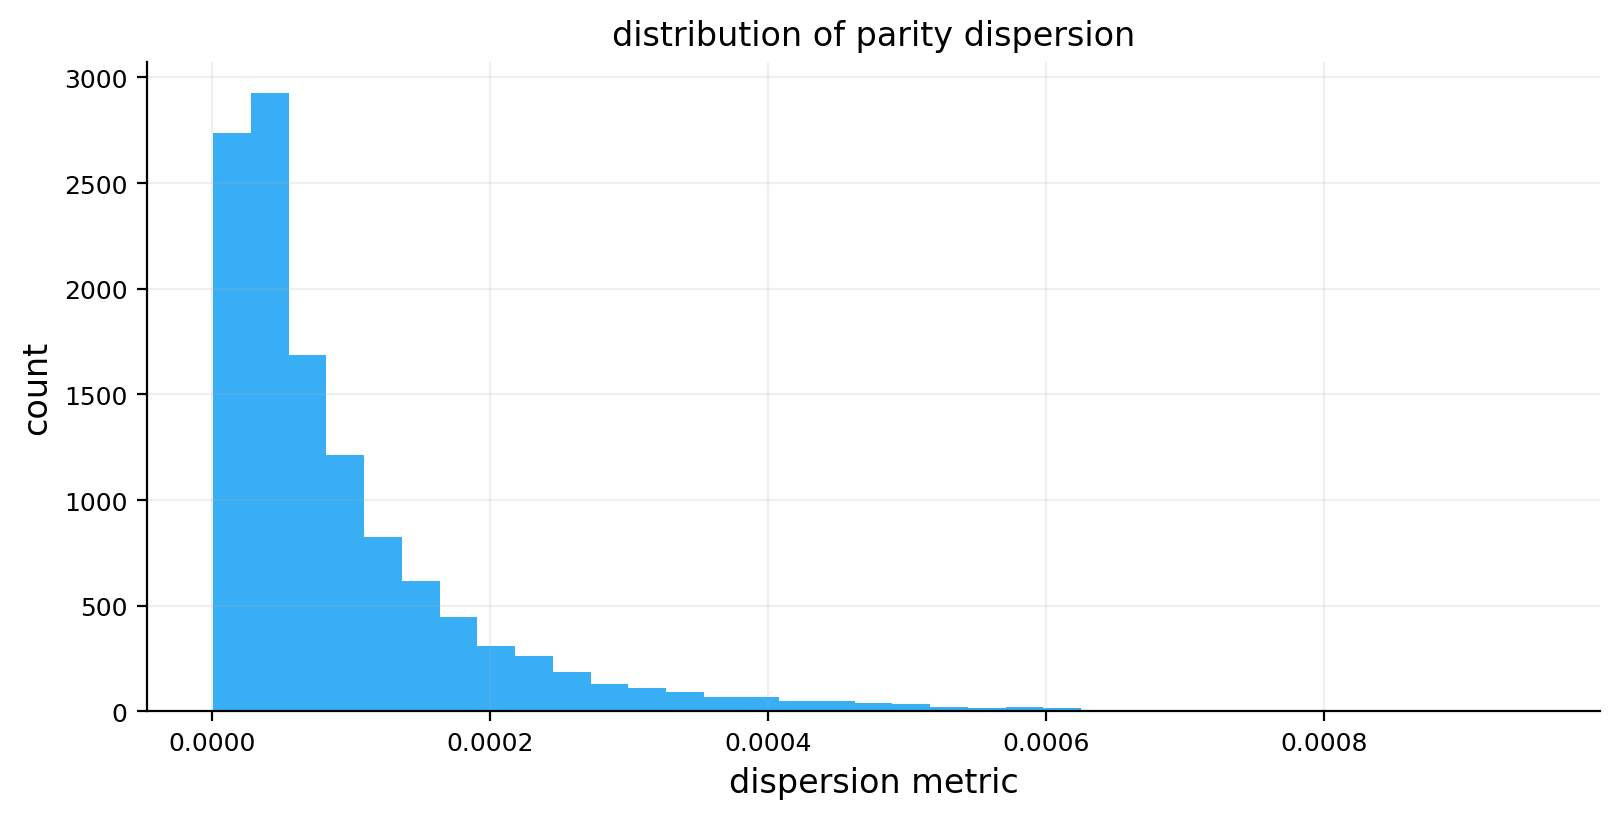

,trade_date,expiry_datetime,dte_days,dispersion,feasibility,n_obs,n_core
4128,2022-10-25,2022-12-16,51.333333,0.000951,0.240000,25,25
4301,2022-11-03,2022-12-23,49.333333,0.000923,1.000000,25,25
1138,2022-03-31,2022-06-30,90.333333,0.000912,0.680000,25,25
1137,2022-03-31,2022-06-17,77.333333,0.000901,0.640000,25,25
1140,2022-03-31,2022-07-29,119.333333,0.000878,1.000000,25,25
1126,2022-03-31,2022-04-18,17.333333,0.000849,0.600000,25,25
1123,2022-03-31,2022-04-11,10.333333,0.000827,0.800000,25,25
1122,2022-03-31,2022-04-08,7.333333,0.000816,0.680000,25,25
1923,2022-05-31,2022-06-09,8.333333,0.000788,1.000000,25,25
1131,2022-03-31,2022-04-29,28.333333,0.000784,0.680000,25,25


In [20]:
parity_diag = df_forward.copy()
parity_diag["dte_days"] = parity_diag["tau"] * 365.25
bucket = parity_diag[(parity_diag["dte_days"] >= 25) & (parity_diag["dte_days"] <= 40)].copy()
if bucket.empty:
    parity_diag["dist_30"] = (parity_diag["dte_days"] - 30.0).abs()
    nearest_exp = parity_diag.sort_values("dist_30").iloc[0]["expiry_datetime"]
    bucket = parity_diag[parity_diag["expiry_datetime"] == nearest_exp].copy()
series_30 = bucket.groupby("trade_date")["dispersion"].median().reset_index()

fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.plot(series_30["trade_date"], series_30["dispersion"], lw=1.5)
ax.set_title("parity dispersion over time (~30d bucket)")
ax.set_xlabel("trade_date")
ax.set_ylabel("Dispersion")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.hist(parity_diag["dispersion"].dropna(), bins=35, alpha=0.8)
ax.set_title("distribution of parity dispersion")
ax.set_xlabel("dispersion metric")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

df_parity_worst = parity_diag.sort_values("dispersion", ascending=False).head(10)[
    ["trade_date", "expiry_datetime", "dte_days", "dispersion", "feasibility", "n_obs", "n_core"]]
df_parity_worst


Dispersion ranges from roughly 0.0002 to 0.0006 (0.02% to 0.06%). There's a clear spike around late March 2022, where dispersion reaches around 0.0006. The series is relatively stable otherwise, hovering around 0.0003-0.0004

A typical dispersion of 0.03-0.04% means that for a $100 forward, the IQR of strike-specific forward estimates spans about $0.03-$0.04. This is tight. put-call parity holds well in this filtered dataset.


The Histogram shows the distribution of dispersion across all expiries and trade dates in the dataset. The distribution is heavily right-skewed with a long tail. Most observations are below 0.0004, but there's a tail extending to 0.001

Dataset has very low dispersion, confirming that put-call parity generally holds tightly.

---

## 11) No-Arbitrage Checks

The goal for this section is to identify quotes that violate fundamental no-arbitrage conditions.

### 11.1. Static Bounds (Intrinsic Value Constraints)

For calls:
$$D \cdot \max(F - K, 0) \le C \le D \cdot F$$

For puts:
$$D \cdot \max(K - F, 0) \le P \le D \cdot K$$

The lower bound is the discounted intrinsic value. an option can never trade below its immediate exercise value. The upper bound reflects that a call can't be worth more than the discounted forward (we could just buy the stock) and a put can't be worth more than the discounted strike (maximum payoff if stock goes to zero).

We allow a tolerance of 25% of the bid-ask spread before flagging a violation. This accounts for microstructure noise. If the bid-ask is wide, we don't want to flag quotes that are technically outside the bounds but within reasonable market friction.

### 11.2 Monotonicity (Decreasing in Strike)

Call prices must be non-increasing in strike:
$$C(K_1) \ge C(K_2) \quad \text{for } K_1 < K_2$$

Put prices must be non-decreasing in strike:
$$P(K_1) \le P(K_2) \quad \text{for } K_1 < K_2$$

A call with a lower strike dominates one with a higher strike (it has all the same payoffs plus more), so it must be worth at least as much.

A violation is flagged if:
- Call prices increase by more than half the average spread of the two strikes
- Put prices decrease by more than half the average spread

### 11.3 Convexity (Butterfly Arbitrage)

Option prices must be convex in strike. For any three strikes $K_0 < K_1 < K_2$, the price at the middle strike must lie below the linear interpolation of the outer strikes:

$$C(K_1) \le \lambda C(K_0) + (1 - \lambda) C(K_2) \qquad \lambda = \frac{K_2 - K_1}{K_2 - K_0}$$

where $\lambda$ is the interpolation weight.

This is the butterfly no-arbitrage condition. If violated, you could construct a butterfly spread (long 1 at $K_0$, short 2 at $K_1$, long 1 at $K_2$) with negative cost and non-negative payoff. a pure arbitrage.

Convexity violations are more common because:

- They involve three strikes instead of two, so there's more opportunity for noise to accumulate
- The check is more sensitive to small pricing errors
- Illiquid strikes in the wings can have erratic prices


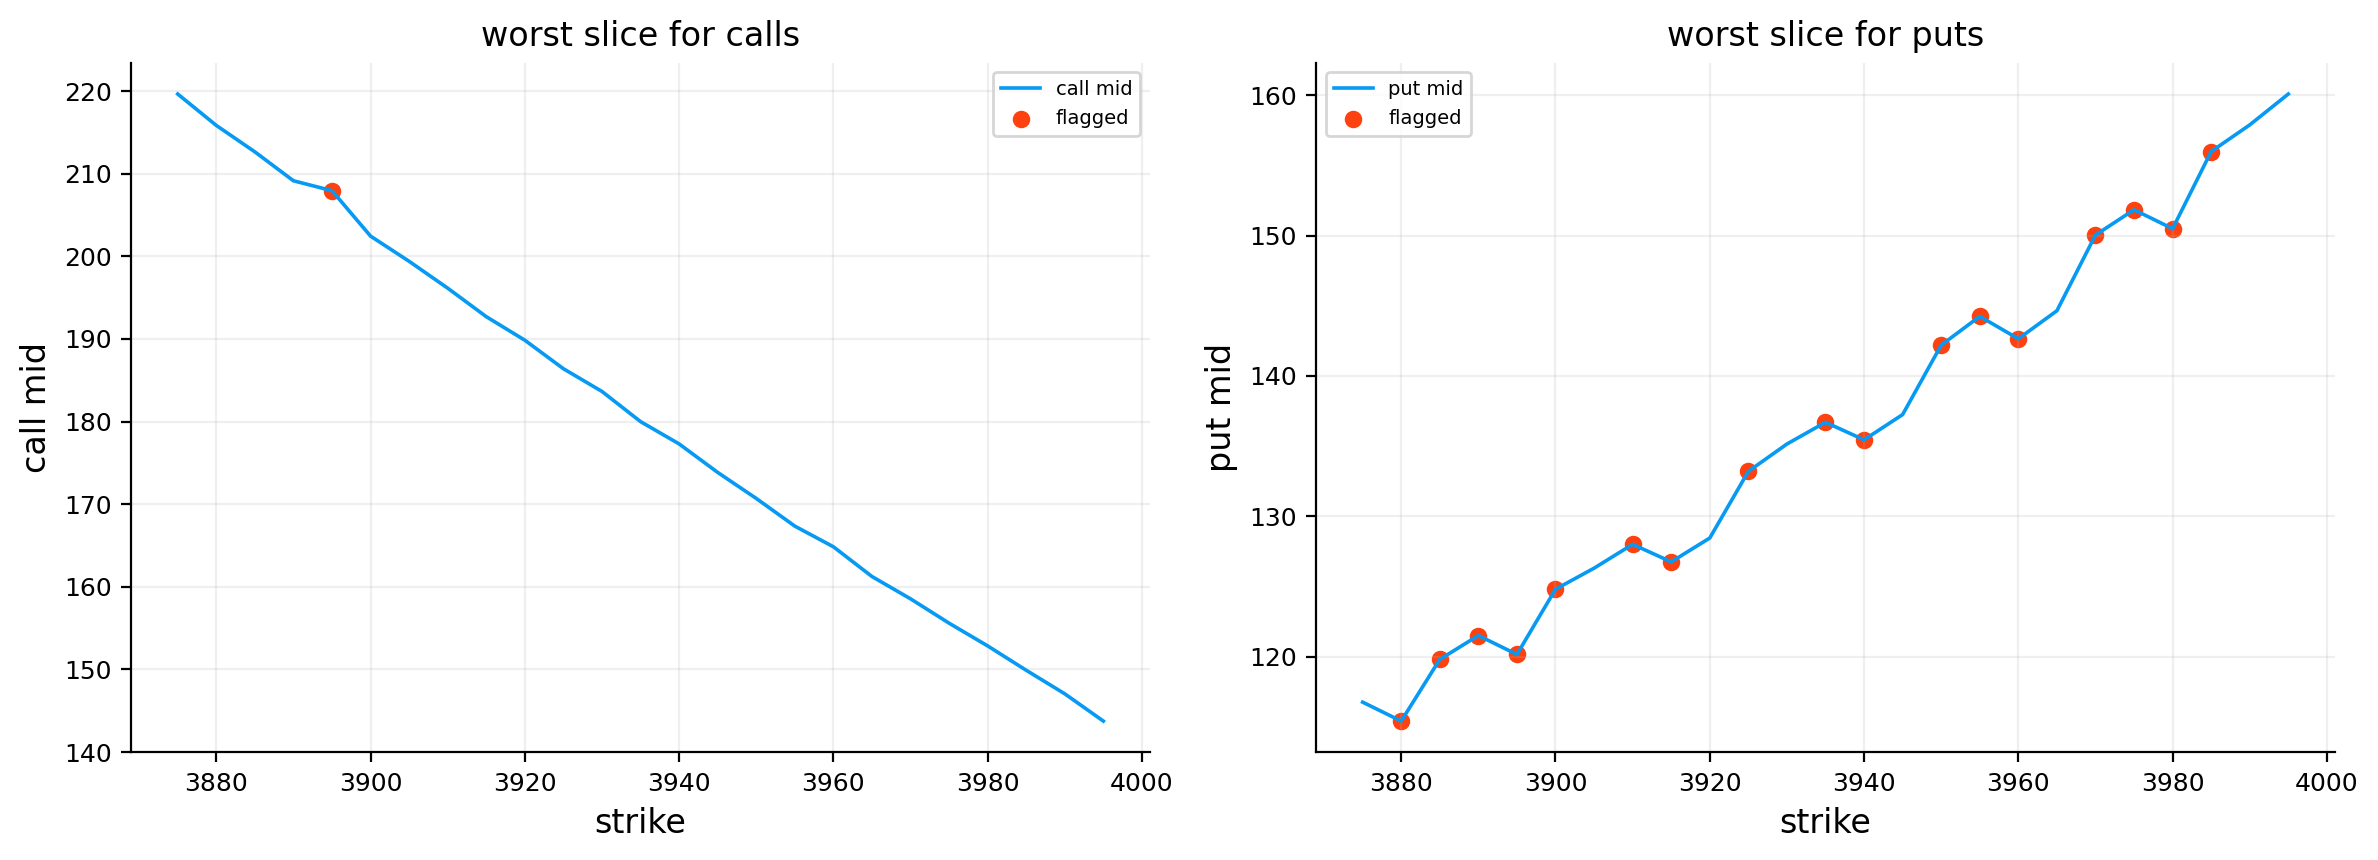

,check_type,total_checked,total_flagged
0,call_bounds,598428,0
1,put_bounds,598428,0
2,monotonicity,598428,42
3,convexity_irregular_grid,598428,2024


In [21]:
df_arb = df_pairs.copy()
tol_call = 0.25 * np.clip(df_arb["c_spread"], 0.0, None)
tol_put = 0.25 * np.clip(df_arb["p_spread"], 0.0, None)
call_low = df_arb["df"] * np.maximum(df_arb["f_hat"] - df_arb["strike"], 0.0)
call_high = df_arb["df"] * df_arb["f_hat"]
put_low = df_arb["df"] * np.maximum(df_arb["strike"] - df_arb["f_hat"], 0.0)
put_high = df_arb["df"] * df_arb["strike"]

df_arb["flag_call_low"] = df_arb["c_ask"] < (call_low - tol_call)
df_arb["flag_call_high"] = df_arb["c_bid"] > (call_high + tol_call)
df_arb["flag_put_low"] = df_arb["p_ask"] < (put_low - tol_put)
df_arb["flag_put_high"] = df_arb["p_bid"] > (put_high + tol_put)
df_arb["flag_call_mono"] = False
df_arb["flag_put_mono"] = False
df_arb["flag_call_conv"] = False
df_arb["flag_put_conv"] = False

for key, grp in df_arb.groupby(["trade_date", "expiry_datetime"], sort=False):
    g = grp.sort_values("strike")
    idx = g.index.to_numpy()
    strike = g["strike"].to_numpy(dtype=float)
    c_mid = g["c_mid"].to_numpy(dtype=float)
    p_mid = g["p_mid"].to_numpy(dtype=float)
    c_sp = g["c_spread"].to_numpy(dtype=float)
    p_sp = g["p_spread"].to_numpy(dtype=float)

    if len(g) >= 2:
        c_bad = np.diff(c_mid) > 0.5 * (c_sp[:-1] + c_sp[1:])
        p_bad = np.diff(p_mid) < -0.5 * (p_sp[:-1] + p_sp[1:])
        if c_bad.any():
            df_arb.loc[idx[1:][c_bad], "flag_call_mono"] = True
        if p_bad.any():
            df_arb.loc[idx[1:][p_bad], "flag_put_mono"] = True

    if len(g) >= 3:
        k0 = strike[:-2]
        k1 = strike[1:-1]
        k2 = strike[2:]
        span = np.clip(k2 - k0, 1e-12, None)
        lam = (k2 - k1) / span

        call_chord = lam * c_mid[:-2] + (1.0 - lam) * c_mid[2:]
        put_chord = lam * p_mid[:-2] + (1.0 - lam) * p_mid[2:]

        call_tol = 0.5 * (c_sp[:-2] + c_sp[1:-1] + c_sp[2:])
        put_tol = 0.5 * (p_sp[:-2] + p_sp[1:-1] + p_sp[2:])

        c_bad2 = c_mid[1:-1] > (call_chord + call_tol)
        p_bad2 = p_mid[1:-1] > (put_chord + put_tol)

        if c_bad2.any():
            df_arb.loc[idx[1:-1][c_bad2], "flag_call_conv"] = True
        if p_bad2.any():
            df_arb.loc[idx[1:-1][p_bad2], "flag_put_conv"] = True

df_arb["flag_any"] = df_arb[
    ["flag_call_low", "flag_call_high", "flag_put_low", "flag_put_high",
    "flag_call_mono", "flag_put_mono", "flag_call_conv", "flag_put_conv"]].any(axis=1)

df_noarb_summary = pd.DataFrame(
    [{"check_type": "call_bounds", "total_checked": int(len(df_arb) * 2), "total_flagged":
       int(df_arb["flag_call_low"].sum() + df_arb["flag_call_high"].sum())},
    {"check_type": "put_bounds", "total_checked": int(len(df_arb) * 2), "total_flagged":
      int(df_arb["flag_put_low"].sum() + df_arb["flag_put_high"].sum())},
    {"check_type": "monotonicity", "total_checked": int(len(df_arb) * 2), "total_flagged":
      int(df_arb["flag_call_mono"].sum() + df_arb["flag_put_mono"].sum())},
    {"check_type": "convexity_irregular_grid", "total_checked": int(len(df_arb) * 2), "total_flagged":
      int(df_arb["flag_call_conv"].sum() + df_arb["flag_put_conv"].sum())}])

slice_bad = df_arb.groupby(["trade_date", "expiry_datetime"])["flag_any"].sum().reset_index().sort_values("flag_any", ascending=False)
worst_key = tuple(slice_bad.iloc[0][["trade_date", "expiry_datetime"]].tolist())
worst = df_arb[(df_arb["trade_date"] == worst_key[0]) & (df_arb["expiry_datetime"] == worst_key[1])].sort_values("strike")
worst["call_flag"] = worst[["flag_call_low", "flag_call_high", "flag_call_mono", "flag_call_conv"]].any(axis=1)
worst["put_flag"] = worst[["flag_put_low", "flag_put_high", "flag_put_mono", "flag_put_conv"]].any(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), sharex=True)
axes[0].plot(worst["strike"], worst["c_mid"], lw=1.3, label="call mid")
axes[0].scatter(worst.loc[worst["call_flag"], "strike"], worst.loc[worst["call_flag"], "c_mid"], c=palette[1], s=28, label="flagged")
axes[0].set_title("worst slice for calls")
axes[0].set_xlabel("strike")
axes[0].set_ylabel("call mid")
axes[0].legend(loc="best")
axes[1].plot(worst["strike"], worst["p_mid"], lw=1.3, label="put mid")
axes[1].scatter(worst.loc[worst["put_flag"], "strike"], worst.loc[worst["put_flag"], "p_mid"], c=palette[1],  s=28, label="flagged")
axes[1].set_title("worst slice for puts")
axes[1].set_xlabel("strike")
axes[1].set_ylabel("put mid")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

df_noarb_summary

The call curve shows a smooth, monotonically decreasing pattern as expected. However, there’s only one flagged strike, which is interesting given this is the worst slice. This single violation is barely visible

The put curve is much more interesting. It shows numerous flagged strikes scattered across the entire strike range.

- No options trade below intrinsic value or above theoretical maximum.
- Monotonicity is near perfect. Only 42 violations, likely due to illiquid strikes or microstructure noise.
- Convexity is good but not perfect. 0.34% violation rate is acceptable for real market data.

---

## 12) Greeks Hedging

Everything up to this point has built the ingredients for a hedge engine:
- spot-aware and forward-aware option pricing
- implied volatility from market quotes
- analytic Greeks
- uncertainty bands
- quality-controlled data

Now we can finally ask the practical question:

> If we hold an option position, how can we control its risk dynamically?

In this notebook we try to simulate real hedging strategies with

- discrete rehedging
- transaction costs
- lot-size constraints
- cooldown rules
- band-based rehedging
- and a proxy hedge instrument (SPY)

That makes the results much closer to a real trading workflow.

The base strategy is a rolling long option position: one representative call contract at a target delta and maturity bucket.

### 12.1 Delta, gamma, and vega exposure

For a portfolio of options, local exposure is summarized by:

$$
\Delta^{\text{opt}} = \sum_i m q_i \Delta_i,
\qquad
\Gamma^{\text{opt}} = \sum_i m q_i \Gamma_i,
\qquad
\mathcal V^{\text{opt}} = \sum_i m q_i \mathcal V_i,
$$

where:

- $m$ is the option multiplier
- $q_i$ is the position in contract $i$

If we also hold the underlying hedge instrument, the total delta-like exposure becomes

$$
\Delta^{\text{total}}= \Delta^{\text{opt}}+ \Delta^{\text{underlying}}.
$$

In this notebook, the underlying hedge is SPY, not SPX. So we need a beta-based conversion from SPY shares into SPX-equivalent delta.

### 12.2 SPY as a hedge for SPX option exposure

SPX is a cash-settled index. We can't directly buy or sell it. To delta-hedge SPX options, we need a tradeable proxy.

We Use SPY (the S&P 500 ETF) as the hedge instrument, but account for the fact that SPY doesn't perfectly track SPX due to:
- Tracking error (expense ratio, cash drag)
- Price level differences (SPY ≈ SPX/10)
- Dividend timing (SPY pays quarterly, SPX is a price index)

**Beta Adjustment**:
The code computes a rolling 60-day beta between SPX and SPY returns:

$$\beta_{\text{SPX→SPY}} = \frac{\text{Cov}(\text{SPX returns}, \text{SPY total returns})}{\text{Var}(\text{SPY total returns})}$$

This beta is clipped to [0.85, 1.15] to prevent extreme values from distorting hedges. The median beta across the dataset is reported in the summary table.

**SPX-Equivalent Shares**:
When hedging an SPX option with delta $\Delta_{\text{SPX}}$, the required SPY position is:

$$q_{\text{SPY}} = \frac{\Delta_{\text{SPX}} \cdot \beta \cdot P_{\text{SPY}}}{S_{\text{SPX}}}$$

This converts SPX delta exposure into the equivalent number of SPY shares needed to neutralize it.

**Dividend Handling**:
SPY dividends are credited to the cash account daily, reflecting the total return nature of the hedge. This is critical for accurate P&L. ignoring dividends would understate returns by around 1.5% annually.

### 12.3 Contract Selection Algorithms

### Delta Hedge Selection 

We select the primary option position each time the strategy rolls. The selection optimizes across multiple dimensions:

Eligibility Filters:

- Call or put (specified by strategy)
- Price > $0.25 (avoid illiquid penny options)
- DTE between 28-45 days (the entry window)
- Absolute delta between 0.25-0.75 (avoid deep ITM/OTM)
- Valid Greeks (finite delta, vega, gamma)

We also rank eligible contracts using a composite score:

$$\text{Score} = -2.0 \cdot |\Delta_{\text{abs}} - 0.50| - 0.07 \cdot |\text{DTE} - 35| - 1.75 \cdot \text{RelSpread} - 0.40 \cdot \mathbb{1}_{\text{bad forward}} + 0.00015 \cdot \text{Volume}$$


The contract with the highest score is selected. Ties are broken by volume.


### Delta-Vega Hedge Selection

Here, we select a longer-dated option to hedge vega exposure.

Eligibility Filters:

- Same option type (call/put) as main contract
- Different contract (can't hedge with itself)
- Price > $0.25
- DTE at least 14 days longer than main, minimum 45 days, maximum 120 days
- Valid vega (finite and non-zero)

$$\text{Score} = 0.80 \cdot |\Delta_{\text{hedge}} - \Delta_{\text{main}}| + 0.020 \cdot |\text{DTE}_{\text{hedge}} - \max(\text{DTE}_{\text{main}} + 21, 60)| + 1.75 \cdot \text{RelSpread} - 0.00020 \cdot \text{Volume}$$

The lowest scoring contract is selected (this is a cost function, not a reward).

Longer-dated options have higher vega per unit of delta. By using a longer dated contract, you can neutralize vega with minimal delta contamination. Tht's why we use longer dates for vega.


In [22]:
option_multiplier = 100.0
beta_window = 60
entry_dte_lo = 28.0
entry_dte_hi = 45.0
exit_dte_days = 7.0
default_target_abs_delta = 0.50

delta_outer_band_equiv = 14.0
delta_inner_band_equiv = 3.0
delta_share_lot = 25.0
delta_cooldown_days = 1

vega_outer_ratio = 0.85
vega_inner_ratio = 0.45
vega_rehedge_every = 5
vega_min_hold_days = 5
vega_contract_step = 0.25
max_vega_contracts = 1.5


def share_tc(shares, price, bps=1.0):
    return abs(shares) * float(price) * (bps * 1e-4)


def option_half_spread(row):
    if row is None:
        return 0.0
    if "half_spread" in row.index and np.isfinite(row["half_spread"]):
        return float(max(row["half_spread"], 0.0))
    if "spread" in row.index and np.isfinite(row["spread"]):
        return 0.5 * float(max(row["spread"], 0.0))
    bid = float(row["bid"]) if "bid" in row.index and np.isfinite(row["bid"]) else np.nan
    ask = float(row["ask"]) if "ask" in row.index and np.isfinite(row["ask"]) else np.nan
    if np.isfinite(bid) and np.isfinite(ask):
        return 0.5 * float(max(ask - bid, 0.0))
    return 0.0


def quantize_step(x, step):
    step = float(max(step, 1e-12))
    return float(np.round(float(x) / step) * step)


def band_target_residual(residual, outer_band, inner_band):
    residual = float(residual)
    outer_band = float(max(outer_band, 1e-12))
    inner_band = float(max(min(inner_band, outer_band), 0.0))
    if abs(residual) <= outer_band:
        return None
    return float(np.sign(residual) * inner_band)


def build_hedge_market(df_spx, df_spy):
    spx = df_spx[["trade_date", "close", "ret"]].copy().rename(columns={"close": "spx_close", "ret": "spx_ret"})
    spx["spx_ret"] = np.log(spx["spx_close"] / spx["spx_close"].shift(1))

    if df_spy is None or df_spy.empty:
        out = spx.copy()
        out["hedge_close"] = out["spx_close"]
        out["hedge_dividend"] = 0.0
        out["spy_ret_tr"] = out["spx_ret"]
        out["beta_spx_to_spy"] = 1.0
        out["hedge_symbol"] = "spx_proxy"
        return out

    spy = df_spy.copy()
    spy = spy.sort_values("trade_date").drop_duplicates("trade_date", keep="last").reset_index(drop=True)
    spy["spy_close"] = pd.to_numeric(spy["close"], errors="coerce")
    spy["spy_dividend"] = pd.to_numeric(spy.get("dividend", 0.0), errors="coerce").fillna(0.0)

    if "adj_close" in spy.columns and spy["adj_close"].notna().sum() >= 5:
        spy["spy_ret_tr"] = np.log(spy["adj_close"] / spy["adj_close"].shift(1))
    else:
        gross = (spy["spy_close"] + spy["spy_dividend"]) / spy["spy_close"].shift(1)
        spy["spy_ret_tr"] = np.log(np.clip(gross, 1e-12, None))

    out = spx.merge(spy[["trade_date", "spy_close", "spy_dividend", "spy_ret_tr"]],
                    on="trade_date",how="left",)
    out["hedge_close"] = out["spy_close"]
    out["hedge_dividend"] = out["spy_dividend"].fillna(0.0)

    roll_cov = out["spx_ret"].rolling(beta_window).cov(out["spy_ret_tr"])
    roll_var = out["spy_ret_tr"].rolling(beta_window).var()
    beta = (roll_cov / roll_var).replace([np.inf, -np.inf], np.nan)
    beta = beta.clip(0.85, 1.15).bfill().ffill().fillna(1.0)

    out["beta_spx_to_spy"] = beta
    out["hedge_symbol"] = "spy"
    return out


def trade_share(cash, current_pos, target_pos, px):
    delta_q = float(target_pos - current_pos)
    notional = abs(delta_q) * float(px)
    cash -= delta_q * float(px)
    cost = share_tc(delta_q, px)
    cash -= cost
    return cash, float(target_pos), cost, notional


def trade_option(cash, current_pos, target_pos, px, row=None):
    delta_q = float(target_pos - current_pos)
    notional = abs(delta_q) * float(px) * option_multiplier
    cash -= delta_q * float(px) * option_multiplier
    cost = abs(delta_q) * option_half_spread(row) * option_multiplier
    cash -= cost
    return cash, float(target_pos), cost, notional


def under_equiv_per_share(spx_level, hedge_px, hedge_beta):
    hedge_px = float(max(hedge_px, 1e-12))
    hedge_beta = float(np.clip(hedge_beta, 0.90, 1.10)) if np.isfinite(hedge_beta) else 1.0
    spx_level = float(max(spx_level, 1e-12))
    return float(hedge_beta * hedge_px / spx_level)


def target_under_pos_for_residual(option_delta_equiv, target_residual, spx_level, hedge_px, hedge_beta):
    equiv = under_equiv_per_share(spx_level, hedge_px, hedge_beta)
    return float((float(target_residual) - float(option_delta_equiv)) / equiv)


hedge_market = build_hedge_market(df_spx, df_spy)
hedge_market = hedge_market.sort_values("trade_date").drop_duplicates("trade_date", keep="last").reset_index(drop=True)
hedge_by_date = hedge_market.set_index("trade_date")

df_options["contract_key"] = (
    df_options["cp"].astype(str)+ "_"+ pd.to_datetime(df_options["expiry_datetime"])
    .dt.strftime("%Y-%m-%d")+ "_"+ df_options["strike"].round(4).astype(str))

df_hedge_options = df_options[df_options["iv_ok"]].copy()
df_hedge_options = (df_hedge_options
                    .sort_values(["trade_date", "expiry_datetime", "strike"])
                    .drop_duplicates(["trade_date", "contract_key"]))

df_hedge_options["dte_days"] = df_hedge_options["tau"] * 365.25
df_hedge_options["abs_delta_mid"] = np.abs(df_hedge_options["delta_spot_mid"])
df_hedge_options["mid"] = pd.to_numeric(df_hedge_options["mid"], errors="coerce")
df_hedge_options["rel_spread"] = pd.to_numeric(df_hedge_options["rel_spread"], errors="coerce")
df_hedge_options["volume"] = pd.to_numeric(df_hedge_options.get("volume", 0.0), errors="coerce").fillna(0.0)

if "forward_quality_ok" in df_hedge_options.columns:
    df_hedge_options["forward_quality_ok"] = df_hedge_options["forward_quality_ok"].fillna(False)
else:
    df_hedge_options["forward_quality_ok"] = True

books = {d: g.set_index("contract_key") for d, g in df_hedge_options.groupby("trade_date", sort=True)}
trade_dates = sorted(books.keys())


def pick_main_contract(day, cp="call", side=1.0, target_abs_delta=default_target_abs_delta):
    d = day.copy()
    d = d[(d["cp"] == cp) & (d["mid"] > 0.25) & np.isfinite(d["delta_spot_mid"])
         & np.isfinite(d["vega_mid"]) & np.isfinite(d["gamma_spot_mid"])
         & (d["dte_days"] >= entry_dte_lo) & (d["dte_days"] <= entry_dte_hi)].copy()
    if d.empty:
        return None

    d = d[(d["abs_delta_mid"] >= 0.25) & (d["abs_delta_mid"] <= 0.75)].copy()
    if d.empty:
        return None

    if side > 0:
        d = d[d["delta_spot_mid"] > 0.0].copy() if cp == "call" else d[d["delta_spot_mid"] < 0.0].copy()
    else:
        d = d[d["delta_spot_mid"].abs() >= 0.25].copy()
    if d.empty:
        return None

    d["entry_score"] = (-2.0 * (d["abs_delta_mid"] - target_abs_delta).abs()
                        -0.07 * (d["dte_days"] - 35.0).abs()-1.75 * d["rel_spread"].fillna(0.0)
                        -0.40 * (~d["forward_quality_ok"]).astype(float) + 0.00015 * d["volume"].fillna(0.0))
    
    return str(d.sort_values(["entry_score", "volume"], ascending=[False, False]).index[0])


def pick_vega_hedge(day, main_id):
    if main_id not in day.index:
        return None

    main_row = day.loc[main_id]
    d = day.copy()
    d = d[(d.index != main_id) & (d["cp"] == main_row["cp"]) 
          & (d["mid"] > 0.25) & np.isfinite(d["vega_mid"]) 
          & np.isfinite(d["delta_spot_mid"]) & (np.abs(d["vega_mid"]) > 1e-8)
          & (d["dte_days"] >= max(main_row["dte_days"] + 14.0, 45.0)) & (d["dte_days"] <= 120.0)].copy()
    if d.empty:
        return None

    d["score"] = (0.80 * np.abs(d["abs_delta_mid"] - main_row["abs_delta_mid"])
                  +0.020 * np.abs(d["dte_days"] - max(main_row["dte_days"] + 21.0, 60.0))
                  +1.75 * d["rel_spread"].fillna(0.0) -0.00020 * d["volume"].fillna(0.0))
    return str(d.sort_values("score").index[0])


strategy_catalog = {"demo_long_call": {"side": 1.0, "cp": "call", "target_abs_delta": 0.50}}

### 12.4 Hedging Logic: Band-Based Rebalancing

We try to avoid over trading while maintaining risk control. That's why we use bands instead of trying to neutralize completely.

Residual Delta Calculation:

$$\Delta_{\text{residual}} = \Delta_{\text{options}} + q_{\text{SPY}} \cdot \frac{\beta \cdot P_{\text{SPY}}}{S_{\text{SPX}}}$$

This is the net directional exposure in SPX-equivalent units.

Band Logic:

- **Outer band**: 14 SPX points (±$1,400 notional per contract)
- **Inner band**: 3 SPX points (±$300 notional per contract)

Rebalancing Rule:

IF $|\Delta_{\text{residual}}| > \text{outer\_band}$:

$$\text{target\_residual} = \text{sign}(\Delta_{\text{residual}}) \times \text{inner\_band}$$

rebalance to target

IF NOT: do nothing


Without bands, we'd rebalance continuously as delta drifts due to gamma and spot moves, incurring excessive transaction costs. Bands create a no trade zone where small exposures are tolerated.


- 14 SPX points ≈ 0.35% of a 4000 SPX level, representing ~$35 P&L per point move
- 3 SPX points is the target residual, leaving a small buffer to avoid immediate re triggering
- The 14:3 ratio provides hysteresis. We need a significant move to trigger, but then you hedge aggressively

After rebalancing delta, the system waits 1 day before allowing another delta trade. This prevents thrashing on volatile days.

SPY trades are rounded to 25 share lots, reflecting realistic order sizes and reducing microstructure impact.

#### Residual Vega Calculation

$$V_{\text{residual}} = V_{\text{main}} + q_{\text{hedge}} \cdot V_{\text{hedge contract}}$$

Band Logic (ratio-based, not absolute)

- Outer band: 85% of main contract vega
- Inner band: 45% of main contract vega

Rebalancing Rule

**IF** $|V_{\text{residual}}| > 0.85 \times |V_{\text{main}}|$:

$$\text{target\_residual} = \text{sign}(V_{\text{residual}}) \times 0.45 \times |V_{\text{main}}|$$

$$\text{target\_q\_hedge} = \frac{\text{target\_residual} - V_{\text{main}}}{V_{\text{hedge\_unit}}}$$

- round to 0.25 contract increments
- clip to [-1.5, +1.5] contracts
- rebalance if change ≥ 0.25 contracts

The 85%/45% ratio is tighter than delta because vega hedging is less frequent (every 5 days vs. every 1 day)

### 12.5 Additional Constraints

- Minimum 5 days in position before first vega rebalance (avoid premature hedging)
- Rebalance at most every 5 days (reduce turnover)
- Only rebalance if outside outer band


### 12.6 Transactions costs

$$\text{Cost} = |q_{\text{traded}}| \cdot P \cdot 1 \text{ bps} = |q| \cdot P \cdot 0.0001$$

This reflects typical institutional equity trading costs (commission + spread + market impact).

Option Transactions:

$$\text{Cost} = |q_{\text{traded}}| \cdot \frac{\text{Bid-Ask Spread}}{2} \cdot 100$$


### 12.7 Roll Logic

The strategy rolls (closes old position, opens new position) when:

- No position exists (first day)
- The current contract is no longer in the dataset (delisted or data gap)
- The main contract has < 7 days to expiry

Roll Procedure:

1. Close all positions (main option, vega hedge, SPY shares) at current mid-prices
2. Select new main contract
3. In delta_vega mode, select new vega hedge
4. Open new main position (1 contract long or short, depending on strategy)
5. Reset all rebalancing timers and counters

In [23]:
def simulate_strategy(name, mode="none", strategy_key="demo_long_call"):
    cfg = strategy_catalog[strategy_key]
    side = float(cfg["side"])
    cp = str(cfg["cp"])
    target_abs_delta = float(cfg["target_abs_delta"])

    q_main = 0.0
    q_hedge = 0.0
    q_under = 0.0
    cash = 0.0

    main_id = None
    hedge_id = None
    last_main_mid = np.nan
    last_hedge_mid = np.nan

    prev_equity = np.nan
    prev_date = None
    prev_r = 0.0
    episode_id = -1
    days_since_under_rehedge = 0
    days_since_option_rehedge = 0
    days_in_episode = 0
    rows = []

    for d in trade_dates:
        day = books[d]
        if d not in hedge_by_date.index:
            continue

        hedge_day = hedge_by_date.loc[d]
        hedge_px = float(hedge_day["hedge_close"])
        hedge_div = float(hedge_day["hedge_dividend"])
        hedge_beta = float(hedge_day["beta_spx_to_spy"]) if "beta_spx_to_spy" in hedge_day.index else 1.0
        hedge_symbol = str(hedge_day["hedge_symbol"]) if "hedge_symbol" in hedge_day.index else "spy"

        day_cost = 0.0
        day_turnover = 0.0

        if prev_date is not None:
            dt_year = max((pd.Timestamp(d) - pd.Timestamp(prev_date)).days / 365.25, 0.0)
            cash *= np.exp(prev_r * dt_year)
            if q_under != 0.0:
                cash += q_under * hedge_div

        roll = False
        roll_reason = "none"
        if main_id is None:
            roll = True
            roll_reason = "start"
        elif main_id not in day.index:
            roll = True
            roll_reason = "missing_contract"
        elif float(day.loc[main_id, "dte_days"]) < exit_dte_days:
            roll = True
            roll_reason = "exit_dte"

        if roll:
            if q_main != 0.0:
                px_main = float(day.loc[main_id, "mid"]) if (main_id is not None and main_id in day.index) else float(last_main_mid)
                row_main = day.loc[main_id] if (main_id is not None and main_id in day.index) else None
                cash, q_main, cost_i, turnover_i = trade_option(cash, q_main, 0.0, px_main, row_main)
                day_cost += cost_i
                day_turnover += turnover_i

            if q_hedge != 0.0:
                px_h = float(day.loc[hedge_id, "mid"]) if (hedge_id is not None and hedge_id in day.index) else float(last_hedge_mid)
                row_h = day.loc[hedge_id] if (hedge_id is not None and hedge_id in day.index) else None
                cash, q_hedge, cost_i, turnover_i = trade_option(cash, q_hedge, 0.0, px_h, row_h)
                day_cost += cost_i
                day_turnover += turnover_i

            if q_under != 0.0:
                cash, q_under, cost_i, turnover_i = trade_share(cash, q_under, 0.0, hedge_px)
                day_cost += cost_i
                day_turnover += turnover_i

            main_id = pick_main_contract(day, cp=cp, side=side, target_abs_delta=target_abs_delta)
            hedge_id = None
            q_hedge = 0.0
            q_under = 0.0
            days_since_under_rehedge = 0
            days_since_option_rehedge = 0
            days_in_episode = 0

            if main_id is not None:
                episode_id += 1
                main_row = day.loc[main_id]
                cash, q_main, cost_i, turnover_i = trade_option(cash, q_main, side, float(main_row["mid"]), main_row)
                day_cost += cost_i
                day_turnover += turnover_i
                if mode == "delta_vega":
                    hedge_id = pick_vega_hedge(day, main_id)
            else:
                q_main = 0.0

        if main_id is None or main_id not in day.index:
            equity = cash
            pnl = equity - prev_equity if np.isfinite(prev_equity) else equity
            rows.append(
                {"trade_date": d, "strategy": name, "mode": mode, "episode_id": int(episode_id),
                 "equity": equity, "daily_pnl": pnl, "cost": day_cost, "turnover": day_turnover,
                 "roll": int(roll), "roll_reason": roll_reason, "hedge_symbol": hedge_symbol,
                 "hedge_beta": hedge_beta, "hedge_price": hedge_px, "hedge_dividend": hedge_div,
                 "under_pos": q_under, "main_pos": q_main, "hedge_pos": q_hedge,
                 "main_contract": main_id, "hedge_contract": hedge_id, "residual_delta_equiv": 0.0,
                 "residual_gamma_equiv": 0.0, "residual_vega_equiv": 0.0})
            prev_equity = equity
            prev_date = d
            prev_r = 0.0
            continue

        main_row = day.loc[main_id]
        last_main_mid = float(main_row["mid"])
        spx_level = float(main_row["s"])

        hedge_row = None
        if hedge_id is not None and hedge_id in day.index:
            hedge_row = day.loc[hedge_id]
            last_hedge_mid = float(hedge_row["mid"])

        main_delta_equiv = option_multiplier * q_main * float(main_row["delta_spot_mid"])
        main_gamma_equiv = option_multiplier * q_main * float(main_row["gamma_spot_mid"])
        main_vega_equiv = option_multiplier * q_main * float(main_row["vega_mid"])

        if mode == "delta_vega" and hedge_row is not None:
            hedge_vega_unit = option_multiplier * float(hedge_row["vega_mid"])
            residual_vega_pre = main_vega_equiv + hedge_vega_unit * q_hedge
            vega_outer_band = vega_outer_ratio * max(abs(main_vega_equiv), 1e-8)
            vega_inner_band = vega_inner_ratio * max(abs(main_vega_equiv), 1e-8)

            desired_vega_residual = band_target_residual(residual_vega_pre, vega_outer_band, vega_inner_band)
            allow_vega_trade = roll or ((days_in_episode >= vega_min_hold_days)
                                        and (days_since_option_rehedge >= vega_rehedge_every)
                                          and (desired_vega_residual is not None))

            if allow_vega_trade and np.isfinite(hedge_vega_unit) and abs(hedge_vega_unit) > 1e-8:
                target_q_hedge = (desired_vega_residual - main_vega_equiv) / hedge_vega_unit
                target_q_hedge = float(np.clip(target_q_hedge, -max_vega_contracts, max_vega_contracts))
                target_q_hedge = quantize_step(target_q_hedge, vega_contract_step)

                if abs(target_q_hedge - q_hedge) >= vega_contract_step:
                    cash, q_hedge, cost_i, turnover_i = trade_option(cash, q_hedge, target_q_hedge, float(hedge_row["mid"]), hedge_row)
                    day_cost += cost_i
                    day_turnover += turnover_i
                    days_since_option_rehedge = 0
                else:
                    days_since_option_rehedge += 1
            else:
                days_since_option_rehedge += 1
        else:
            days_since_option_rehedge += 1

        option_delta_equiv = main_delta_equiv
        option_gamma_equiv = main_gamma_equiv
        option_vega_equiv = main_vega_equiv

        if hedge_row is not None:
            option_delta_equiv += option_multiplier * q_hedge * float(hedge_row["delta_spot_mid"])
            option_gamma_equiv += option_multiplier * q_hedge * float(hedge_row["gamma_spot_mid"])
            option_vega_equiv += option_multiplier * q_hedge * float(hedge_row["vega_mid"])

        share_delta_equiv_pre = q_under * under_equiv_per_share(spx_level, hedge_px, hedge_beta)
        residual_delta_equiv_pre = option_delta_equiv + share_delta_equiv_pre

        if mode == "none":
            target_q_under = 0.0
            should_trade_under = abs(q_under) > 0.0
        else:
            desired_delta_residual = band_target_residual(
                residual_delta_equiv_pre,
                delta_outer_band_equiv,
                delta_inner_band_equiv,
            )
            should_trade_under = roll or (
                (desired_delta_residual is not None) and (days_since_under_rehedge >= delta_cooldown_days)
            )
            if desired_delta_residual is not None:
                target_q_under = target_under_pos_for_residual(
                    option_delta_equiv,
                    desired_delta_residual,
                    spx_level,
                    hedge_px,
                    hedge_beta,
                )
                target_q_under = float(np.round(target_q_under / delta_share_lot) * delta_share_lot)
            else:
                target_q_under = q_under

        if should_trade_under and abs(target_q_under - q_under) >= delta_share_lot:
            cash, q_under, cost_i, turnover_i = trade_share(cash, q_under, target_q_under, hedge_px)
            day_cost += cost_i
            day_turnover += turnover_i
            days_since_under_rehedge = 0
        else:
            days_since_under_rehedge += 1

        share_delta_equiv = q_under * under_equiv_per_share(spx_level, hedge_px, hedge_beta)
        residual_delta_equiv = option_delta_equiv + share_delta_equiv

        main_val = q_main * float(main_row["mid"]) * option_multiplier
        hedge_val = q_hedge * float(last_hedge_mid) * option_multiplier if np.isfinite(last_hedge_mid) else 0.0
        under_val = q_under * hedge_px
        equity = cash + main_val + hedge_val + under_val
        pnl = equity - prev_equity if np.isfinite(prev_equity) else equity

        rows.append(
            {"trade_date": d, "strategy": name, "mode": mode, "episode_id": int(episode_id),
              "equity": equity, "daily_pnl": pnl, "cost": day_cost, "turnover": day_turnover,
              "roll": int(roll), "roll_reason": roll_reason, "hedge_symbol": hedge_symbol,
              "hedge_beta": hedge_beta, "hedge_price": hedge_px, "hedge_dividend": hedge_div,
              "under_pos": q_under, "main_pos": q_main, "hedge_pos": q_hedge, "main_contract": main_id,
              "hedge_contract": hedge_id, "residual_delta_equiv": residual_delta_equiv, 
              "residual_delta_equiv_pre": residual_delta_equiv_pre, "residual_gamma_equiv": option_gamma_equiv,
              "residual_vega_equiv": option_vega_equiv})

        prev_equity = equity
        prev_date = d
        prev_r = float(main_row["r_short"])
        days_in_episode += 1

    return pd.DataFrame(rows)


df_hedge_market_summary = pd.DataFrame(
    [{"metric": "hedge_symbol", "value": hedge_market["hedge_symbol"].iloc[0] if len(hedge_market) else "na"},
     {"metric": "median_beta_spx_to_spy", "value": float(np.nanmedian(hedge_market["beta_spx_to_spy"]))
       if len(hedge_market) else np.nan},
     {"metric": "entry_dte_lo", "value": float(entry_dte_lo)},
     {"metric": "entry_dte_hi", "value": float(entry_dte_hi)},
     {"metric": "exit_dte_days", "value": float(exit_dte_days)},
     {"metric": "target_abs_delta", "value": float(default_target_abs_delta)},
     {"metric": "delta_outer_band_equiv", "value": float(delta_outer_band_equiv)},
     {"metric": "delta_inner_band_equiv", "value": float(delta_inner_band_equiv)},
     {"metric": "delta_share_lot", "value": float(delta_share_lot)},
     {"metric": "vega_outer_ratio", "value": float(vega_outer_ratio)},
     {"metric": "vega_inner_ratio", "value": float(vega_inner_ratio)},
     {"metric": "vega_rehedge_every_days", "value": int(vega_rehedge_every)},
     {"metric": "vega_min_hold_days", "value": int(vega_min_hold_days)},
     {"metric": "vega_contract_step", "value": float(vega_contract_step)},
     {"metric": "max_vega_contracts", "value": float(max_vega_contracts)}])

display(df_hedge_market_summary)

,metric,value
0,hedge_symbol,spy
1,median_beta_spx_to_spy,0.942227
2,entry_dte_lo,28.000000
3,entry_dte_hi,45.000000
4,exit_dte_days,7.000000
5,target_abs_delta,0.500000
6,delta_outer_band_equiv,14.000000
7,delta_inner_band_equiv,3.000000
8,delta_share_lot,25.000000
9,vega_outer_ratio,0.850000


### 12.8 running the strategy simulation

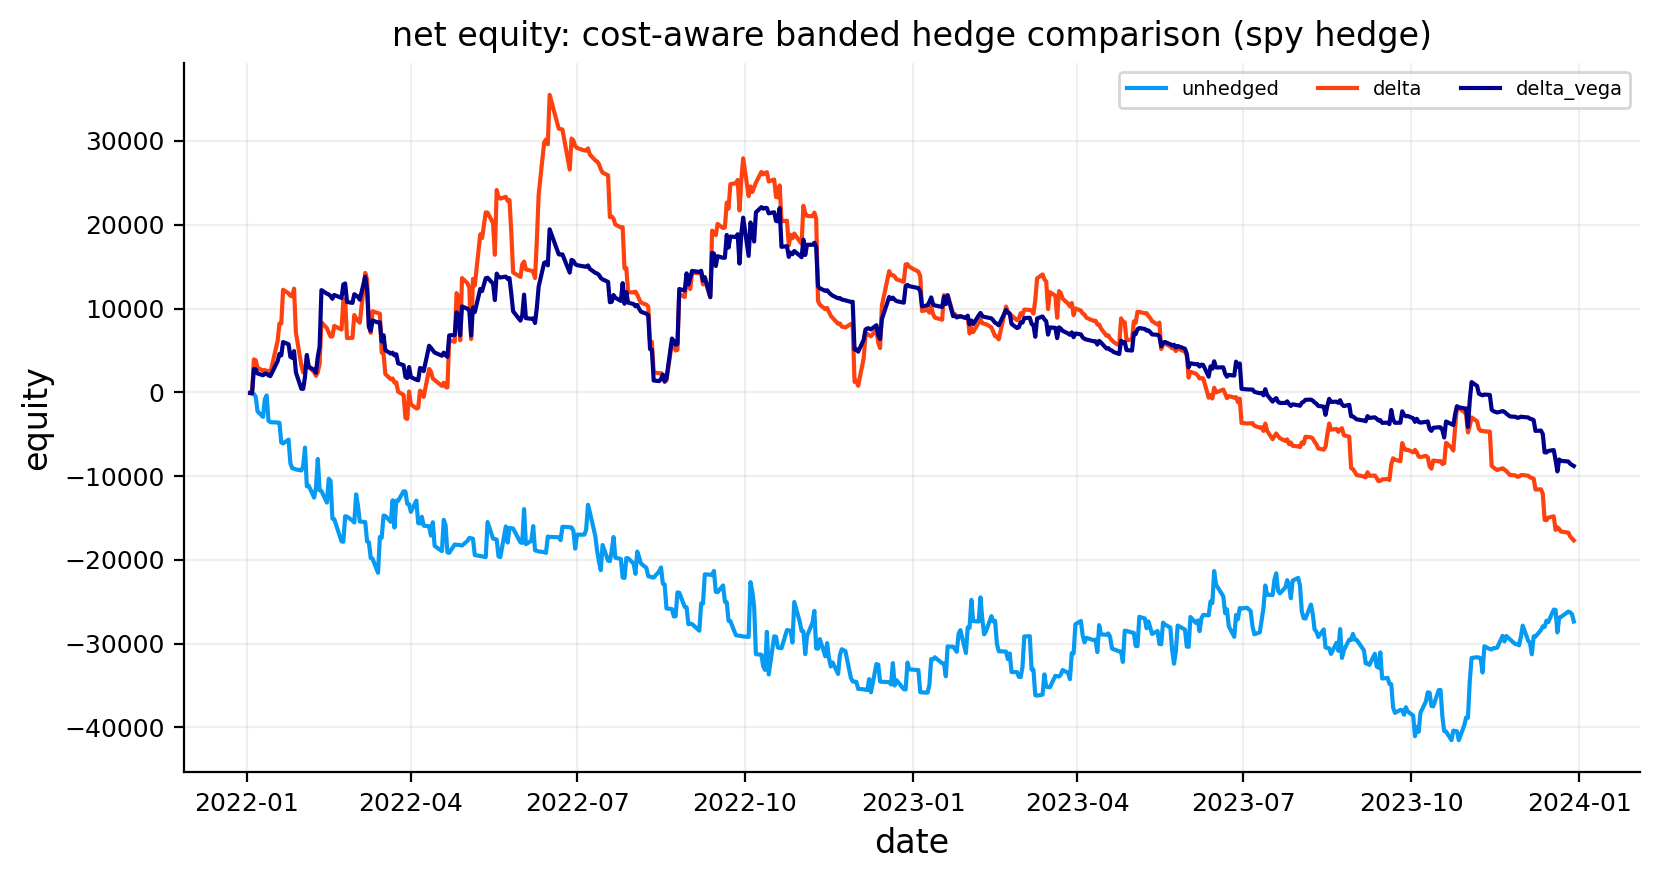

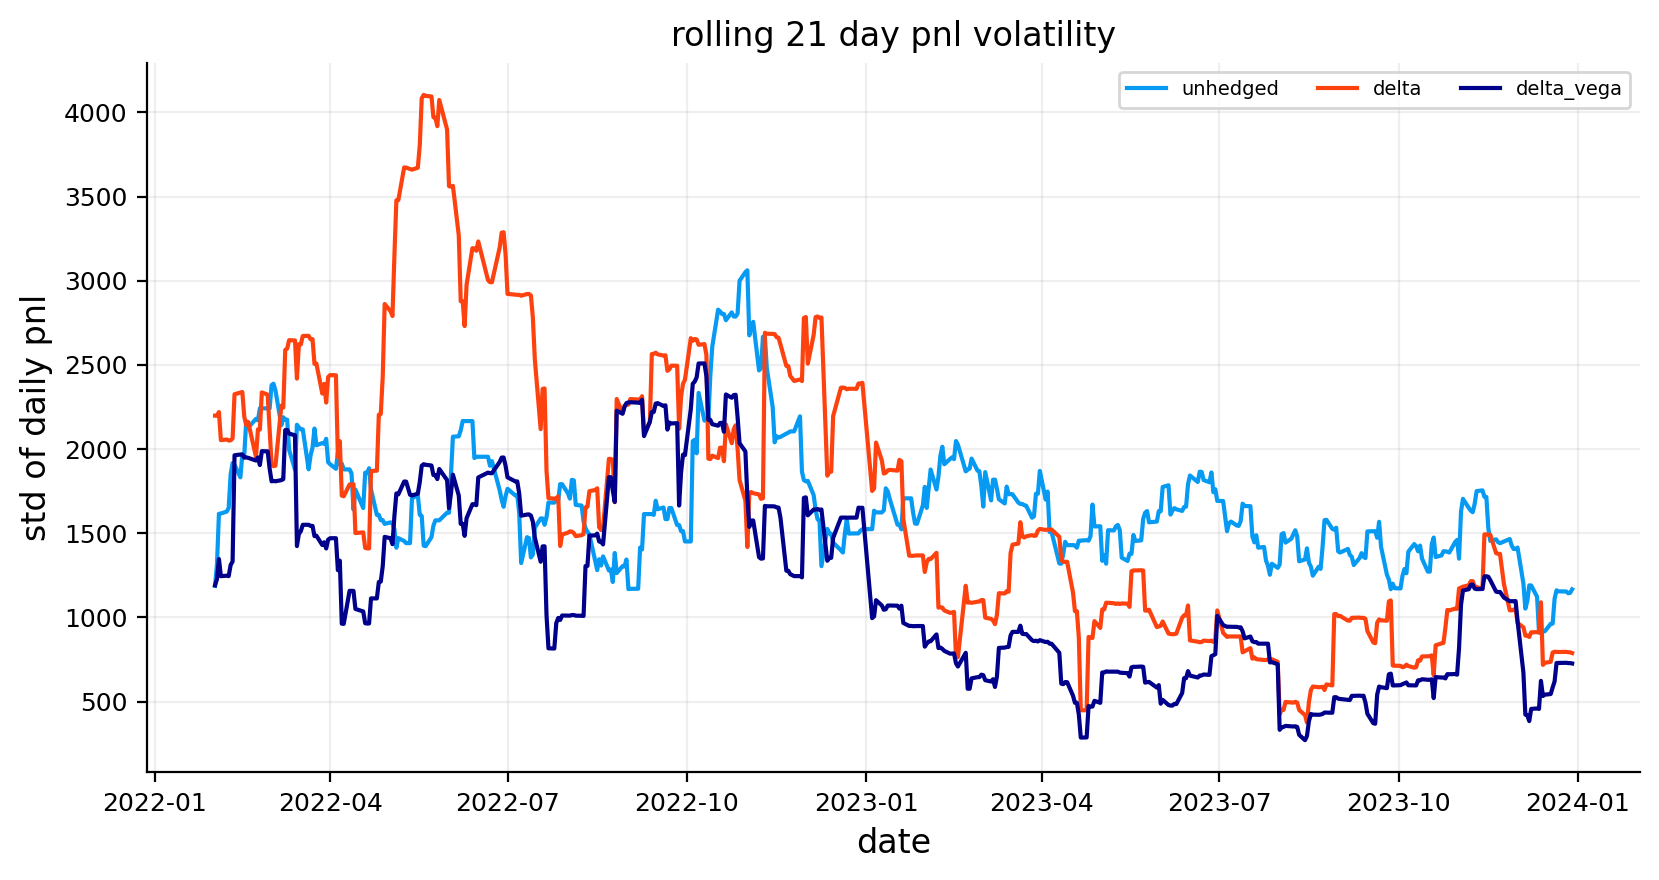

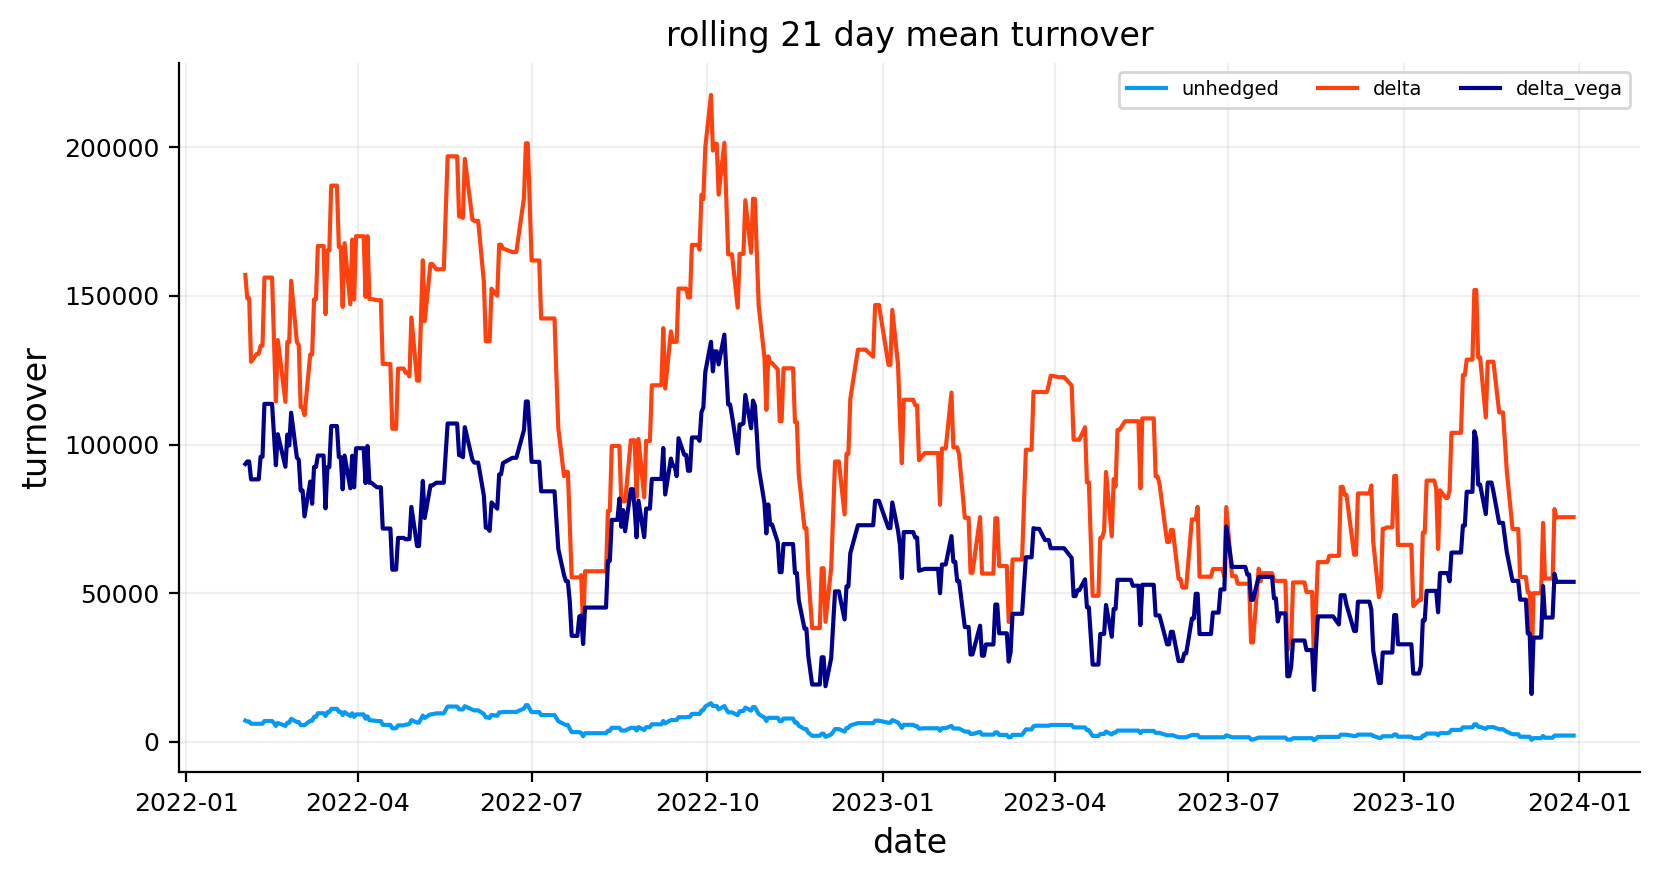

In [24]:
strategy_runs = {}
strategy_runs["unhedged"] = simulate_strategy("unhedged", mode="none")
strategy_runs["delta"] = simulate_strategy("delta", mode="delta")
strategy_runs["delta_vega"] = simulate_strategy("delta_vega", mode="delta_vega")

plot_keys = ["unhedged", "delta", "delta_vega"]

fig, ax = plt.subplots(figsize=(8.4, 4.5), sharex=True)
for k in plot_keys:
    run = strategy_runs[k]
    ax.plot(run["trade_date"], run["equity"], label=k)
ax.legend(ncol=3)
hedge_label = next((run["hedge_symbol"].iloc[0] for run in strategy_runs.values() if len(run)), "spy")
ax.set_title(f"net equity: cost-aware banded hedge comparison ({hedge_label} hedge)")
ax.set_ylabel("equity")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 4.5), sharex=True)
for k in plot_keys:
    run = strategy_runs[k].copy()
    roll_vol = run["daily_pnl"].rolling(21).std()
    ax.plot(run["trade_date"], roll_vol, label=k)
ax.legend(ncol=3)
ax.set_title("rolling 21 day pnl volatility")
ax.set_ylabel("std of daily pnl")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 4.5), sharex=True)
for k in plot_keys:
    run = strategy_runs[k].copy()
    roll_turn = run["turnover"].rolling(21).mean()
    ax.plot(run["trade_date"], roll_turn, label=k)
ax.legend(ncol=3)
ax.set_title("rolling 21 day mean turnover")
ax.set_ylabel("turnover")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

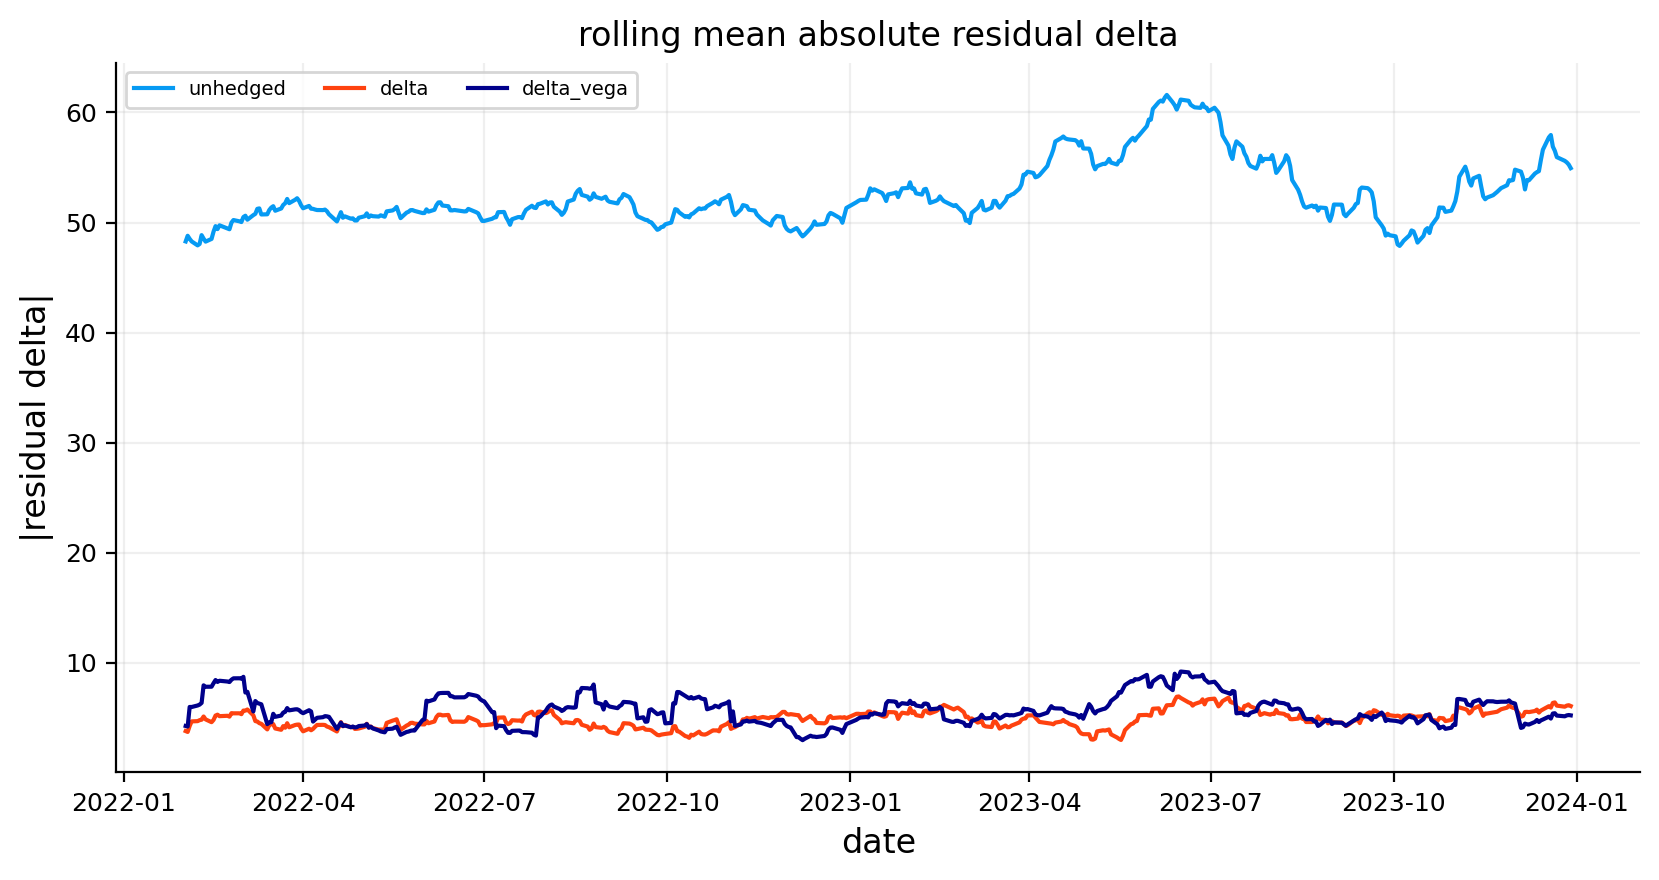

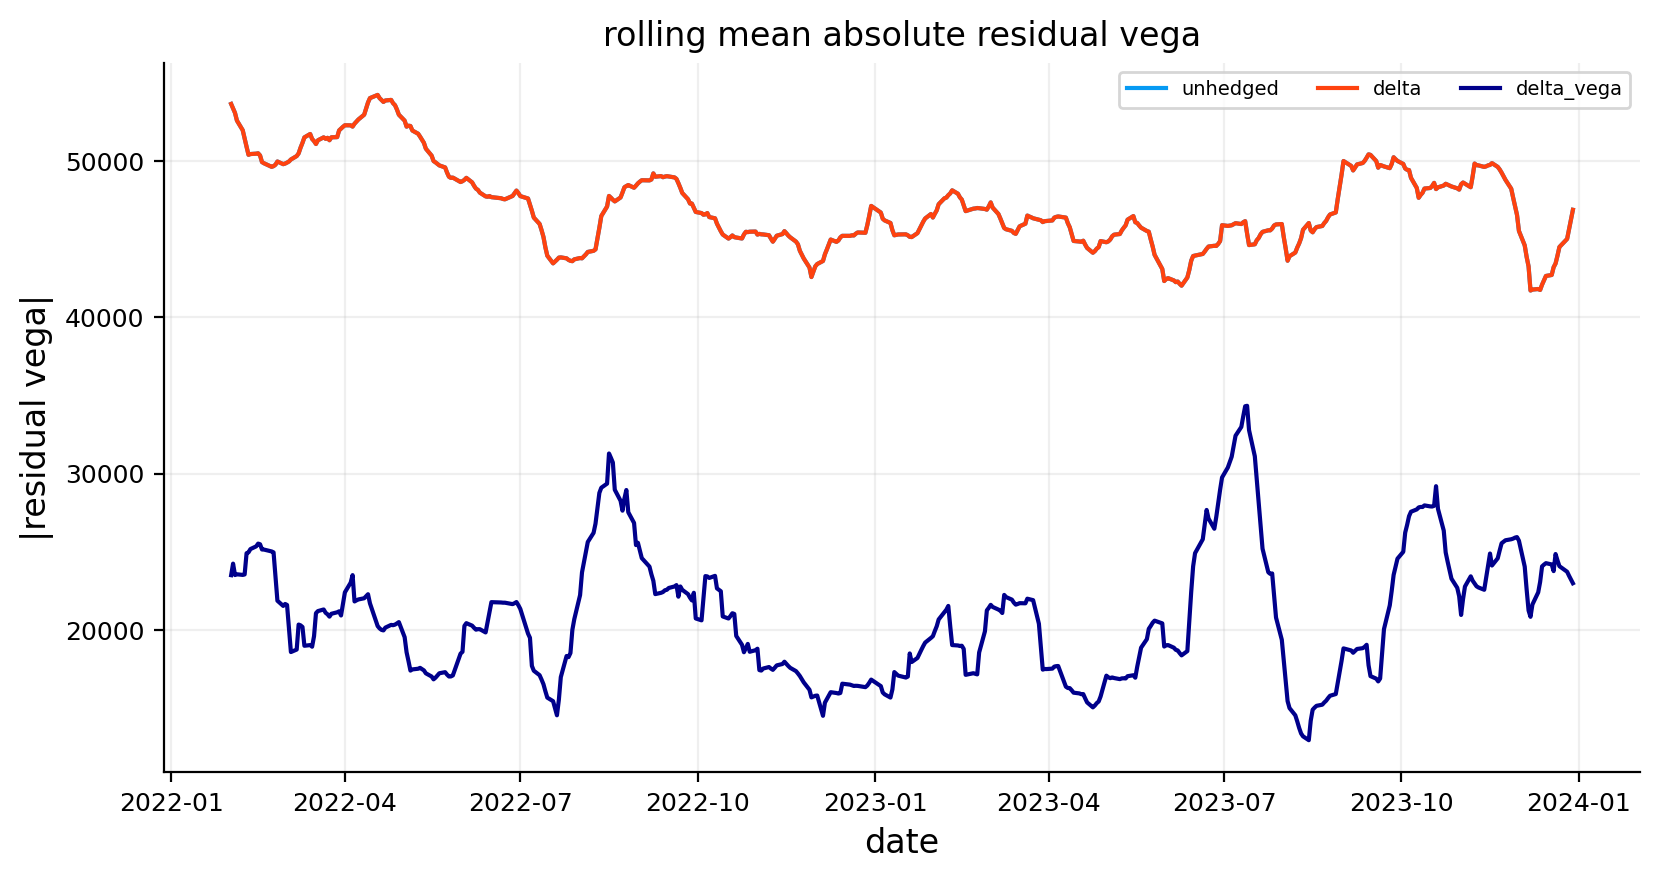

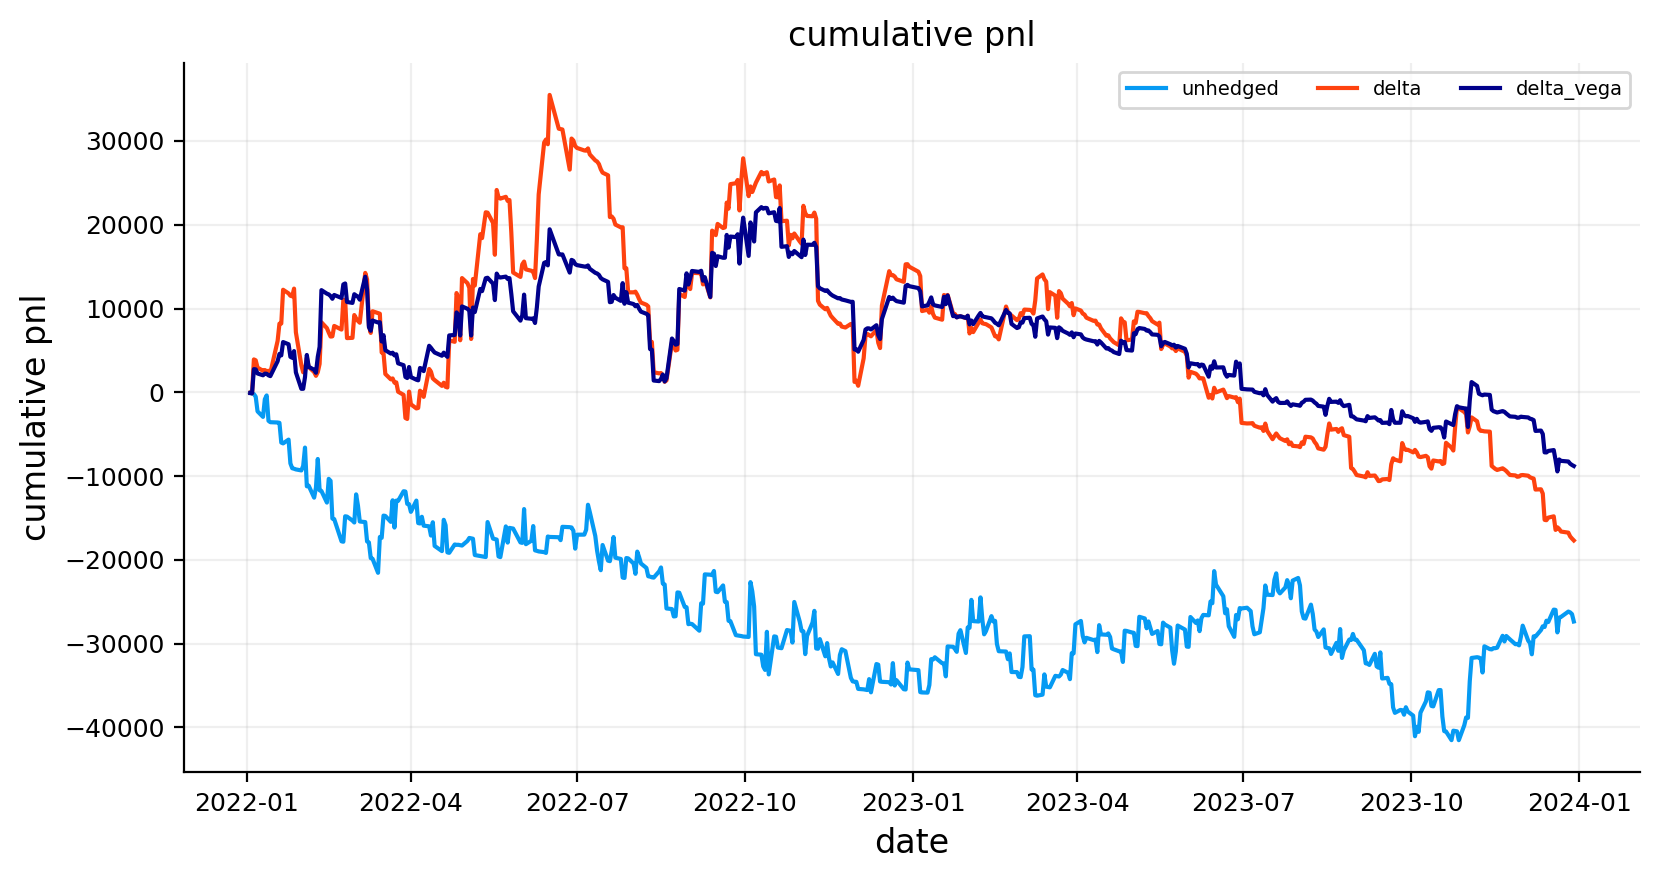

In [25]:
fig, ax = plt.subplots(figsize=(8.4, 4.5), sharex=True)
for k in ["unhedged", "delta", "delta_vega"]:
    run = strategy_runs[k]
    ax.plot(run["trade_date"], np.abs(run["residual_delta_equiv"]).rolling(21).mean(), label=k)
ax.legend(ncol=3)
ax.set_title("rolling mean absolute residual delta")
ax.set_ylabel("|residual delta|")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 4.5), sharex=True)
for k in ["unhedged", "delta", "delta_vega"]:
    run = strategy_runs[k]
    ax.plot(run["trade_date"], np.abs(run["residual_vega_equiv"]).rolling(21).mean(), label=k)
ax.legend(ncol=3)
ax.set_title("rolling mean absolute residual vega")
ax.set_ylabel("|residual vega|")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 4.5), sharex=True)
for k in ["unhedged", "delta", "delta_vega"]:
    run = strategy_runs[k]
    ax.plot(run["trade_date"], run["daily_pnl"].cumsum(), label=k)
ax.legend(ncol=3)
ax.set_title("cumulative pnl")
ax.set_ylabel("cumulative pnl")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

### 12.9 results

Seems like the strategies were able to control Delta and vega very efficiently and at the same time performed better than unhedged strategy in terms of equity. We didn't aim to make Delta and Vega neutral, but we tried to reduce them in an efficient way and at the same time tried to control over trading and turnover so we don't end up with high volatility and low returns. Delta vega is the best strategy. Even though both of our models didn't end up with positive return, we proved the point of reducing risk exposures for options and this was a simple starting point. In later projects we get more into how we can model and calibrate Volatility and greeks better (estimation has huge effect on hedging) and we show different models and get more into **options strategies**. 

In [26]:
def max_drawdown(series):
    arr = np.asarray(series, dtype=float)
    if len(arr) == 0:
        return np.nan
    running_max = np.maximum.accumulate(arr)
    drawdown = arr - running_max
    return float(np.nanmin(drawdown))


summary_rows = []
base_pnl = strategy_runs["unhedged"]["daily_pnl"].to_numpy(dtype=float)
base_var = float(np.nanvar(base_pnl, ddof=1)) if np.isfinite(base_pnl).sum() >= 2 else np.nan
base_es = float(np.nanmean(base_pnl[base_pnl <= np.nanquantile(base_pnl, 0.05)])) if np.isfinite(base_pnl).sum() >= 5 else np.nan

for name, run in strategy_runs.items():
    if run.empty:
        continue

    pnl = run["daily_pnl"].to_numpy(dtype=float)
    pnl = pnl[np.isfinite(pnl)]
    var_95 = float(np.nanquantile(pnl, 0.05)) if len(pnl) else np.nan
    es_mask = pnl <= var_95 if len(pnl) else np.array([], dtype=bool)
    es_95 = float(np.nanmean(pnl[es_mask])) if es_mask.sum() else np.nan
    pnl_var = float(np.nanvar(pnl, ddof=1)) if len(pnl) >= 2 else np.nan
    hit_rate = float(np.nanmean(pnl > 0.0)) if len(pnl) else np.nan
    pnl_std = float(np.nanstd(pnl, ddof=1)) if len(pnl) >= 2 else np.nan
    sharpe_like = float(np.nanmean(pnl) / pnl_std * np.sqrt(252.0)) if len(pnl) >= 2 and pnl_std > 0 else np.nan

    summary_rows.append(
        {"strategy": name,
         "mean_daily_pnl": float(np.nanmean(pnl)) if len(pnl) else np.nan,
         "std_daily_pnl": pnl_std,
         "var_95_daily_pnl": var_95,
         "es_95_daily_pnl": es_95,
         "total_pnl": float(run["equity"].iloc[-1]),
         "max_drawdown": max_drawdown(run["equity"]),
         "hit_rate": hit_rate,
         "sharpe_like_daily": sharpe_like,
         "total_cost": float(np.nansum(run["cost"])),
         "total_turnover": float(np.nansum(run["turnover"])),
         "roll_count": int(np.nansum(run["roll"])),
         "mean_abs_residual_delta": float(np.nanmean(np.abs(run["residual_delta_equiv"]))),
         "mean_abs_residual_gamma": float(np.nanmean(np.abs(run["residual_gamma_equiv"]))),
         "mean_abs_residual_vega": float(np.nanmean(np.abs(run["residual_vega_equiv"]))),
         "variance_reduction_vs_unhedged": float(1.0 - pnl_var / base_var) if np.isfinite(base_var)
           and base_var > 0 and np.isfinite(pnl_var) else np.nan,
         "es_improvement_vs_unhedged": float(es_95 - base_es) if np.isfinite(base_es)
           and np.isfinite(es_95) else np.nan})


df_hedge_summary = (pd.DataFrame(summary_rows)
    .sort_values(["variance_reduction_vs_unhedged", "es_improvement_vs_unhedged", "total_pnl"], ascending=[False, False, False])
    .reset_index(drop=True))

display(df_hedge_summary)


,strategy,mean_daily_pnl,std_daily_pnl,var_95_daily_pnl,es_95_daily_pnl,total_pnl,max_drawdown,hit_rate,sharpe_like_daily,total_cost,total_turnover,roll_count,mean_abs_residual_delta,mean_abs_residual_gamma,mean_abs_residual_vega,variance_reduction_vs_unhedged,es_improvement_vs_unhedged
0,delta_vega,-17.728978,"1,283.712248","-1,958.974906","-3,075.773716","-8,793.573079","-31,541.520747",0.370968,-0.219238,"12,732.201050","32,048,786.753228",122,5.605751,0.135214,"20,931.667194",0.407902,422.594132
1,unhedged,-55.142826,"1,668.287944","-2,723.717077","-3,498.367848","-27,350.841683","-41,475.741686",0.328629,-0.524709,"5,640.000000","2,434,990.000000",122,52.408765,0.189287,"47,399.610058",0.000000,0.000000
2,delta,-35.638272,"1,876.288660","-3,185.667234","-4,734.423616","-17,676.582666","-53,170.242225",0.354839,-0.301521,"10,602.520971","52,060,199.711375",122,4.889920,0.189287,"47,399.610058",-0.264903,"-1,236.055769"
